# Labo 1 — Comprendre et auditer le prétraitement EEG
### Décision lexicale assise et en marche — pipeline v1.0 du projet Brain Walk

**PSY2007D, édition 2026.** Dans le notebook `09_analysis1_lexicaldecision.ipynb`, vous analyserez des fichiers EEG déjà prétraités.
Ici, l'objectif est différent : **comprendre comment on passe du signal brut aux époques ERP**. Le notebook refait le pipeline v1.0 du projet Brain Walk (EEG assis et en marchant), avec un changement à l'étape 5, sur un participant de votre choix (P003 au départ), une étape à
la fois. À la fin, vous comparez votre résultat au fichier qui vous a été fourni : vous devez obtenir les mêmes époques. Trois sections
finales mesurent trois composantes de l'ERP et deux effets (section 13), ce que chaque étape a changé dans l'ERP (section 14), et
essaient une autre correction de la ligne de base (section 15).

> **Idée centrale.** Le prétraitement ne transforme pas automatiquement un EEG « sale » en EEG « propre ». Chaque étape vise une source
> probable de bruit, mais elle peut aussi enlever du signal du cerveau. À chaque étape, regardez donc **ce qui est retiré, ce qui est
> conservé et ce qui change dans le résultat final**.

**L'expérience.** Une décision lexicale : une suite de lettres apparaît au centre de l'écran (un mot fréquent, un mot rare ou un pseudo-mot
comme *candre*) et la personne indique le plus vite possible si c'est un mot du français, en touchant un côté d'une tablette. Elle fait
4 blocs assise et 4 blocs en marchant sur un tapis roulant (selon le participant, les blocs assis viennent avant ou après les blocs en marche).
Avant et après, elle se repose assise, les yeux ouverts. Elle marche aussi une fois sans tâche, juste avant ses blocs en marche. L'EEG est enregistré par un casque DSI-24 à électrodes sèches (19 électrodes, 300 échantillons par seconde, soit 300 Hz), qui contient
aussi un accéléromètre.

**Pourquoi tant d'étapes ?** L'activité du cerveau mesurée sur le cuir chevelu est faible : quelques dizaines de microvolts (µV) pour l'EEG de fond, quelques µV pour les réponses aux mots. Elle est mélangée à des signaux
bien plus grands : les clignements des yeux (souvent 100 à 300 µV), les mouvements des yeux, la tension des muscles, et, en marchant, les petits
déplacements des électrodes sèches à chaque pas. Chaque étape s'attaque à l'un de ces problèmes ou prépare la suivante (voir le tableau plus bas), en essayant de garder l'activité du cerveau.

## Comment utiliser ce notebook

### Objectifs d'apprentissage
À la fin du laboratoire, vous devriez pouvoir :
1. reconnaître les principales sources d'artefacts dans un EEG mobile ;
2. expliquer **pourquoi** chaque étape du pipeline est appliquée ;
3. distinguer une décision de prétraitement d'une vérité physiologique ;
4. interpréter les figures de contrôle avant/après ;
5. expliquer comment un choix de prétraitement peut modifier un ERP ;
6. juger la précision d'un ERP avec son erreur de mesure (SME) ;
7. mesurer une composante dans une région et une fenêtre, et vérifier qu'un effet ne vient pas des clignements.

### Comment travailler
- Exécutez les cellules dans l'ordre (Maj + Entrée). Le tout prend quelques minutes.
- **Bloc Type 1, essentiel** : lisez, exécutez, interprétez le résultat.
- **Bloc Type 2, expérimentation** : changez **un seul paramètre** marqué `# modifiable`, puis observez ce qui change.
- **Bloc Type 3, approfondissement** : facultatif, pour comprendre un choix de méthode plus fin.
- Après avoir changé un paramètre, relancez cette cellule **et toutes celles qui suivent** (menu *Exécuter* → *Exécuter la cellule
  sélectionnée et toutes celles en dessous*). L'étape 12 vous dira en quoi votre résultat diffère du fichier fourni. Si les résultats vous
  semblent incohérents, redémarrez le noyau et relancez tout (0.4 explique pourquoi).
- Les paramètres marqués `# ne pas modifier` décrivent le casque, les fichiers ou la version de référence du pipeline : il ne faut pas les changer.
- Il n'y a pas d'étape cachée : le code est écrit ligne par ligne, et presque chaque ligne a un commentaire qui dit ce qu'elle fait. Les
  fonctions de la cellule 0.4 choisissent seulement ce que montrent les figures et vérifient vos paramètres. Les boucles `for` répètent la même opération pour chaque enregistrement (`for nom in ...`) ou chaque morceau de signal (`for a, b in ...`).

### Quatre questions à poser à chaque étape
1. Quel problème cherche-t-on à réduire ?
2. Quelle information l'algorithme utilise-t-il pour le reconnaître ?
3. Comment vérifie-t-on qu'il a vraiment aidé ?
4. Qu'est-ce qu'il pourrait enlever par erreur ?

## Les étapes du notebook

| Étape | Ce qu'elle fait | Contre quoi | Où le vérifier |
|---|---|---|---|
| 1 | Charger les 11 enregistrements et repérer les moments inutilisables | les bords, les coupures du Bluetooth | sorties de 1.2 et 1.3, F1 |
| 2 | Contrôler chaque électrode | les électrodes mortes, saturées ou bruitées | tableau de 2.6, F2 |
| 3 | Filtre passe-haut à 0,1 Hz | les dérives lentes du signal | F3 |
| 4 | Référence moyenne, électrodes réparées | le choix arbitraire de Pz comme référence ; une électrode mauvaise dans un enregistrement | F4 |
| 5 | Régression sur l'accéléromètre | les artefacts des pas | tableau de 5.5, F5 |
| 6 | Repérer les clignements et les saccades | (prépare les étapes 7 à 9) | F6 |
| 7 | ICA par posture, à la manière d'OPTICAT | trouver les composantes des yeux | sortie de 7.2, F7 |
| 8 | Ondelettes (wICA) sur les composantes des yeux | les mouvements des yeux | F8 |
| 9 | Filtre des clignements | ce qui reste des clignements | F9 |
| 10 | Signal final : électrodes reconstruites, référence moyenne, passe-bas à 30 Hz | le bruit rapide (muscles) | F10 |
| 11 | Découper en époques autour de chaque mot | les essais trop bruités | tableau de 11.6, F11, bilans 11.8 et 11.9, F11d |
| 12 | Comparer avec le fichier fourni | — | sortie de 12.1 |
| 13 | Mesurer trois composantes (P2, N400, LPC) et deux effets (posture, fréquence des mots) | — | sortie de 13.2, F13a, F13b, tableaux de 13.3 et 13.4 |
| 14 | Refaire l'ERP après chaque étape | — | F14 |
| 15 | Corriger la ligne de base par régression | une différence déjà présente avant le mot | F15 |
| 16 | Les repos et la marche sans tâche : à quoi ils servent | — | tableau de la section 16 |

Chaque figure porte le numéro de son étape. Quand une étape change le signal, sa figure montre le même signal **avant** l'étape (en gris,
ou à gauche) et **après** (en couleur, ou à droite). Les étapes 1, 2, 6 et 7 ne changent pas le signal : elles prennent des décisions
(moments BAD, électrodes, clignements, composantes) dont l'effet se voit aux étapes suivantes.


### Où se situe ce pipeline parmi ceux de l'EEG en marche

Ce notebook reproduit **un** pipeline, celui du projet Brain Walk, pour que vous puissiez le vérifier étape par étape. Ce n'est pas la seule
façon de prétraiter un EEG enregistré en marchant. Une revue de 65 études d'EEG mobile pendant la marche a compté 18 étapes de prétraitement
différentes, combinées et ordonnées de bien des façons : presque toutes les études rejettent des artefacts, la plupart utilisent l'ICA,
environ la moitié retirent les mauvaises électrodes, et environ le quart utilisent l'ASR ou interpolent des électrodes. Sa principale
recommandation : rapporter chaque étape, ses paramètres et leur ordre (Vinod et al., 2026).

Deux études proches de celle-ci ont fait d'autres choix. Barnes, Davidson et Alais (2025) ont enregistré avec le même casque en marchant
(DSI-24, les mêmes 19 positions, Pz comme référence pendant l'enregistrement). Ils ont ensuite pris comme référence la moyenne des deux lobes
d'oreille (A1 et A2), filtré de 0,1 à 40 Hz, et retiré les mauvaises électrodes (critères d'écart et de corrélation de PyPREP) au lieu de les
reconstruire. Paillard et al. (2025) ont comparé des casques à électrodes sèches : ils ont reconstruit les mauvaises électrodes par
interpolation sphérique, puis pris la référence moyenne, et notent que l'interpolation elle-même peut différer entre des casques qui n'ont
pas le même nombre d'électrodes.

Ce notebook garde les choix de Brain Walk, pour que l'étape 12 puisse comparer votre résultat aux fichiers fournis. Une autre référence ou
une autre méthode de nettoyage est une **analyse de sensibilité** : on la fait et on la rapporte comme telle, sans jamais l'échanger en
silence contre la méthode.

### Ce qui est fixé ici, et ce qui relève d'une analyse de sensibilité

| Décision | Ici (les fichiers fournis) | Pourquoi | Variante à tester dans le projet |
|---|---|---|---|
| Référence | référence moyenne sans bouffées (étapes 4, 10 et 11.4) | reproduit les fichiers fournis | la moyenne des seules électrodes mesurées ; les deux lobes d'oreille (A1, A2) |
| Mauvaises électrodes | repérées (étape 2), reconstruites pour un montage complet, et listées (`reconstruites`, 11.7) | avec des électrodes sèches, rejeter chaque époque qui a une mauvaise électrode ferait perdre la plupart des essais en marche (F11a) | des règles de réparation plus strictes ; une autre interpolation |
| Mouvement | régression sur l'accéléromètre (étape 5) | un signal de référence propre à la marche | pas de régression ; l'ASR. Les juger sur l'ERP, pas sur l'allure plus propre du signal |
| Yeux | ICA par posture, wICA, filtre des clignements (étapes 7 à 9) | corrige les composantes oculaires sans les retirer entières | d'autres seuils pour les composantes oculaires (`SEUIL_RATIO`) |
| Ligne de base des ERP | moyenne de -200 à 0 ms soustraite (étape 11) | la correction locale habituelle, celle du projet | la régression (section 15) |
| Régions des composantes | fixées avant de voir les données (section 13, notebook 09) | une région choisie après avoir vu l'effet rend le test trop optimiste | d'autres électrodes dans F11b et F11c, rapportées comme une exploration |
| Repos et marche sans tâche | des conditions contrôles, pas une ligne de base des ERP | ils répondent à d'autres questions | section 16, notebook 10 |

L'ASR (*artifact subspace reconstruction*) est courante dans l'EEG en marche (Vinod et al., 2026), mais ce n'est pas un nettoyage plus
neutre. Elle reste une analyse de sensibilité du projet.

**Les signaux du code, d'une étape à l'autre.**

```text
brut               19 électrodes, référence Pz                                   (étape 1)
hp                 filtre passe-haut à 0,1 Hz                                    (3)
base               référence moyenne, électrodes réparées                        (4)   les électrodes laissées de côté valent encore 0
propre             moins ce que l'accéléromètre explique                         (5)
apres_wica         composantes oculaires corrigées                               (8)   les électrodes restantes seulement
nettoye            filtre des clignements                                        (9)   les électrodes restantes seulement
complet            électrodes laissées de côté reconstruites, nouvelle référence (10.1, 10.2)
final_etape10      filtre passe-bas à 30 Hz                                      (10.3)
final              électrodes trop souvent au-dessus de 100 µV reconstruites     (11.4)
epoques            époques découpées, puis réparées une à une                    (11.5, 11.6)
mes_epoques        les époques des ERP, avec la colonne reconstruites            (11.7)
```

Avoir 19 électrodes à la fin ne veut pas dire que 19 ont été mesurées : la colonne `reconstruites` garde la différence.

## 0. Mise en place (Bloc Type 1)

La cellule 0.1 télécharge les données du cours (855 Mo) depuis Google Drive et les décompresse dans `tasks/brainwalk/`, à côté du
notebook. Elle ne le fait qu'une fois : si les données sont déjà là, elle passe. Les quatre notebooks du labo (01, 09, 10 et 11) utilisent
ce même dossier. Il n'y a rien à télécharger à la main.

- **Sur votre ordinateur** : ouvrez le notebook depuis le dossier du dépôt cloné (`git clone`). Les données arrivent dans `tasks/brainwalk/`
  du dépôt, que Git ignore.
- **Dans Google Colab** : la cellule installe aussi MNE. Colab efface ses fichiers à la fin de la session : la cellule retélécharge alors
  les données (une ou deux minutes).

**Choisir un participant.** Le dossier `brainwalk/bids/` contient les enregistrements bruts de 9 participants. Le notebook marche avec chacun :
changez `PARTICIPANT` dans la cellule 0.3, puis exécutez le notebook du début à la fin. Pour une première fois, prenez un participant dont les
données sont complètes :

| Participant | Données |
|---|---|
| P002, P012 | complètes : les 11 enregistrements, 100 mots dans chacun des 8 blocs, l'accéléromètre partout (les seules pertes durent moins de 0,2 s) |
| P003, P009 | complètes, sauf quelques mots au début d'un bloc assis, avant le début de l'EEG (3 mots chez P003, bloc 2 ; 1 mot chez P009, bloc 4) |

<details><summary>Ce qui manque chez les autres participants</summary>

Le pipeline les traite quand même, et l'étape 12 compare votre résultat au fichier fourni.

| Participant | Ce qui manque |
|---|---|
| P004 | environ 47 s d'EEG au premier repos et 10 s dans le bloc assis 4 ; 2 mots au début du bloc assis 1 et 6 au début du bloc assis 4 |
| P006 | pas d'accéléromètre au bloc assis 1 ; 8 mots au début du bloc en marche 3 ; aucune époque en marche n'est utilisable (étape 11.3) |
| P007 | aucune réponse après le mot 26 du bloc en marche 3 |
| P008 | 20 coupures du Bluetooth ; sept électrodes laissées de côté |
| P010 | trois coupures de 15 s dans le bloc en marche 3 |
</details>


In [1]:
# ---- 0.1 Les données : téléchargées une seule fois, dans tasks/brainwalk à côté du notebook ---------------------------------------
import sys                                                   # pour savoir si le notebook tourne dans Google Colab
import zipfile                                               # pour décompresser les données
import urllib.request                                        # pour télécharger les données
from pathlib import Path                                     # pour écrire des chemins de fichiers
import hashlib                                               # pour reconnaître la version des données

EN_COLAB = 'google.colab' in sys.modules                     # True dans Google Colab, False sur votre ordinateur
if EN_COLAB:
    # Colab n'a pas MNE : on l'installe (environ une minute), dans les versions vérifiées à l'étape 12 (la cellule 0.2 compare les autres)
    !pip install -q mne==1.13.2 python-picard==0.8.2 PyWavelets==1.8.0
DOSSIER = Path('tasks/brainwalk')                            # ne pas modifier : les données, dans tasks/ à côté du notebook
ID_DRIVE = '19nnPiRuypz5fCPISybipdjxeop2EA_P8'               # ne pas modifier : le fichier labo1_donnees_2026.zip sur Google Drive
EMPREINTE = '123a0b4bc32ecf49'                               # ne pas modifier : l'empreinte de manifest.json dans cette version des données


def donnees_a_jour():
    """True si DOSSIER contient cette version des données (l'empreinte de son fichier manifest.json)."""
    manifeste = DOSSIER / 'manifest.json'
    return manifeste.exists() and hashlib.sha256(manifeste.read_bytes()).hexdigest()[:16] == EMPREINTE


def progression(blocs, taille_bloc, total):
    """Affiche l'avancement du téléchargement, tous les 10 %."""
    if total > 0 and blocs * taille_bloc * 10 // total > (blocs - 1) * taille_bloc * 10 // total:
        print(f'  {min(100, 100 * blocs * taille_bloc // total)} %')


if not donnees_a_jour():                                     # absentes, ou une ancienne version : on les télécharge (855 Mo)
    archive = DOSSIER.parent / 'labo1_donnees_2026.zip'
    archive.parent.mkdir(parents=True, exist_ok=True)
    print('Téléchargement des données depuis Google Drive (855 Mo, quelques minutes) :')
    urllib.request.urlretrieve(f'https://drive.usercontent.google.com/download?id={ID_DRIVE}&export=download&confirm=t', archive, progression)
    if not zipfile.is_zipfile(archive):                      # Google Drive a renvoyé une page web au lieu du fichier
        archive.unlink()
        raise RuntimeError('Google Drive n\'a pas envoyé les données (trop de téléchargements aujourd\'hui ?). Réessayez plus tard.')
    with zipfile.ZipFile(archive) as z:
        z.extractall(DOSSIER.parent)                         # crée tasks/brainwalk/
    archive.unlink()                                         # le zip ne sert plus
print('Données :', DOSSIER, '(prêtes)' if donnees_a_jour() else '(INTROUVABLES : relancez cette cellule)')

Données : tasks\brainwalk (prêtes)


In [2]:
# ---- 0.2 Les bibliothèques ---------------------------------------------------------------------------------------------------------
import hashlib                                               # pour refaire le même tirage au sort que le pipeline (étape 7)
import json                                                  # pour enregistrer les paramètres de votre passage (fin du notebook)
import numpy as np                                           # calcul sur des tableaux de nombres
import pandas as pd                                          # tableaux de données (comme un tableur)
import matplotlib.pyplot as plt                              # figures
import mne                                                   # lecture et traitement de l'EEG
import pywt                                                  # ondelettes (étape 8)
from picard import picard                                    # l'algorithme d'ICA (étape 7)
from scipy.signal import butter, sosfiltfilt, filtfilt, find_peaks, peak_widths, welch, sosfreqz   # filtres, pics, spectres
from scipy.interpolate import PchipInterpolator              # passer l'accéléromètre de 30 à 300 échantillons par seconde (étape 5)
from scipy.linalg import eigh                                # le filtre des clignements (étape 9)
import warnings                                              # pour masquer un avertissement technique de SciPy (étape 6)
import scipy                                                 # pour noter la version utilisée
import importlib.metadata as metadata                        # version des petits paquets installés

mne.set_log_level('ERROR')                                   # MNE n'affiche que les erreurs ('WARNING' : aussi ses avertissements)
warnings.filterwarnings('ignore', message='some peaks have a')   # « some peaks have a width of 0 » : sans effet sur le résultat
VERSIONS = {'MNE': mne.__version__, 'NumPy': np.__version__, 'SciPy': scipy.__version__, 'PyWavelets': pywt.__version__,
            'python-picard': metadata.version('python-picard')}
TESTEES = {'MNE': '1.13.2', 'NumPy': '2.5.3', 'SciPy': '1.18.1', 'PyWavelets': '1.8.0', 'python-picard': '0.8.2'}   # ne pas modifier : l'étape 12
print('Versions :', ' | '.join(f'{k} {v}' for k, v in VERSIONS.items()))
autres_versions = [f'{k} {VERSIONS[k]} (l\'étape 12 a été vérifiée avec {v})' for k, v in TESTEES.items() if VERSIONS[k] != v]
if autres_versions:
    print('Autres versions que celles de l\'étape 12 :', ', '.join(autres_versions), '\nUne petite différence à l\'étape 12 peut venir de là.')

Versions : MNE 1.13.2 | NumPy 2.5.3 | SciPy 1.18.1 | PyWavelets 1.8.0 | python-picard 0.8.2


In [3]:
# ---- 0.3 Le participant, puis ce qui ne change pas ----------------------------------------------------------------------------------
PARTICIPANT = 'P003'                                         # modifiable : P002, P003, P009 ou P012 (données complètes, voir plus haut)
FS = 300.0                                                   # ne pas modifier : échantillons par seconde du DSI-24 (Hz)
CANAUX = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8',
          'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']                # ne pas modifier : les 19 électrodes, toujours dans cet ordre
N_CANAUX = len(CANAUX)                                       # ne pas modifier : 19
PZ = CANAUX.index('Pz')                                      # ne pas modifier : Pz est la référence pendant l'enregistrement
GRAINE = 97                                                  # ne pas modifier : la graine du hasard du pipeline v1.0
MONTAGE = mne.channels.make_standard_montage('standard_1020')   # positions standard 10-20 des électrodes sur la tête
SEANCE = DOSSIER / 'bids' / f'sub-{PARTICIPANT}' / 'ses-001'    # le dossier de la séance de ce participant

### 0.4 Ce que montrent les figures (Bloc Type 2)

Par défaut, les figures montrent les électrodes, les enregistrements et les fenêtres de temps que décrivent les textes. La cellule 0.4 vous
permet d'en montrer d'autres, **sans changer aucun résultat** :
- `AFFICHAGE` choisit les électrodes de chaque figure : `'toutes'`, une électrode (`'Cz'`) ou une liste (`['C3', 'Cz', 'C4']`). Dans les
  figures qui tracent une ligne par électrode (F1, F2, F4, F5d, F8, F10a), une liste choisit les lignes. Dans celles qui tracent une courbe
  (F3, F5b, F9, F10b, F11, F12), la courbe est la moyenne des électrodes de la liste. Dans les figures des ERP (F11a à F11c), une époque ne
  compte que celles des électrodes de la liste qui y ont été mesurées (11.9).
- `FIGURES` choisit l'enregistrement assis et l'enregistrement en marche des figures, et la fenêtre de temps des figures du signal continu.
- `OPTIONNEL = True` exécute aussi les figures facultatives (Blocs Type 3 : F3c, F5e, F5f, F6c, F7b, F9b, F9c, F11g). Elles sont plus lentes.

Après un changement, relancez la cellule 0.4, puis la figure : aucune autre cellule ne dépend de ces réglages.

**Ce qui n'est pas un réglage d'affichage.** Les électrodes qu'utilise une étape (Fp1 et Fp2 pour les clignements, les paires gauche-droite
pour les saccades) et les régions des composantes (section 13) définissent la méthode. Les changer change l'analyse, pas une figure : elles
restent dans leurs cellules, marquées `# ne pas modifier` ou `# modifiable`.

**Relancer une cellule.** Jupyter garde les variables des cellules déjà exécutées. Une cellule qui modifie son entrée sur place donnerait
un autre résultat à la deuxième exécution. Les cellules des sections 2 et 11 repartent donc d'une copie de leur entrée : vous pouvez les
relancer après avoir changé un paramètre. La règle reste la même : après avoir changé un paramètre, relancez sa cellule et toutes celles
qui suivent. Si les résultats vous semblent incohérents, redémarrez le noyau (*Noyau* → *Redémarrer* ; dans Colab, *Exécution* →
*Redémarrer la session*) et relancez tout.

Les fonctions de la cellule 0.4 vérifient aussi vos choix (une électrode inconnue, une fenêtre hors de l'enregistrement, une bande de
fréquences impossible) et disent quoi changer.

In [4]:
# ---- 0.4 Ce que montrent les figures, et les fonctions des figures ---------------------------------------------------------------
AFFICHAGE = {                                                # modifiable (affichage seulement) : 'toutes', une électrode ou une liste d'électrodes
    'F1': 'toutes', 'F2': 'toutes', 'F3': 'Fz', 'F4': 'toutes', 'F5': 'toutes', 'F5c': 'auto', 'F8': ['Fp1', 'Fp2', 'Fz', 'Cz'],
    'F9': ['Fp1', 'Fp2'], 'F10': 'toutes', 'F11': 'Cz', 'F12': 'Cz', 'PAS': 'Cz'}   # F5c : 'auto' = l'électrode la plus corrigée
FIGURES = {                                                  # modifiable (affichage seulement) : les enregistrements et les fenêtres de temps des figures
    'enregistrement_assis': None,                            # None : le premier bloc assis ; ou un nom du tableau de 1.1
    'enregistrement_marche': None,                           # None : le premier bloc en marche
    'debut_s': {'F1': 20, 'F4': 20, 'F5': 30, 'F6': 60, 'F8': 60, 'F10': 20},   # où commence chaque figure (s)
    'duree_s': {'F1': 5, 'F4': 5, 'F5': 5, 'F6': 30, 'F8': 10, 'F10': 5}}       # combien de temps elle dure (s)
OPTIONNEL = False                                            # modifiable : True pour exécuter aussi les figures facultatives (Type 3, plus lentes)


def choisir_electrodes(selection, disponibles, figure):
    """Les électrodes demandées : 'toutes', un nom ou une liste de noms (en majuscules ou en minuscules), parmi celles disponibles."""
    disponibles = list(disponibles)
    if isinstance(selection, str) and selection.lower() == 'toutes':
        return disponibles
    demandees = [selection] if isinstance(selection, str) else list(selection)
    minuscules = {c.lower(): c for c in disponibles}            # le nom de chaque électrode, en minuscules
    manquants = [c for c in demandees if c.lower() not in minuscules]
    if manquants:
        print(f'{figure} : {manquants} pas disponible(s) ici, laissée(s) de côté (disponibles : {", ".join(disponibles)})')
    if len(manquants) == len(demandees):
        raise ValueError(f'{figure} : aucune de {demandees} n\'est disponible. Choisissez parmi : {", ".join(disponibles)}')
    return [minuscules[c.lower()] for c in demandees if c.lower() in minuscules]


def nom_choix(electrodes):
    """Le nom d'un choix d'électrodes, pour un titre : l'électrode, ou la moyenne des électrodes."""
    if len(electrodes) == 1:
        return electrodes[0]
    return 'moyenne de ' + (', '.join(electrodes) if len(electrodes) <= 4 else f'{len(electrodes)} électrodes')


def enregistrement_exemple(genre, noms):
    """L'enregistrement des figures pour 'seated' (assis) ou 'walking' (en marche) : celui de FIGURES, ou le premier bloc de ce genre."""
    cle = {'seated': 'enregistrement_assis', 'walking': 'enregistrement_marche'}[genre]   # sa clé dans FIGURES
    choisi = FIGURES[cle]
    if choisi is None:
        return [nom for nom in noms if enregistrements.loc[nom, 'genre'] == genre][0]
    if choisi not in list(noms):
        raise ValueError(f"FIGURES['{cle}'] = {choisi!r} n'est pas disponible. Choisissez parmi : {', '.join(noms)}")
    return choisi


def fenetre_temps(nom, n, figure):
    """Les échantillons de la fenêtre de temps d'une figure (FIGURES), dans un enregistrement de n échantillons."""
    debut, duree = FIGURES['debut_s'][figure], FIGURES['duree_s'][figure]
    a, b = int(round(debut * FS)), min(int(round((debut + duree) * FS)), n)
    if debut < 0 or duree <= 0 or a >= b:
        raise ValueError(f"{figure} : la fenêtre de {debut} à {debut + duree} s n'est pas dans {nom} ({n / FS:.0f} s) : changez FIGURES")
    return np.arange(a, b)


def region_mesuree(ep, region):
    """Le signal d'un groupe d'électrodes dans chaque époque (µV) : la moyenne des seules électrodes mesurées dans cette époque (la colonne
    reconstruites des métadonnées, 11.7). Rend aussi leur nombre. Une époque où aucune n'est mesurée prend la moyenne de toutes (la règle de Brain Walk)."""
    x = ep.get_data(picks=region, units='uV')                                   # époques x électrodes x instants
    mesuree = np.array([[c not in str(r).split() for c in region] for r in ep.metadata['reconstruites']])   # époques x électrodes
    n = mesuree.sum(axis=1)                                                     # le nombre d'électrodes mesurées dans chaque époque
    signal = (x * mesuree[:, :, None]).sum(axis=1) / np.maximum(n, 1)[:, None]  # leur moyenne
    return np.where(n[:, None] > 0, signal, x.mean(axis=1)), n                  # aucune mesurée : toutes (la règle du projet Brain Walk)


def verifier_bande(nom, bande, fs):
    """Arrête avec un message clair si une bande de fréquences est impossible : 0 < bas < haut < la moitié de la fréquence d'échantillonnage."""
    if not 0 < bande[0] < bande[1] < fs / 2:
        raise ValueError(f'{nom} = {bande} : il faut 0 < bas < haut < {fs / 2:g} Hz (la moitié de {fs:g} échantillons par seconde)')


def verifier_fenetre(nom, fenetre, dedans=None):
    """Arrête avec un message clair si une fenêtre de temps est impossible : début < fin, et dans une autre fenêtre si on en donne une."""
    if not fenetre[0] < fenetre[1] or (dedans is not None and not dedans[0] <= fenetre[0] < fenetre[1] <= dedans[1]):
        raise ValueError(f'{nom} = {fenetre} : il faut début < fin' + (f', dans {dedans}' if dedans is not None else ''))


print('Réglages d\'affichage prêts : AFFICHAGE pour les électrodes, FIGURES pour les enregistrements et les fenêtres de temps.')

Réglages d'affichage prêts : AFFICHAGE pour les électrodes, FIGURES pour les enregistrements et les fenêtres de temps.


In [5]:
# ---- 0.5 Contrôle rapide : les données du participant sont-elles là ? (aucun prétraitement ici) -------------------------------
if not (DOSSIER / 'bids').exists():
    raise FileNotFoundError(f'Dossier introuvable : {(DOSSIER / "bids").resolve()}\nRelancez la cellule 0.1.')
disponibles = sorted(p.name[4:] for p in (DOSSIER / 'bids').glob('sub-*'))   # les participants du zip
if not SEANCE.exists():                                                      # un participant dont les données ne sont pas dans le zip
    raise FileNotFoundError(f'Pas de données pour {PARTICIPANT}. Participants disponibles : {", ".join(disponibles)}')
a_verifier = [SEANCE / 'eeg', SEANCE / 'motion', SEANCE / 'beh', SEANCE / f'sub-{PARTICIPANT}_ses-001_scans.tsv']   # ce dont le pipeline a besoin
manquants = [str(p) for p in a_verifier if not p.exists()]
if manquants:
    raise FileNotFoundError('Fichiers ou dossiers manquants :\n- ' + '\n- '.join(manquants))
print(f'{PARTICIPANT} : {len(list((SEANCE / "eeg").glob("*_eeg.vhdr")))} enregistrements EEG trouvés. Le notebook peut commencer.')

P003 : 11 enregistrements EEG trouvés. Le notebook peut commencer.


## 1. Charger les enregistrements (Bloc Type 1)

**Pourquoi cette étape ?** Le participant a fait 11 enregistrements : deux repos assis, 4 blocs assis, une marche seule et 4 blocs en marche (le tableau de 1.1 donne l'ordre de sa séance : il change d'un participant à l'autre).
Le pipeline les traite **ensemble** : l'étape 2 compare les enregistrements d'une même posture, et l'ICA de l'étape 7 apprend sur tous ceux
d'une posture. Les fichiers sont au format BIDS : un fichier EEG BrainVision (`.vhdr`, `.vmrk`, `.eeg`) et un tableau d'événements
(`_events.tsv`) par enregistrement, et un tableau `scans.tsv` qui donne l'heure de début de chaque fichier.

**Ce que fait v1.0.** Il lit chaque fichier en microvolts et garde les 19 électrodes (Pz vaut 0 partout : chaque électrode est enregistrée
*moins Pz*). Il lit les événements : l'apparition de chaque mot (`stimulus`), chaque réponse (`response`) et chaque coupure du lien Bluetooth
(`data_gap`). Puis il marque comme inutilisables (**BAD**) les 2 premières et les 2 dernières secondes, 2 s de part et d'autre de chaque
coupure, et tout morceau de moins de 6 s entre deux coupures.

In [6]:
# ---- 1.1 La liste des enregistrements, dans l'ordre de la séance --------------------------------------------------------------------
scans = pd.read_csv(SEANCE / f'sub-{PARTICIPANT}_ses-001_scans.tsv', sep='\t')   # l'heure de début de chaque fichier
heure = dict(zip(scans['filename'], pd.to_datetime(scans['acq_time'])))      # nom du fichier -> heure de début
lignes = []                                                                  # une ligne par enregistrement
for vhdr in sorted((SEANCE / 'eeg').glob('*_eeg.vhdr')):                     # chaque fichier EEG
    tache = vhdr.name.split('_task-')[1].split('_')[0]                       # LexicalDecision, RestingState ou WalkingOnly
    acq = vhdr.name.split('_acq-')[1].split('_')[0]                          # seatedBlock01, walkingBlock02, seatedPre, ...
    racine = vhdr.name[:-len('_eeg.vhdr')]                                   # le nom du fichier sans la fin '_eeg.vhdr'
    mouvement = SEANCE / 'motion' / f'sub-{PARTICIPANT}_ses-001_task-{tache}_tracksys-DSI24_acq-{acq}_run-01_motion.tsv'
    if tache == 'LexicalDecision':
        genre = 'seated' if acq.startswith('seated') else 'walking'          # un bloc de la tâche, assis ou en marche
    elif tache == 'RestingState':
        genre = 'rest'                                                       # repos assis, yeux ouverts
    else:
        genre = 'walkonly'                                                   # marche seule, sans tâche
    debut = heure[f'eeg/{vhdr.name}']
    decalage = (heure[f'motion/{mouvement.name}'] - debut).total_seconds() if f'motion/{mouvement.name}' in heure else np.nan
    lignes.append(dict(nom=f'{tache}_{acq}', tache=tache, genre=genre, posture='walking' if genre in ('walking', 'walkonly') else 'seated',
                       debut=debut, vhdr=vhdr, evenements=SEANCE / 'eeg' / f'{racine}_events.tsv', mouvement=mouvement,
                       decalage_mouvement_s=decalage))   # décalage : l'accéléromètre démarre un peu après l'EEG
enregistrements = pd.DataFrame(lignes).sort_values('debut', kind='stable').set_index('nom')   # dans l'ordre de la séance
enregistrements[['genre', 'posture', 'debut', 'decalage_mouvement_s']]

,genre,posture,debut,decalage_mouvement_s
nom,,,,
RestingState_seatedPre,rest,seated,2000-01-01 17:52:46.869004,0.030000
LexicalDecision_seatedBlock01,seated,seated,2000-01-01 18:01:29.092322,0.030000
LexicalDecision_seatedBlock02,seated,seated,2000-01-01 18:06:32.164778,0.030000
LexicalDecision_seatedBlock03,seated,seated,2000-01-01 18:11:36.308921,0.030000
LexicalDecision_seatedBlock04,seated,seated,2000-01-01 18:16:23.907673,0.030000
WalkingOnly_walking,walkonly,walking,2000-01-01 18:23:20.935451,0.030000
LexicalDecision_walkingBlock01,walking,walking,2000-01-01 18:33:01.558770,0.031667
LexicalDecision_walkingBlock02,walking,walking,2000-01-01 18:38:37.529703,0.030000
LexicalDecision_walkingBlock03,walking,walking,2000-01-01 18:45:01.051846,0.030000


In [7]:
# ---- 1.2 Les signaux et les événements -----------------------------------------------------------------------------------------------
brut, evenements, coupures = {}, {}, {}                                      # un élément par enregistrement
for nom in enregistrements.index:
    raw = mne.io.read_raw_brainvision(enregistrements.loc[nom, 'vhdr'], preload=True)   # lit le fichier (en volts)
    donnees = raw.get_data() * 1e6                                           # volts -> microvolts
    brut[nom] = np.stack([donnees[raw.ch_names.index(c)] for c in CANAUX])   # les 19 électrodes, dans l'ordre de CANAUX
    if not np.allclose(brut[nom][PZ], 0):
        raise ValueError(f'{nom} : Pz devrait valoir 0 partout (c\'est la référence)')
    ev = pd.read_csv(enregistrements.loc[nom, 'evenements'], sep='\t', na_values='n/a')   # mots, réponses, coupures, pas...
    ev['sample'] = ev['sample'].astype(int)                                  # numéro de l'échantillon de chaque événement
    evenements[nom] = ev
    coupures[nom] = np.sort(ev.loc[ev['trial_type'] == 'data_gap', 'sample'].to_numpy(int))   # où le Bluetooth a coupé
    print(f'{nom:32s} {brut[nom].shape[1] / FS / 60:4.1f} min, {(ev["trial_type"] == "stimulus").sum():3d} mots, '
          f'{len(coupures[nom])} coupure(s)')

RestingState_seatedPre            5.1 min,   0 mots, 0 coupure(s)
LexicalDecision_seatedBlock01     4.3 min, 100 mots, 0 coupure(s)
LexicalDecision_seatedBlock02     4.4 min,  97 mots, 0 coupure(s)
LexicalDecision_seatedBlock03     4.2 min, 100 mots, 0 coupure(s)


LexicalDecision_seatedBlock04     4.2 min, 100 mots, 0 coupure(s)
WalkingOnly_walking               5.1 min,   0 mots, 0 coupure(s)
LexicalDecision_walkingBlock01    4.3 min, 100 mots, 0 coupure(s)
LexicalDecision_walkingBlock02    4.3 min, 100 mots, 0 coupure(s)


LexicalDecision_walkingBlock03    4.2 min, 100 mots, 0 coupure(s)
LexicalDecision_walkingBlock04    4.3 min, 100 mots, 0 coupure(s)
RestingState_seatedPost           5.0 min,   0 mots, 0 coupure(s)


In [8]:
# ---- 1.3 Les moments inutilisables (BAD) ---------------------------------------------------------------------------------------------
BORD_S = 2.0                 # modifiable (v1.0 : 2) : secondes BAD au début et à la fin (les filtres y sont imprécis)
MARGE_COUPURE_S = 2.0        # modifiable (v1.0 : 2) : secondes BAD de part et d'autre de chaque coupure
SEGMENT_MIN_S = 6.0          # modifiable (v1.0 : 6) : un morceau plus court que ça entre deux coupures est BAD
segments, bad = {}, {}
for nom in enregistrements.index:
    n = brut[nom].shape[1]                                                   # nombre d'échantillons
    bornes = [0] + [int(g) for g in coupures[nom] if 0 < g < n] + [n]        # l'enregistrement coupé à chaque coupure
    segments[nom] = [(a, b) for a, b in zip(bornes[:-1], bornes[1:]) if b > a]   # les morceaux continus [début, fin[
    masque = np.zeros(n, bool)                                               # True = échantillon à ne pas utiliser
    bord, marge = int(round(BORD_S * FS)), int(round(MARGE_COUPURE_S * FS))
    masque[:bord] = True                                                     # le début
    masque[max(n - bord, 0):] = True                                         # la fin
    for g in coupures[nom]:
        masque[max(0, g - marge):g + marge] = True                           # autour de chaque coupure
    for a, b in segments[nom]:
        if b - a < SEGMENT_MIN_S * FS:
            masque[a:b] = True                                               # les morceaux trop courts
    bad[nom] = masque
    print(f'{nom:32s} {len(segments[nom])} morceau(x), {100 * masque.mean():4.1f} % BAD')
bad_etape1 = {nom: masque.copy() for nom, masque in bad.items()}             # une copie : la section 2 repart d'elle (ses cellules peuvent être relancées)

RestingState_seatedPre           1 morceau(x),  1.3 % BAD
LexicalDecision_seatedBlock01    1 morceau(x),  1.6 % BAD
LexicalDecision_seatedBlock02    1 morceau(x),  1.5 % BAD
LexicalDecision_seatedBlock03    1 morceau(x),  1.6 % BAD
LexicalDecision_seatedBlock04    1 morceau(x),  1.6 % BAD
WalkingOnly_walking              1 morceau(x),  1.3 % BAD
LexicalDecision_walkingBlock01   1 morceau(x),  1.5 % BAD
LexicalDecision_walkingBlock02   1 morceau(x),  1.6 % BAD
LexicalDecision_walkingBlock03   1 morceau(x),  1.6 % BAD
LexicalDecision_walkingBlock04   1 morceau(x),  1.6 % BAD
RestingState_seatedPost          1 morceau(x),  1.3 % BAD


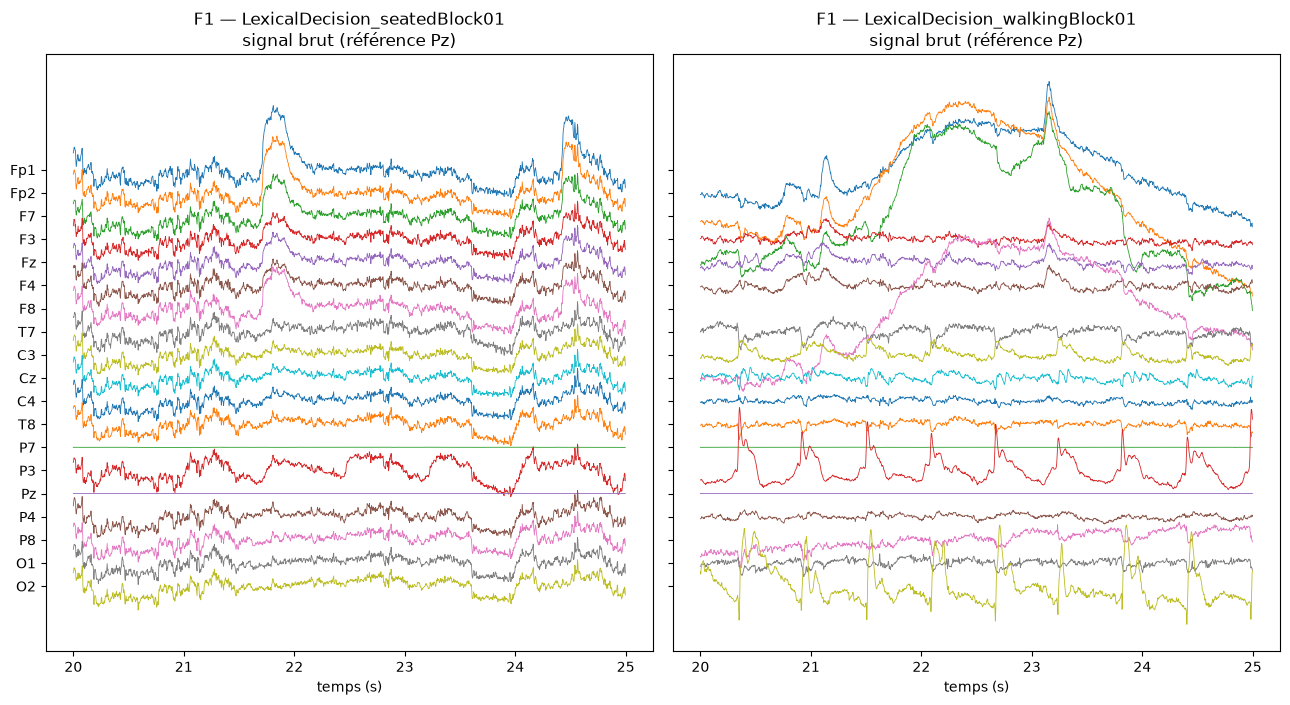

In [9]:
# ---- F1 : le signal brut, assis et en marche -------------------------------------------------------------------------------------
noms_lex = [nom for nom in enregistrements.index if enregistrements.loc[nom, 'tache'] == 'LexicalDecision']
exemple_assis = enregistrement_exemple('seated', noms_lex)                   # le premier bloc assis (FIGURES, 0.4)
exemple_marche = enregistrement_exemple('walking', noms_lex)                 # le premier bloc en marche
montrees = choisir_electrodes(AFFICHAGE['F1'], CANAUX, 'F1')                 # les électrodes de la figure (AFFICHAGE, 0.4)
fig, axes = plt.subplots(1, 2, figsize=(13, 0.35 * len(montrees) + 0.5), sharey=True)
for ax, nom in zip(axes, [exemple_assis, exemple_marche]):
    t = fenetre_temps(nom, brut[nom].shape[1], 'F1')                         # de 20 à 25 s
    for k, c in enumerate(montrees):
        i = CANAUX.index(c)
        ax.plot(t / FS, brut[nom][i, t] - brut[nom][i, t].mean() - 150 * k, lw=0.6)   # chaque électrode décalée de 150 µV
    ax.set_title(f'F1 — {nom}\nsignal brut (référence Pz)')
    ax.set_xlabel('temps (s)')
axes[0].set_yticks(-150 * np.arange(len(montrees)))
axes[0].set_yticklabels(montrees)
plt.tight_layout()
plt.show()

**Que regarder ? (F1)** Chaque ligne est une électrode (`AFFICHAGE`, 0.4) ; elles sont décalées de 150 µV pour ne pas se chevaucher. Les ondes lentes et
amples sur Fp1 et Fp2 (au-dessus des yeux) sont des clignements. Pz est plate : c'était la référence de l'enregistrement. P7 aussi :
chez tous les participants, cette électrode est morte (étape 2). En marche, le
signal est plus agité : chaque pas fait bouger le casque. Une électrode plate, ou au contraire très bruitée, sera repérée à l'étape 2.

**Questions de vérification.** (1) Combien de mots le participant a-t-il vus dans chaque bloc ? (2) Pourquoi marquer les bords comme BAD ?

## 2. Contrôler chaque électrode (Blocs Type 1 et 2)

**Pourquoi cette étape ?** Une électrode sèche peut perdre le contact avec la peau. Elle devient alors *morte* (plate), *saturée* (collée à la
limite de l'amplificateur), *bruitée* (elle capte les muscles et le courant du secteur à 45-100 Hz) ou *instable* (elle oscille beaucoup plus
que les autres à 1-40 Hz). Une mauvaise électrode ne doit pas entrer dans la référence moyenne (étape 4) ni dans l'ICA (étape 7) : elle sera
reconstruite à partir de ses voisines.

**Ce que fait v1.0**, pour chaque enregistrement, sur le signal brut :
1. **morte** : écart-type robuste sous 3 µV (Pz n'est pas jugée ici, elle vaut 0) ;
2. **saturée** : au moins 2 % des échantillons à ±9500 µV. Une saturation partagée par plus de la moitié des électrodes vient de la référence :
   elle n'est reprochée à aucune électrode, et ces moments (±0,5 s) deviennent BAD ;
3. **bruitée** : dans des fenêtres de 5 s, son bruit à 45-100 Hz est anormal (score z robuste > 3,5) dans au moins 25 % des fenêtres ;
4. **instable** : son amplitude à 1-40 Hz dépasse 5 fois celle de l'électrode médiane dans au moins 25 % des fenêtres ;
5. **Pz** est reconstruite par la référence moyenne, puis jugée par les règles 3 et 4 ;
6. un enregistrement est **écarté** s'il lui reste moins de 11 bonnes électrodes ou s'il est BAD à plus de 25 % ;
7. une électrode mauvaise dans **au moins la moitié** des enregistrements d'une posture est **laissée de côté partout** et sera reconstruite à
   l'étape 10. Une électrode mauvaise plus rarement est réparée dans ses seuls enregistrements (étape 4).

*Écart-type robuste* : 1,4826 × la médiane des écarts à la médiane. Contrairement à l'écart-type habituel, quelques grands pics (un
clignement) ne le changent presque pas.

In [10]:
# ---- 2.1 Électrodes mortes et saturées -----------------------------------------------------------------------------------------------
SEUIL_MORTE_UV = 3.0         # modifiable (v1.0 : 3) : écart-type robuste sous lequel une électrode est morte (µV)
RAIL_UV = 9500.0             # ne pas modifier : l'amplificateur sature à 9829,7 µV
PART_RAIL = 0.02             # modifiable (v1.0 : 0.02) : part des échantillons saturés qui rend une électrode mauvaise
raisons, rail_commun, rail_propre = {}, {}, {}
for nom in enregistrements.index:
    x = brut[nom]                                                            # 19 électrodes x échantillons (µV, référence Pz)
    v = x[:, ~bad_etape1[nom]] if (~bad_etape1[nom]).sum() > 100 else x      # seulement les échantillons utilisables (BAD de 1.3)
    med = np.median(v, axis=1, keepdims=True)
    sd_robuste = 1.4826 * np.median(np.abs(v - med), axis=1)                 # écart-type robuste de chaque électrode
    morte = sd_robuste < SEUIL_MORTE_UV
    morte[PZ] = False                                                        # Pz vaut 0 par construction : pas jugée ici
    raisons[nom] = {CANAUX[i]: 'morte (plate)' for i in np.flatnonzero(morte)}   # électrode -> pourquoi elle est mauvaise
    rail = np.abs(x) >= RAIL_UV                                              # True là où une électrode est saturée
    vivantes_ici = ~morte & (np.arange(N_CANAUX) != PZ)
    rail_commun[nom] = rail[vivantes_ici].mean(axis=0) > 0.5                 # saturé presque partout : un problème de référence
    rail_propre[nom] = rail & ~rail_commun[nom][None, :]                     # les saturations propres à une électrode
    part = rail_propre[nom].mean(axis=1)
    for i in np.flatnonzero(part >= PART_RAIL):
        raisons[nom].setdefault(CANAUX[i], f'saturée {100 * part[i]:.1f} % du temps')
raisons_etape21 = {nom: dict(r) for nom, r in raisons.items()}              # une copie : 2.2 et 2.3 repartent d'elle
for nom in enregistrements.index:
    print(f'{nom:32s}', raisons[nom] or 'aucune électrode morte ou saturée')

RestingState_seatedPre           {'P7': 'morte (plate)'}
LexicalDecision_seatedBlock01    {'P7': 'morte (plate)'}
LexicalDecision_seatedBlock02    {'P7': 'morte (plate)'}
LexicalDecision_seatedBlock03    {'P7': 'morte (plate)'}
LexicalDecision_seatedBlock04    {'P7': 'morte (plate)'}
WalkingOnly_walking              {'P7': 'morte (plate)'}
LexicalDecision_walkingBlock01   {'P7': 'morte (plate)'}
LexicalDecision_walkingBlock02   {'P7': 'morte (plate)'}
LexicalDecision_walkingBlock03   {'P7': 'morte (plate)'}
LexicalDecision_walkingBlock04   {'P7': 'morte (plate)'}
RestingState_seatedPost          {'P7': 'morte (plate)'}


In [11]:
# ---- 2.2 Le bruit et l'amplitude de chaque électrode, fenêtre par fenêtre --------------------------------------------------------
BANDE_BRUIT = (45.0, 100.0)  # modifiable (v1.0 : 45-100 Hz) : là où une électrode qui touche mal capte les muscles et le secteur
BANDE_AMPLITUDE = (1.0, 40.0)   # modifiable (v1.0 : 1-40 Hz)
FENETRE_S = 5.0              # modifiable (v1.0 : 5) : durée des fenêtres (s)
verifier_bande('BANDE_BRUIT', BANDE_BRUIT, FS)                               # arrête si une bande est impossible (0.4)
verifier_bande('BANDE_AMPLITUDE', BANDE_AMPLITUDE, FS)
fenetres, vivantes = {}, {}
for nom in enregistrements.index:
    x = brut[nom]
    vivantes[nom] = np.array([c not in raisons_etape21[nom] for c in CANAUX]) & (np.arange(N_CANAUX) != PZ)   # encore en jeu, sauf Pz
    fen_qc = int(round(FENETRE_S * FS))                                      # une fenêtre, en échantillons
    fenetres[nom] = {}
    for mesure, bande in (('bruit', BANDE_BRUIT), ('amplitude', BANDE_AMPLITUDE)):
        sos = butter(4, list(bande), btype='band', fs=FS, output='sos')      # filtre passe-bande d'ordre 4
        xf = np.zeros_like(x)
        for a, b in segments[nom]:                                           # morceau par morceau
            if b - a >= int(2 * FS):
                xf[:, a:b] = sosfiltfilt(sos, x[:, a:b], axis=1, padtype='odd', padlen=None)   # aller-retour : sans décalage
        xf = xf - np.median(xf[vivantes[nom]], axis=0, keepdims=True)        # on retire ce que toutes les électrodes ont en commun
        valeurs = []
        for a, b in segments[nom]:
            for s in range(a, b - fen_qc + 1, fen_qc):                       # fenêtres de 5 s qui se suivent
                if bad_etape1[nom][s:s + fen_qc].mean() > 0.5:
                    continue                                                 # fenêtre surtout BAD : ignorée
                w = xf[:, s:s + fen_qc]
                if mesure == 'amplitude':                                    # écart-type robuste dans la fenêtre
                    valeurs.append(1.4826 * np.median(np.abs(w - np.median(w, axis=1, keepdims=True)), axis=1))
                else:                                                        # moyenne quadratique (RMS) dans la fenêtre
                    valeurs.append(np.sqrt((w ** 2).mean(axis=1)))
        fenetres[nom][mesure] = np.array(valeurs).T                          # électrodes x fenêtres

In [12]:
# ---- 2.3 Les électrodes bruitées ou instables ---------------------------------------------------------------------------------------
SEUIL_Z = 3.5                # modifiable (v1.0 : 3.5) : score z robuste au-delà duquel une fenêtre est « bruitée »
PLANCHER_Z = 0.05            # ne pas modifier (v1.0) : plus petit écart utilisé pour calculer z (en log10)
RATIO_AMPLITUDE = 5.0        # modifiable (v1.0 : 5) : amplitude, en multiple de l'électrode médiane, qui rend une fenêtre « instable »
PART_FENETRES = 0.25         # modifiable (v1.0 : 0.25) : part des fenêtres qui rend une électrode mauvaise
raisons = {nom: dict(r) for nom, r in raisons_etape21.items()}              # repartir de 2.1 (pour pouvoir relancer cette cellule)
for nom in enregistrements.index:
    if fenetres[nom]['bruit'].size == 0:
        continue                                                             # aucune fenêtre utilisable : rien à juger
    v = vivantes[nom]
    lg = np.log10(fenetres[nom]['bruit'] + 1e-3)                             # le bruit, en échelle logarithmique
    med = np.median(lg[v], axis=0)                                           # l'électrode médiane, fenêtre par fenêtre
    etendue = np.maximum(1.4826 * np.median(np.abs(lg[v] - med), axis=0), PLANCHER_Z)
    z = (lg - med) / etendue                                                 # score z robuste de chaque électrode
    ratio = fenetres[nom]['amplitude'] / np.maximum(np.median(fenetres[nom]['amplitude'][v], axis=0), 1e-6)
    part_bruit = (z > SEUIL_Z).mean(axis=1)                                  # part des fenêtres où l'électrode est bruitée
    part_instable = (ratio > RATIO_AMPLITUDE).mean(axis=1)                   # part des fenêtres où elle est instable
    for i in np.flatnonzero(v & (part_bruit >= PART_FENETRES)):
        raisons[nom].setdefault(CANAUX[i], f'bruitée à 45-100 Hz dans {100 * part_bruit[i]:.0f} % des fenêtres')
    for i in np.flatnonzero(v & (part_instable >= PART_FENETRES)):
        raisons[nom].setdefault(CANAUX[i], f'instable dans {100 * part_instable[i]:.0f} % des fenêtres')

In [13]:
# ---- 2.4 Les moments où une électrode gardée sature deviennent BAD -------------------------------------------------------------
RAIL_MARGE_S = 0.5           # modifiable (v1.0 : 0.5) : secondes BAD autour de chaque saturation
bad = {nom: masque.copy() for nom, masque in bad_etape1.items()}             # repartir de 1.3 (pour pouvoir relancer cette cellule)
for nom in enregistrements.index:
    bon = np.array([c not in raisons[nom] for c in CANAUX])                  # les électrodes sans reproche
    rail_bad = rail_commun[nom] | rail_propre[nom][bon & (np.arange(N_CANAUX) != PZ)].any(axis=0)
    demi = int(round(RAIL_MARGE_S * FS))
    if demi > 0 and rail_bad.any():                                          # on élargit chaque saturation de 0,5 s
        rail_bad = np.convolve(rail_bad.astype(float), np.ones(2 * demi + 1), mode='same') > 0
    bad[nom] = bad[nom] | rail_bad

In [14]:
# ---- 2.5 Pz : reconstruite par la référence moyenne, puis jugée comme les autres (les calculs de 2.2 et 2.3) ---------------------
bons = {}
for nom in enregistrements.index:
    bon = np.array([c not in raisons[nom] for c in CANAUX])                  # les électrodes sans reproche
    jugees = bon.copy()
    jugees[PZ] = True                                                        # cette fois, Pz est jugée avec les autres
    xz = np.where(jugees[:, None], brut[nom] - brut[nom][bon].mean(axis=0), 0.0)   # référence moyenne des bonnes électrodes
    fen_qc = int(round(FENETRE_S * FS))
    mesures = {}
    for mesure, bande in (('bruit', BANDE_BRUIT), ('amplitude', BANDE_AMPLITUDE)):   # le calcul de 2.2
        sos = butter(4, list(bande), btype='band', fs=FS, output='sos')
        xf = np.zeros_like(xz)
        for a, b in segments[nom]:
            if b - a >= int(2 * FS):
                xf[:, a:b] = sosfiltfilt(sos, xz[:, a:b], axis=1, padtype='odd', padlen=None)
        xf = xf - np.median(xf[jugees], axis=0, keepdims=True)
        valeurs = []
        for a, b in segments[nom]:
            for s in range(a, b - fen_qc + 1, fen_qc):
                if bad[nom][s:s + fen_qc].mean() > 0.5:
                    continue
                w = xf[:, s:s + fen_qc]
                if mesure == 'amplitude':
                    valeurs.append(1.4826 * np.median(np.abs(w - np.median(w, axis=1, keepdims=True)), axis=1))
                else:
                    valeurs.append(np.sqrt((w ** 2).mean(axis=1)))
        mesures[mesure] = np.array(valeurs).T
    if mesures['bruit'].size:                                                # le jugement de 2.3, pour Pz seulement
        lg = np.log10(mesures['bruit'] + 1e-3)
        med = np.median(lg[jugees], axis=0)
        z = (lg - med) / np.maximum(1.4826 * np.median(np.abs(lg[jugees] - med), axis=0), PLANCHER_Z)
        ratio = mesures['amplitude'] / np.maximum(np.median(mesures['amplitude'][jugees], axis=0), 1e-6)
        if (z[PZ] > SEUIL_Z).mean() >= PART_FENETRES:
            raisons[nom]['Pz'] = 'bruitée à 45-100 Hz (après la référence moyenne)'
            bon[PZ] = False
        elif (ratio[PZ] > RATIO_AMPLITUDE).mean() >= PART_FENETRES:
            raisons[nom]['Pz'] = 'instable (après la référence moyenne)'
            bon[PZ] = False
    bons[nom] = bon
print('Pz signalée dans :', [nom for nom in enregistrements.index if 'Pz' in raisons[nom]] or 'aucun enregistrement')

Pz signalée dans : aucun enregistrement


In [15]:
# ---- 2.6 Les enregistrements gardés et les électrodes laissées de côté partout ---------------------------------------------------
MIN_BONNES = 11              # modifiable (v1.0 : 11) : bonnes électrodes nécessaires (sur 18, sans Pz)
MAX_PART_BAD = 0.25          # modifiable (v1.0 : 0.25) : part BAD au-delà de laquelle un enregistrement est écarté
PART_SYSTEMATIQUE = 0.5      # modifiable (v1.0 : 0.5) : part des enregistrements d'une posture où l'électrode est mauvaise
resume = []
for nom in enregistrements.index:
    n_bonnes = int((bons[nom] & (np.arange(N_CANAUX) != PZ)).sum())
    garde = n_bonnes >= MIN_BONNES and bad[nom].mean() <= MAX_PART_BAD     # le test d'entrée de l'enregistrement
    resume.append(dict(enregistrement=nom, posture=enregistrements.loc[nom, 'posture'], BAD_pct=round(100 * bad[nom].mean(), 1),
                       mauvaises=', '.join(f'{c} ({r})' for c, r in raisons[nom].items()) or '-', garde=garde))
resume = pd.DataFrame(resume).set_index('enregistrement')
gardes = list(resume.index[resume['garde']])                                # les enregistrements qui continuent
signalee = np.array([[c in raisons[nom] for c in CANAUX] for nom in gardes])   # enregistrements x électrodes
postures = enregistrements.loc[gardes, 'posture'].to_numpy()
systematiques = np.zeros(N_CANAUX, bool)                                     # électrodes laissées de côté partout
for posture in ('seated', 'walking'):
    if (postures == posture).any():
        systematiques |= signalee[postures == posture].mean(axis=0) >= PART_SYSTEMATIQUE
restants = ~systematiques                                                    # les électrodes qui restent
noms_restants = [c for c, k in zip(CANAUX, restants) if k]
exemple_assis = enregistrement_exemple('seated', gardes)                     # pour les figures qui suivent (FIGURES, 0.4)
exemple_marche = enregistrement_exemple('walking', gardes)
print('Laissées de côté partout :', [c for c, s in zip(CANAUX, systematiques) if s] or 'aucune')
resume

Laissées de côté partout : ['P7']


,posture,BAD_pct,mauvaises,garde
enregistrement,,,,
RestingState_seatedPre,seated,1.3,"P7 (morte (plate)), P3 (instable dans 52 % des...",True
LexicalDecision_seatedBlock01,seated,1.6,P7 (morte (plate)),True
LexicalDecision_seatedBlock02,seated,1.5,P7 (morte (plate)),True
LexicalDecision_seatedBlock03,seated,1.6,P7 (morte (plate)),True
LexicalDecision_seatedBlock04,seated,1.6,P7 (morte (plate)),True
WalkingOnly_walking,walking,1.3,P7 (morte (plate)),True
LexicalDecision_walkingBlock01,walking,1.5,P7 (morte (plate)),True
LexicalDecision_walkingBlock02,walking,1.6,"P7 (morte (plate)), P8 (bruitée à 45-100 Hz da...",True
LexicalDecision_walkingBlock03,walking,1.6,"P7 (morte (plate)), O2 (bruitée à 45-100 Hz da...",True


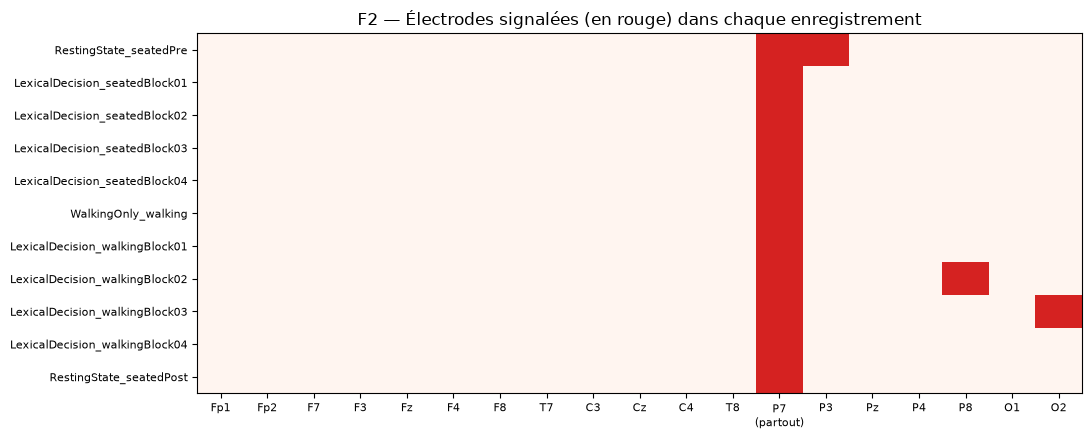

In [16]:
# ---- F2 : les électrodes signalées, enregistrement par enregistrement ------------------------------------------------------------
montrees = choisir_electrodes(AFFICHAGE['F2'], CANAUX, 'F2')                 # les électrodes de la figure (AFFICHAGE, 0.4)
carte = np.array([[c in raisons[nom] for c in montrees] for nom in enregistrements.index], float)
fig, ax = plt.subplots(figsize=(max(4, 0.58 * len(montrees)), 4.5))
ax.imshow(carte, cmap='Reds', vmin=0, vmax=1.4, aspect='auto')
ax.set_xticks(range(len(montrees)))
ax.set_xticklabels([c + ('\n(partout)' if systematiques[CANAUX.index(c)] else '') for c in montrees], fontsize=8)
ax.set_yticks(range(len(carte)))
ax.set_yticklabels(enregistrements.index, fontsize=8)
ax.set_title('F2 — Électrodes signalées (en rouge) dans chaque enregistrement')
plt.tight_layout()
plt.show()

**Que regarder ? (F2)** Chez tous les participants de ce jeu de données, P7 est morte dans tous les enregistrements : elle est laissée de côté
partout et sera reconstruite à l'étape 10. La liste « Laissées de côté partout » sous la cellule 2.6 dit s'il y en a d'autres chez votre
participant. Les électrodes signalées dans un seul enregistrement seront réparées dans celui-là (étape 4).

**Bloc Type 2.** Mettez `SEUIL_Z = 2.5` dans la cellule 2.3, puis relancez toutes les cellules qui suivent. Combien d'électrodes de plus sont
signalées ? Que dit l'étape 12 ? Remettez ensuite `SEUIL_Z = 3.5`.

<details><summary>Indice</summary>

Un seuil plus bas signale plus d'électrodes : elles sont alors exclues de la référence et reconstruites, et le résultat final change un peu.
Un seuil plus haut laisserait passer de vraies mauvaises électrodes.
</details>

## 3. Filtre passe-haut à 0,1 Hz (Blocs Type 1 et 2)

**Pourquoi cette étape ?** Les électrodes sèches dérivent lentement (leur contact avec la peau change) : le signal monte ou descend de
centaines de microvolts en quelques dizaines de secondes. Le filtre passe-haut enlève ces variations très lentes (moins d'une oscillation
toutes les 10 secondes) et garde tout ce qui est plus rapide, dont les ERP. On ne monte pas plus haut que 0,1 Hz : un filtre à 1 Hz
déformerait les ondes lentes comme la N400 et la LPC.

**Ce que fait v1.0.** Un filtre de Butterworth d'ordre 2 à 0,1 Hz, appliqué dans un sens puis dans l'autre (`sosfiltfilt`) pour ne
décaler aucun signal dans le temps, morceau par morceau entre les coupures. Les bords de chaque morceau sont prolongés de 10 s par symétrie.
Il est appliqué **avant** la référence moyenne : les électrodes brutes ont des décalages de plusieurs millivolts, qui gêneraient l'étape 4.

In [17]:
# ---- 3.1 Le filtre passe-haut ----------------------------------------------------------------------------------------------------------
HP_HZ = 0.1                  # modifiable (v1.0 : 0.1 Hz) : fréquence de coupure
ORDRE_HP = 2                 # modifiable (v1.0 : 2) : la raideur du filtre
MARGE_S = 10.0               # ne pas modifier (v1.0 : 10) : prolongement des bords pendant le filtrage (s)
if not 0 < HP_HZ < FS / 2:
    raise ValueError(f'HP_HZ = {HP_HZ} : il faut 0 < HP_HZ < {FS / 2:g} Hz')
sos_hp = butter(ORDRE_HP, HP_HZ, btype='highpass', fs=FS, output='sos')     # le filtre de Butterworth
hp = {}
for nom in gardes:
    hp[nom] = np.zeros_like(brut[nom])
    for a, b in segments[nom]:                                               # chaque morceau continu séparément
        if b - a >= int(round(SEGMENT_MIN_S * FS)):                          # un morceau plus court que SEGMENT_MIN_S (1.3) reste à 0 (BAD)
            hp[nom][:, a:b] = sosfiltfilt(sos_hp, brut[nom][:, a:b], axis=1, padtype='odd', padlen=min(int(MARGE_S * FS), b - a - 1))

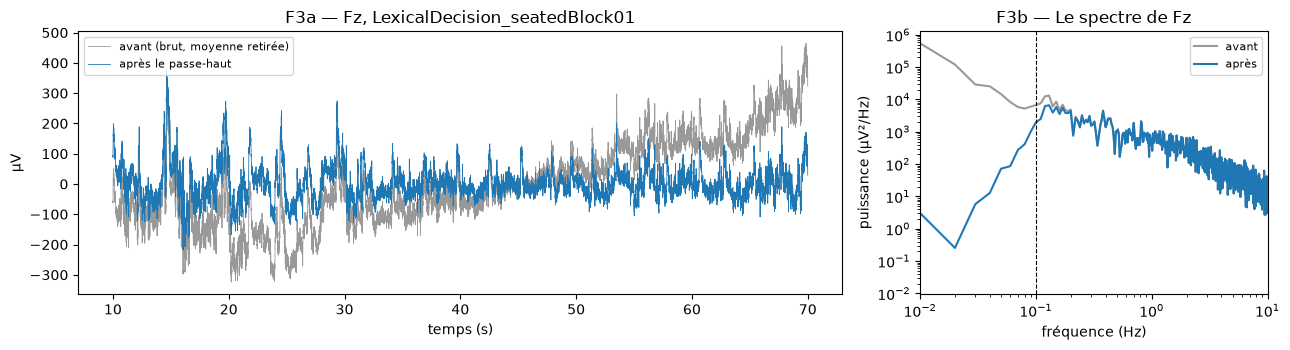

In [18]:
# ---- F3 : avant et après le passe-haut (premier bloc assis) ------------------------------------------------------------------
montrees = choisir_electrodes(AFFICHAGE['F3'], CANAUX, 'F3')                 # les électrodes de la figure (AFFICHAGE, 0.4) : leur moyenne
lignes_f3 = [CANAUX.index(c) for c in montrees]
avant_f3, apres_f3 = brut[exemple_assis][lignes_f3].mean(axis=0), hp[exemple_assis][lignes_f3].mean(axis=0)
t = np.arange(int(10 * FS), min(int(70 * FS), len(avant_f3)))               # 60 s, de 10 à 70 s
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw=dict(width_ratios=[2.2, 1]))
axes[0].plot(t / FS, avant_f3[t] - avant_f3[t].mean(), lw=0.6, color='0.6', label='avant (brut, moyenne retirée)')
axes[0].plot(t / FS, apres_f3[t], lw=0.6, color='C0', label='après le passe-haut')
axes[0].set_xlabel('temps (s)')
axes[0].set_ylabel('µV')
axes[0].set_title(f'F3a — {nom_choix(montrees)}, {exemple_assis}')
axes[0].legend(loc='upper left', fontsize=8)
ok = ~bad[exemple_assis]                                                     # les échantillons utilisables
longueur = min(int(100 * FS), int(ok.sum()))                                 # des fenêtres de 100 s : le spectre descend jusqu'à 0,01 Hz
f_avant, p_avant = welch(avant_f3[ok] - avant_f3[ok].mean(), fs=FS, nperseg=longueur)
f_apres, p_apres = welch(apres_f3[ok], fs=FS, nperseg=longueur)
axes[1].loglog(f_avant[1:], p_avant[1:], color='0.6', label='avant')         # deux échelles logarithmiques (sans la fréquence 0)
axes[1].loglog(f_apres[1:], p_apres[1:], color='C0', label='après')
axes[1].axvline(HP_HZ, color='k', ls='--', lw=0.8)                           # la fréquence de coupure
axes[1].set_xlim(0.01, 10)
axes[1].set_xlabel('fréquence (Hz)')
axes[1].set_ylabel('puissance (µV²/Hz)')
axes[1].set_title(f'F3b — Le spectre de {nom_choix(montrees)}')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Que regarder ? (F3)** Le signal brut (gris) dérive ; après le filtre (bleu), il oscille autour de 0. Les clignements et l'activité rapide
sont intacts. Le spectre (F3b) montre la même chose en fréquences : sous 0,1 Hz (le pointillé), la puissance baisse de plusieurs
ordres de grandeur ; au-dessus, les deux courbes se confondent.

**Bloc Type 2.** Essayez `HP_HZ = 1.0` (et relancez tout ce qui suit). Puis comparez F11b à celle obtenue à 0,1 Hz.
Chez P003, la lente onde négative de la fin de l'époque disparaît (de 800 à 1000 ms en marche : -3,5 µV à 0,1 Hz, +1,7 µV à 1 Hz), et
les premières ondes changent de forme (assis, la P2 de 180 à 250 ms passe de +1,0 à 0,0 µV). Le filtre plus haut garde aussi plus
d'époques en marche (351 au lieu de 317), parce que le signal dérive moins. Il nettoie davantage, mais il déforme l'ERP : c'est pourquoi
le pipeline reste à 0,1 Hz.

### F3c — Pourquoi pas un filtre passe-haut plus haut ? (Bloc Type 3)

Une fréquence de coupure plus haute enlève plus de dérive, mais elle déforme aussi les ondes lentes de l'ERP. Tanner, Morgan-Short et Luck
(2015) ont montré que des coupures de 0,3 Hz et plus peuvent créer un faux effet de polarité opposée avant un vrai effet lent, comme un
effet sur la N400. F3c (avec `OPTIONNEL = True` en 0.4) montre le filtre de 3.1 à trois fréquences de coupure : à gauche, ce qu'il laisse
passer de chaque fréquence ; à droite, ce qu'il fait à une onde lente simulée. La simulation illustre seulement la déformation : ce n'est
pas le modèle d'un vrai ERP. Le Bloc Type 2 ci-dessus montre la même chose sur vos données.

In [19]:
# ---- F3c (Bloc Type 3) : ce qu'un filtre passe-haut plus haut fait à une onde lente -------------------------------------------------
if OPTIONNEL:
    t_sim = np.arange(-2.0, 3.0, 1 / FS)                                     # 5 s de signal simulé autour d'un événement (s)
    onde_lente = -5 * np.exp(-0.5 * ((t_sim - 0.4) / 0.18) ** 2) + 2 * np.exp(-0.5 * ((t_sim - 0.75) / 0.3) ** 2)   # une onde négative, puis une onde positive lente (µV)
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), layout='constrained')
    axes[1].plot(t_sim * 1000, onde_lente, color='0.4', lw=2, label='non filtrée')
    for coupure in (0.1, 0.3, 1.0):
        sos = butter(ORDRE_HP, coupure, btype='highpass', fs=FS, output='sos')   # le filtre de 3.1, à trois fréquences de coupure
        f_reponse, h_reponse = sosfreqz(sos, worN=4096, fs=FS)               # ce qu'il laisse passer, fréquence par fréquence
        axes[0].semilogx(f_reponse[1:], 40 * np.log10(np.maximum(np.abs(h_reponse[1:]), 1e-12)), label=f'{coupure:g} Hz')   # aller-retour : au carré
        axes[1].plot(t_sim * 1000, sosfiltfilt(sos, onde_lente), label=f'{coupure:g} Hz')   # aller-retour, comme en 3.1
    axes[0].axhline(-6, color='0.7', lw=0.8)                                 # -6 dB : la coupure d'un filtre appliqué deux fois
    axes[0].set_xlim(0.01, 10)
    axes[0].set_ylim(-60, 3)
    axes[0].set_xlabel('fréquence (Hz)')
    axes[0].set_ylabel('gain (dB)')
    axes[0].set_title('F3c — Ce que le filtre passe-haut laisse passer')
    axes[0].legend(fontsize=8)
    axes[1].axvline(0, color='0.7', lw=0.8)                                  # l'événement
    axes[1].axhline(0, color='0.7', lw=0.8)
    axes[1].set_xlim(-500, 1500)
    axes[1].set_xlabel("temps depuis l'événement (ms)")
    axes[1].set_ylabel('µV (simulés)')
    axes[1].set_title('F3c — Une onde lente simulée, filtrée')
    axes[1].legend(fontsize=8)
    plt.show()
else:
    print('F3c non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.')

F3c non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.


## 4. La référence moyenne (Bloc Type 1)

**Pourquoi cette étape ?** Pendant l'enregistrement, chaque électrode est mesurée *par rapport à Pz*. Ce choix est arbitraire : tout ce qui
se passe sous Pz apparaît, inversé, dans toutes les électrodes. La **référence moyenne** remplace Pz par la moyenne de toutes les électrodes :
à chaque instant, on soustrait la moyenne des électrodes. Pz redevient alors une électrode comme les autres.

**Ce que fait v1.0**, pour chaque enregistrement :
1. il soustrait la moyenne des **bonnes** électrodes de cet enregistrement ;
2. il **répare** chaque électrode mauvaise dans cet enregistrement seulement : il la remplace par une interpolation de ses voisines (*spline
   sphérique*, avec la fonction `interpolate_bads` de MNE) ;
3. il soustrait la moyenne de **toutes** les électrodes restantes, pour que chaque enregistrement ait la même référence ;
4. les électrodes laissées de côté partout valent 0 pour l'instant.

**La moyenne « sans bouffées ».** Une électrode sèche fait parfois un saut brusque de plusieurs centaines de µV. Dans une moyenne ordinaire,
ce saut se répartirait sur toutes les autres électrodes. Le pipeline calcule donc, dans des fenêtres de 0,25 s, l'écart de chaque électrode à
la médiane des électrodes (filtrées à 1-40 Hz) ; une électrode qui s'écarte plus de 4 fois son écart habituel est laissée hors de la
moyenne pendant cette fenêtre.

> **Reconstruire et référencer sont deux décisions.** Avec 19 électrodes, une électrode reconstruite est une estimation faite à partir de
> ses voisines, pas une nouvelle mesure. Barnes et al. (2025) ont retiré les mauvaises électrodes de ce même casque et pris les deux lobes
> d'oreille (A1, A2) comme référence. Paillard et al. (2025) les ont reconstruites par interpolation et ont pris la référence moyenne. Le
> pipeline Brain Walk les reconstruit pour garder un montage complet, garde la liste des électrodes reconstruites (11.7), et les mesures de
> la section 13 n'utilisent que les électrodes mesurées. Une variante à tester au niveau du projet : une référence moyenne calculée sur les
> seules électrodes mesurées, pour qu'une électrode reconstruite, un mélange de ses voisines, n'entre pas dans la référence.

In [20]:
# ---- 4.1 Première référence : la moyenne des bonnes électrodes, sans les bouffées -------------------------------------------------
FENETRE_BOUFFEE_S = 0.25     # modifiable (v1.0 : 0.25) : durée des fenêtres (s)
SEUIL_BOUFFEE = 4.0          # modifiable (v1.0 : 4) : une électrode qui s'écarte plus de 4 fois son écart habituel sort de la moyenne
sos_bouffee = butter(4, [1.0, 40.0], btype='band', fs=FS, output='sos')     # filtre 1-40 Hz pour repérer les bouffées
fen_bouffee = max(int(round(FENETRE_BOUFFEE_S * FS)), 2)                             # une fenêtre : 75 échantillons
pas_bouffee = max(int(round(FENETRE_BOUFFEE_S * FS / 2)), 1)                         # d'une fenêtre à la suivante : 38 échantillons
ref1 = {}
for nom in gardes:
    x, n = hp[nom], hp[nom].shape[1]
    lignes = np.flatnonzero(bons[nom] & restants)                            # les bonnes électrodes de cet enregistrement
    xb = np.zeros((len(lignes), n))
    for a, b in segments[nom]:
        if b - a >= int(2 * FS):
            xb[:, a:b] = sosfiltfilt(sos_bouffee, x[lignes, a:b], axis=1, padtype='odd', padlen=None)
    ecart = xb - np.median(xb, axis=0, keepdims=True)                        # écart de chaque électrode à la médiane des électrodes
    debuts = np.arange(0, max(n - fen_bouffee, 0) + 1, pas_bouffee)                          # les fenêtres se chevauchent de moitié
    rms = np.stack([np.sqrt((ecart[:, s:s + fen_bouffee] ** 2).mean(axis=1)) for s in debuts], axis=1)   # électrodes x fenêtres
    bouffee = rms > SEUIL_BOUFFEE * np.maximum(np.median(rms, axis=1, keepdims=True), 1e-6)
    poids, compte = np.zeros((len(lignes), n)), np.zeros(n)
    for j, s in enumerate(debuts):                                           # dans combien de fenêtres chaque électrode est calme
        poids[:, s:s + fen_bouffee] += (~bouffee[:, j])[:, None]
        compte[s:s + fen_bouffee] += 1
    poids = poids / np.maximum(compte, 1)[None, :]                           # la part des fenêtres où elle est calme
    poids[:, compte == 0] = 1.0
    total = poids.sum(axis=0)
    reference = np.where(total > 0.5, (poids * x[lignes]).sum(axis=0) / np.maximum(total, 1e-9), x[lignes].mean(axis=0))
    ref1[nom] = x - reference[None, :]                                       # chaque électrode moins la référence

In [21]:
# ---- 4.2 Réparer les électrodes mauvaises dans cet enregistrement seulement ------------------------------------------------------
reparees = {}
for nom in gardes:
    bon_ici, a_reparer = bons[nom] & restants, ~bons[nom] & restants          # bonnes ici ; mauvaises ici, mais pas partout
    reparees[nom] = [c for c, k in zip(CANAUX, a_reparer) if k]
    if not a_reparer.any():
        continue                                                             # rien à réparer
    sources = [c for c, k in zip(CANAUX, bon_ici) if k]
    info = mne.create_info(sources + reparees[nom], FS, 'eeg')               # un objet MNE avec les électrodes utiles
    info.set_montage(MONTAGE)
    vides = np.zeros((len(reparees[nom]), ref1[nom].shape[1]))               # les électrodes à reconstruire, vides pour l'instant
    tmp = mne.io.RawArray(np.vstack([ref1[nom][bon_ici], vides]) * 1e-6, info)   # MNE travaille en volts
    tmp.info['bads'] = reparees[nom]
    tmp.interpolate_bads(reset_bads=True, method=dict(eeg='spline'), origin=(0.0, 0.0, 0.04))   # spline sphérique
    ref1[nom][a_reparer] = tmp.get_data(picks=reparees[nom]) * 1e6           # les électrodes réparées, en µV
print({nom: r for nom, r in reparees.items() if r} or 'aucune électrode réparée')

{'RestingState_seatedPre': ['P3'], 'LexicalDecision_walkingBlock02': ['P8'], 'LexicalDecision_walkingBlock03': ['O2']}


In [22]:
# ---- 4.3 Deuxième référence : la moyenne de toutes les électrodes restantes (le calcul de 4.1) -----------------------------------
base, hors_moyenne = {}, {}
for nom in gardes:
    x, n = ref1[nom], ref1[nom].shape[1]
    lignes = np.flatnonzero(restants)                                        # toutes les électrodes, sauf celles laissées de côté
    xb = np.zeros((len(lignes), n))
    for a, b in segments[nom]:
        if b - a >= int(2 * FS):
            xb[:, a:b] = sosfiltfilt(sos_bouffee, x[lignes, a:b], axis=1, padtype='odd', padlen=None)
    ecart = xb - np.median(xb, axis=0, keepdims=True)
    debuts = np.arange(0, max(n - fen_bouffee, 0) + 1, pas_bouffee)
    rms = np.stack([np.sqrt((ecart[:, s:s + fen_bouffee] ** 2).mean(axis=1)) for s in debuts], axis=1)
    bouffee = rms > SEUIL_BOUFFEE * np.maximum(np.median(rms, axis=1, keepdims=True), 1e-6)
    poids, compte = np.zeros((len(lignes), n)), np.zeros(n)
    for j, s in enumerate(debuts):
        poids[:, s:s + fen_bouffee] += (~bouffee[:, j])[:, None]
        compte[s:s + fen_bouffee] += 1
    poids = poids / np.maximum(compte, 1)[None, :]
    poids[:, compte == 0] = 1.0
    total = poids.sum(axis=0)
    reference = np.where(total > 0.5, (poids * x[lignes]).sum(axis=0) / np.maximum(total, 1e-9), x[lignes].mean(axis=0))
    base[nom] = x - reference[None, :]
    base[nom][systematiques] = 0.0                                           # laissées de côté : reconstruites à l'étape 10
    hors_moyenne[nom] = pd.Series(1 - poids.mean(axis=1), index=[CANAUX[i] for i in lignes])   # part du temps hors de la moyenne

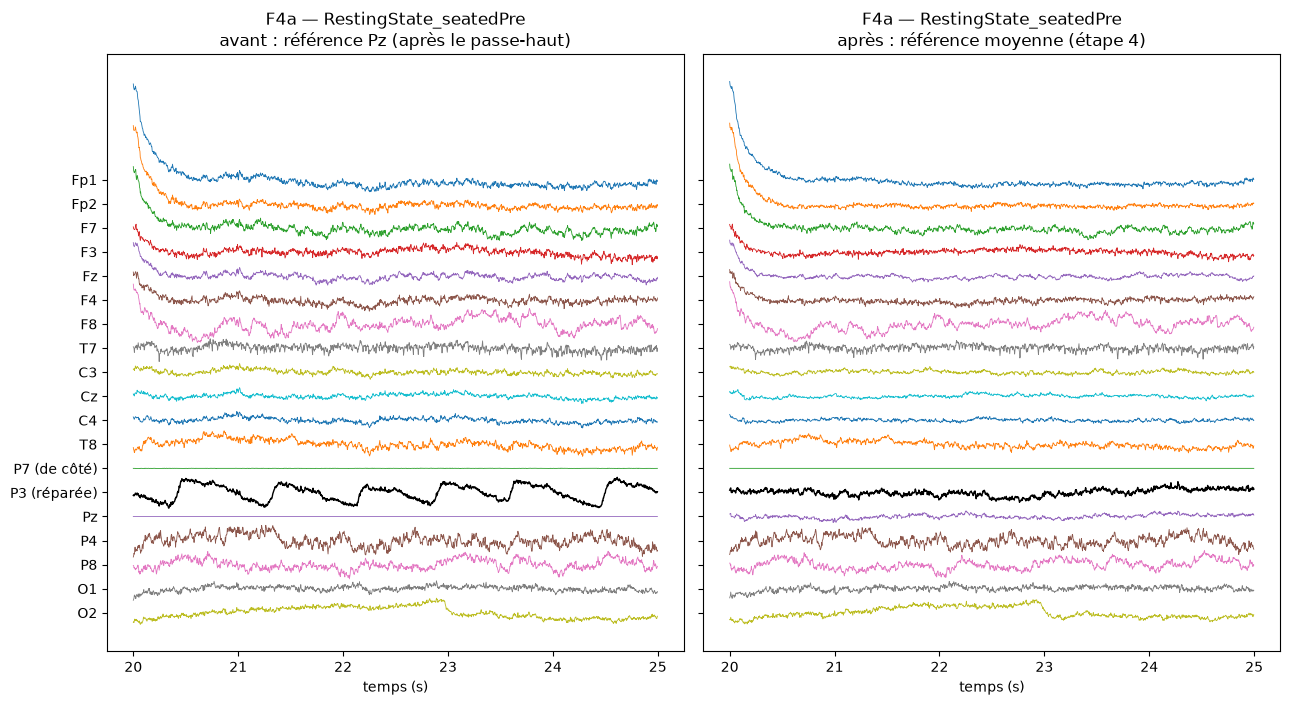

In [23]:
# ---- F4a : avant et après l'étape 4 (référence moyenne et électrodes réparées) ---------------------------------------------------
nom_f4 = next((nom for nom in gardes if reparees[nom]), exemple_assis)       # un enregistrement avec une électrode réparée, s'il y en a un
montrees = choisir_electrodes(AFFICHAGE['F4'], CANAUX, 'F4a')                # les électrodes de la figure (AFFICHAGE, 0.4)
t = fenetre_temps(nom_f4, hp[nom_f4].shape[1], 'F4')                         # de 20 à 25 s
fig, axes = plt.subplots(1, 2, figsize=(13, 0.35 * len(montrees) + 0.5), sharey=True)
for ax, (signal, titre) in zip(axes, [(hp, 'avant : référence Pz (après le passe-haut)'), (base, 'après : référence moyenne (étape 4)')]):
    for k, c in enumerate(montrees):
        i = CANAUX.index(c)
        trace = signal[nom_f4][i, t] - signal[nom_f4][i, t].mean()
        en_noir = c in reparees[nom_f4]                                      # une électrode réparée dans cet enregistrement
        ax.plot(t / FS, trace - 100 * k, lw=1.0 if en_noir else 0.6, color='k' if en_noir else f'C{i % 10}')   # décalées de 100 µV
    ax.set_title(f'F4a — {nom_f4}\n{titre}')
    ax.set_xlabel('temps (s)')
axes[0].set_yticks(-100 * np.arange(len(montrees)))
axes[0].set_yticklabels([c + (' (réparée)' if c in reparees[nom_f4] else '') + (' (de côté)' if systematiques[CANAUX.index(c)] else '') for c in montrees])
plt.tight_layout()
plt.show()

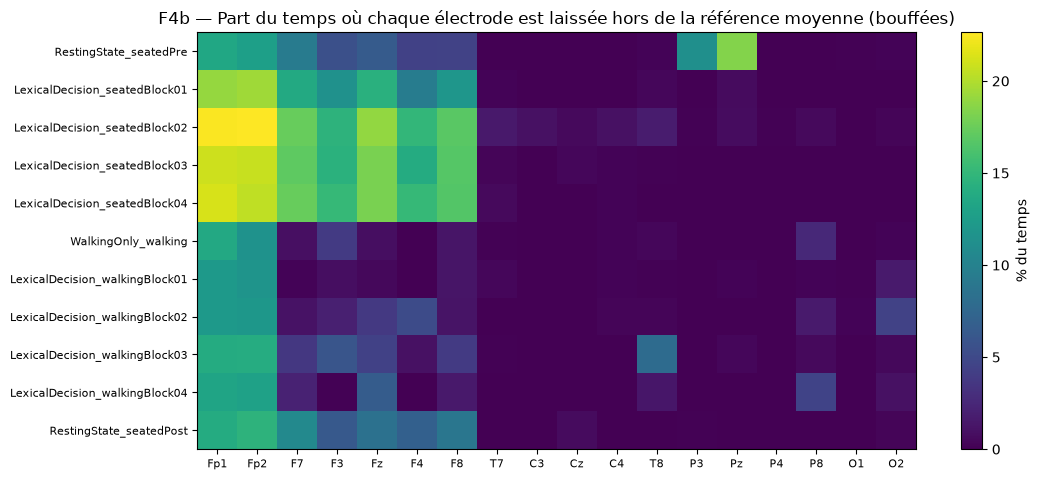

In [24]:
# ---- F4b : le temps passé hors de la moyenne, enregistrement par enregistrement ----------------------------------------------
montrees = choisir_electrodes(AFFICHAGE['F4'], noms_restants, 'F4b')         # les électrodes de la figure (AFFICHAGE, 0.4)
parts_temps = np.array([100 * hors_moyenne[nom][montrees].to_numpy() for nom in gardes])   # enregistrements x électrodes (% du temps)
fig, ax = plt.subplots(figsize=(max(5, 0.62 * len(montrees)), 0.3 * len(gardes) + 1.6))
image = ax.imshow(parts_temps, cmap='viridis', vmin=0, aspect='auto')
ax.set_xticks(range(len(montrees)))
ax.set_xticklabels(montrees, fontsize=8)
ax.set_yticks(range(len(gardes)))
ax.set_yticklabels(gardes, fontsize=8)
fig.colorbar(image, ax=ax, label='% du temps')
ax.set_title('F4b — Part du temps où chaque électrode est laissée hors de la référence moyenne (bouffées)')
plt.tight_layout()
plt.show()

**Que regarder ? (F4a)** À gauche, chaque électrode est mesurée par rapport à Pz : Pz est plate, et ce qui se passe sous Pz se voit,
inversé, sur toutes les autres. À droite, après la référence moyenne, Pz est une électrode comme les autres. Si une électrode a été
réparée dans un enregistrement, la figure montre cet
enregistrement et cette électrode en noir : à gauche, son propre signal ; à droite, son interpolation à partir de ses voisines. Une
électrode laissée de côté partout (P7) vaut 0 jusqu'à l'étape 10.

**Que regarder ? (F4b)** Chaque ligne est un enregistrement. Les électrodes frontales (Fp1, Fp2, F7, F8...) sortent le plus souvent de la moyenne : chaque clignement y fait
un grand écart. Sans cette précaution, chaque clignement se répartirait sur toutes les autres électrodes. La part dépend aussi de
l'enregistrement : en marche, le signal de toutes les électrodes est plus agité, donc un clignement s'en distingue moins souvent.

## 5. La régression sur l'accéléromètre (Bloc Type 1)

**Pourquoi cette étape ?** En marchant, chaque pas secoue le casque : les électrodes sèches glissent un peu et le signal fait une vague à
chaque pas. Le casque contient un accéléromètre qui mesure ces secousses. La régression apprend comment chaque électrode réagit aux
secousses, puis soustrait la partie de l'EEG que l'accéléromètre explique. Le but est de retirer la variance de l'EEG que le
mouvement permet de prédire. Attention : prédire n'est pas prouver. Une activité du cerveau vraiment synchronisée avec la marche peut
aussi suivre le mouvement, et la régression l'enlèverait avec l'artefact. On vérifie donc toujours ce que la correction change (F5). Et l'accéléromètre
mesure la tête, pas les électrodes : chez Kline et al. (2015), l'artefact de la marche variait avec la vitesse, la personne et l'électrode,
et suivait mal l'accélération de la tête.

**Ce que fait v1.0**, pour chaque enregistrement :
1. il lit l'accéléromètre (3 axes, 30 échantillons par seconde) et le cale sur l'horloge de l'EEG (`decalage_mouvement_s`, étape 1.1) ;
2. il calcule 4 signaux de mouvement : l'accélération verticale, avant-arrière et gauche-droite de la tête (la gravité, estimée sous 0,1 Hz,
   donne la verticale), et leur norme ; il les filtre de 0,5 à 12 Hz et les interpole à 300 Hz ;
3. il construit 44 régresseurs : les 4 signaux décalés de 0, 20, 40, ..., 200 ms (une secousse agit sur l'EEG un peu après) ;
4. il ajuste une **régression ridge** (une régression qui pénalise les grands coefficients) par fenêtre de 60 s, fondues l'une dans l'autre,
   avec une pénalité choisie sur des blocs de 5 s mis de côté (un sur quatre) ;
5. si l'accéléromètre explique moins de 2 % de la variance mise de côté, il ne corrige rien ; sinon, il lisse la correction sous 8 Hz et la
   soustrait.

**Le seul changement par rapport à v1.0.** Ici, la correction est soustraite sans être lissée (cellule 5.7). Le lissage sous 8 Hz retirait
de la correction tout ce qui dépasse 8 Hz : les pics des pas entre 8 et 12 Hz restaient dans l'EEG en marche, alors que l'accéléromètre
les prédit. Les fichiers du dossier `pretraite/` ont été produits avec ce même changement. Pour refaire v1.0, mettez
`PASSE_BAS_CORR_HZ = 8.0` en 5.7.

In [25]:
# ---- 5.1 Lire l'accéléromètre et le mettre sur l'horloge de l'EEG ---------------------------------------------------------------
FS_ACC = 30.0                # ne pas modifier : l'accéléromètre du DSI-24 mesure 30 fois par seconde
acc_t, acc_xyz = {}, {}
for nom in gardes:
    fichier = enregistrements.loc[nom, 'mouvement']
    if not fichier.exists():
        continue                                                             # pas d'accéléromètre pour cet enregistrement
    m = pd.read_csv(fichier, sep='\t', header=None, na_values='n/a')         # colonnes : x, y, z (m/s²), puis le temps (s)
    acc_xyz[nom] = m.iloc[:, :3].to_numpy(float)                             # les 3 axes du casque, gravité comprise
    acc_t[nom] = enregistrements.loc[nom, 'decalage_mouvement_s'] + m.iloc[:, 3].to_numpy(float)   # le temps sur l'horloge de l'EEG
print(f"{len(acc_t)} enregistrements avec l'accéléromètre")

11 enregistrements avec l'accéléromètre


In [26]:
# ---- 5.2 Quatre signaux de mouvement, filtrés de 0,5 à 12 Hz et mis à 300 échantillons par seconde -------------------------------
BANDE_ACC = (0.5, 12.0)      # modifiable (v1.0 : 0.5-12 Hz) : la bande des secousses de la marche
verifier_bande('BANDE_ACC', BANDE_ACC, FS_ACC)                               # 30 mesures par seconde : rien au-dessus de 15 Hz
refs_mvt = {}
for nom in acc_t:
    t, acc, n = acc_t[nom], acc_xyz[nom], brut[nom].shape[1]
    ref = np.full((4, n), np.nan)                                            # 4 signaux de mouvement (NaN = pas de mesure)
    for a, b in segments[nom]:
        tau = np.arange(a, b) / FS                                           # le temps de chaque échantillon EEG du morceau
        dedans = (t >= tau[0] - 0.5) & (t <= tau[-1] + 0.5)
        if dedans.sum() < 60:
            continue
        ts, a3 = t[dedans], acc[dedans]
        ordre = np.argsort(ts)
        ts, a3 = ts[ordre], a3[ordre]
        ok = np.concatenate([[True], np.diff(ts) > 1e-4])                    # pas deux mesures au même instant
        ts, a3 = ts[ok], a3[ok]
        if len(ts) < 60:
            continue
        b_g, a_g = butter(4, 0.1 / (FS_ACC / 2))                             # la gravité : l'accélération lissée sous 0,1 Hz
        g = filtfilt(b_g, a_g, a3, axis=0)
        haut = g / np.linalg.norm(g, axis=1, keepdims=True)                  # la direction du haut, à chaque instant
        axe_ap = np.array([1.0, 0.0, 0.0]) - haut[:, [0]] * haut             # l'axe avant-arrière, à l'horizontale
        axe_ap /= np.linalg.norm(axe_ap, axis=1, keepdims=True)
        axe_ml = np.cross(haut, axe_ap)                                      # l'axe gauche-droite
        axe_ml *= np.sign(axe_ml[:, [1]].mean())
        v = np.sum(a3 * haut, axis=1) - np.linalg.norm(g, axis=1)            # verticale, gravité retirée
        ap, ml = np.sum(a3 * axe_ap, axis=1), np.sum(a3 * axe_ml, axis=1)    # avant-arrière et gauche-droite
        f = np.stack([v - v.mean(), ap - ap.mean(), ml - ml.mean()])
        f = np.vstack([f, np.linalg.norm(f, axis=0, keepdims=True)])         # 4e signal : la norme des trois
        f[3] -= f[3].mean()
        f = sosfiltfilt(butter(4, BANDE_ACC, btype='band', fs=FS_ACC, output='sos'), f, axis=1)   # 0,5-12 Hz
        dans_eeg = (tau >= ts[0]) & (tau <= ts[-1])
        if dans_eeg.sum() > 0:
            ref[:, a:b][:, dans_eeg] = PchipInterpolator(ts, f, axis=1)(tau[dans_eeg])   # de 30 à 300 échantillons par seconde
    refs_mvt[nom] = ref

In [27]:
# ---- 5.3 Écrêter les valeurs impossibles, choisir les retards --------------------------------------------------------------------
ECRETAGE_MAD = 20.0           # ne pas modifier (v1.0 : 20) : au-delà, une mesure de l'accéléromètre est impossible
RETARDS_S = (0.0, 0.2, 0.02)  # modifiable (v1.0) : retards de 0 à 200 ms, tous les 20 ms
retards = [int(round(r * FS)) for r in np.arange(RETARDS_S[0], RETARDS_S[1] + RETARDS_S[2] / 2, RETARDS_S[2])]   # en échantillons
refs_ecretees = {}
for nom in refs_mvt:
    refs = refs_mvt[nom].copy()
    for i in range(len(refs)):
        fini = np.isfinite(refs[i])
        if fini.sum() >= 100:
            med = np.median(refs[i, fini])
            mad = np.median(np.abs(refs[i, fini] - med)) + 1e-30
            refs[i, np.abs(refs[i] - med) > ECRETAGE_MAD * 1.4826 * mad] = np.nan   # trop loin de la médiane : retiré
    refs_ecretees[nom] = refs[[i for i in range(len(refs)) if np.isfinite(refs[i]).mean() > 0.5]]   # gardés : mesurés plus de la moitié du temps
print(f'{len(retards)} retards x 4 signaux = {4 * len(retards)} régresseurs')

11 retards x 4 signaux = 44 régresseurs


In [28]:
# ---- 5.4 Les échantillons pour apprendre, ceux mis de côté, et les fenêtres de 60 s ---------------------------------------------
FENETRE_REG_S = 60.0          # modifiable (v1.0 : 60) : une régression par fenêtre de 60 s (le couplage change au cours d'un bloc)
BLOC_VAL_S, UN_SUR = 5.0, 4   # modifiable (v1.0 : 5 s, 1 sur 4) : les blocs mis de côté pour juger chaque pénalité
fen_reg = int(round(FENETRE_REG_S * FS))
masques, debuts_reg = {}, {}
for nom in refs_ecretees:
    x, refs, n = base[nom][restants], refs_ecretees[nom], base[nom].shape[1]   # l'EEG de l'étape 4 et les signaux de mouvement
    plan = np.full((len(refs) * len(retards), n), np.nan)                    # les régresseurs : chaque signal, décalé de chaque retard
    for k, r in enumerate(retards):
        plan[k * len(refs):(k + 1) * len(refs), r:] = refs[:, :n - r]
    utilisable = np.isfinite(plan).all(axis=0) & np.isfinite(x).all(axis=0)   # là où tous les régresseurs existent
    apprend = utilisable & ~bad[nom] & np.isfinite(refs_mvt[nom]).all(axis=0)   # pour apprendre : pas BAD, mouvement mesuré
    mis_de_cote = (np.arange(n) // int(round(BLOC_VAL_S * FS))) % UN_SUR == 0   # un bloc de 5 s sur quatre
    masques[nom] = dict(utilisable=utilisable, apprend=apprend, val=apprend & mis_de_cote, entr=apprend & ~mis_de_cote)
    debuts_reg[nom] = list(range(0, max(n - fen_reg, 0) + 1, max(fen_reg // 2, 1)))   # fenêtres qui se chevauchent de moitié
    if debuts_reg[nom][-1] + fen_reg < n:
        debuts_reg[nom].append(max(n - fen_reg, 0))                          # une dernière fenêtre pour couvrir la fin

In [29]:
# ---- 5.5 Choisir la pénalité : une régression ridge par fenêtre, jugée sur les blocs mis de côté ---------------------------------
ALPHAS = (1e-2, 1e-1, 1.0, 10.0)   # modifiable (v1.0) : les pénalités essayées
GAIN_MIN = 0.02               # modifiable (v1.0 : 0.02) : part minimale de la variance mise de côté que l'accéléromètre doit expliquer
choix_mvt = {}
for nom in refs_ecretees:
    x, refs, n, m = base[nom][restants], refs_ecretees[nom], base[nom].shape[1], masques[nom]
    plan = np.full((len(refs) * len(retards), n), np.nan)                    # les régresseurs de 5.4
    for k, r in enumerate(retards):
        plan[k * len(refs):(k + 1) * len(refs), r:] = refs[:, :n - r]
    p = len(plan)
    if m['apprend'].sum() < 10 * p:
        choix_mvt[nom] = dict(alpha=None, part_inexpliquee=np.nan)           # trop peu de données : pas de correction
        continue
    scores = []
    for alpha in ALPHAS:
        somme, poids_tot = np.zeros_like(x), np.zeros(n)
        for s in debuts_reg[nom]:                                            # une régression ridge par fenêtre
            fin = min(s + fen_reg, n)
            idx = s + np.flatnonzero(m['entr'][s:fin])                       # les échantillons pour apprendre dans cette fenêtre
            if len(idx) < 10 * p:
                continue
            d = plan[:, idx]
            mu, sd = d.mean(axis=1, keepdims=True), d.std(axis=1, keepdims=True) + 1e-30
            dz = (d - mu) / sd                                               # régresseurs centrés réduits
            g = dz @ dz.T
            beta = np.linalg.solve(g + alpha * np.trace(g) / dz.shape[0] * np.eye(dz.shape[0]),
                                   dz @ (x[:, idx] - x[:, idx].mean(axis=1, keepdims=True)).T)   # les coefficients ridge
            u = s + np.flatnonzero(m['utilisable'][s:fin])
            w = np.hanning(fin - s + 2)[1:-1]                                # fenêtre de Hann : les fenêtres se fondent l'une dans l'autre
            somme[:, u] += (((plan[:, u] - mu) / sd).T @ beta).T * w[u - s]
            poids_tot[u] += w[u - s]
        if poids_tot.max() == 0:
            break                                                            # aucune fenêtre n'a pu apprendre
        prediction = np.zeros_like(x)
        prediction[:, poids_tot > 1e-9] = somme[:, poids_tot > 1e-9] / poids_tot[poids_tot > 1e-9]
        scores.append((float(np.var(x[:, m['val']] - prediction[:, m['val']]) / max(np.var(x[:, m['val']]), 1e-30)), alpha))
    ratio, alpha = min(scores) if scores else (np.nan, None)                # la pénalité qui laisse le moins de variance inexpliquée
    choix_mvt[nom] = dict(alpha=alpha if scores and ratio < 1.0 - GAIN_MIN else None, part_inexpliquee=ratio)
pd.DataFrame(choix_mvt).T

,alpha,part_inexpliquee
RestingState_seatedPre,NaN,1.001798
LexicalDecision_seatedBlock01,NaN,0.994025
LexicalDecision_seatedBlock02,NaN,0.996289
LexicalDecision_seatedBlock03,NaN,1.003351
LexicalDecision_seatedBlock04,NaN,1.001269
WalkingOnly_walking,0.01,0.751611
LexicalDecision_walkingBlock01,0.10,0.880059
LexicalDecision_walkingBlock02,0.01,0.909728
LexicalDecision_walkingBlock03,0.10,0.953522
LexicalDecision_walkingBlock04,0.01,0.916315


In [30]:
# ---- 5.6 La régression avec la pénalité choisie, sur tous les échantillons pour apprendre ----------------------------------------
prediction_mvt = {}
for nom in choix_mvt:
    alpha = choix_mvt[nom]['alpha']
    if alpha is None:
        continue                                                             # l'accéléromètre n'explique pas cet EEG : rien à enlever
    x, refs, n, m = base[nom][restants], refs_ecretees[nom], base[nom].shape[1], masques[nom]
    plan = np.full((len(refs) * len(retards), n), np.nan)                    # les régresseurs de 5.4
    for k, r in enumerate(retards):
        plan[k * len(refs):(k + 1) * len(refs), r:] = refs[:, :n - r]
    somme, poids_tot = np.zeros_like(x), np.zeros(n)
    for s in debuts_reg[nom]:                                                # le calcul de 5.5, avec tous les échantillons pour apprendre
        fin = min(s + fen_reg, n)
        idx = s + np.flatnonzero(m['apprend'][s:fin])
        if len(idx) < 10 * len(plan):
            continue
        d = plan[:, idx]
        mu, sd = d.mean(axis=1, keepdims=True), d.std(axis=1, keepdims=True) + 1e-30
        dz = (d - mu) / sd
        g = dz @ dz.T
        beta = np.linalg.solve(g + alpha * np.trace(g) / dz.shape[0] * np.eye(dz.shape[0]),
                               dz @ (x[:, idx] - x[:, idx].mean(axis=1, keepdims=True)).T)
        u = s + np.flatnonzero(m['utilisable'][s:fin])
        w = np.hanning(fin - s + 2)[1:-1]
        somme[:, u] += (((plan[:, u] - mu) / sd).T @ beta).T * w[u - s]
        poids_tot[u] += w[u - s]
    prediction_mvt[nom] = np.zeros_like(x)                                   # ce que l'accéléromètre explique de chaque électrode
    prediction_mvt[nom][:, poids_tot > 1e-9] = somme[:, poids_tot > 1e-9] / poids_tot[poids_tot > 1e-9]

In [31]:
# ---- 5.7 Soustraire la correction -------------------------------------------------------------------------------------------------
PASSE_BAS_CORR_HZ = None      # modifiable (v1.0 : 8) : None, la correction n'est pas lissée ; 8.0, elle est lissée sous 8 Hz comme dans v1.0
sos_corr = butter(4, PASSE_BAS_CORR_HZ, btype='lowpass', fs=FS, output='sos') if PASSE_BAS_CORR_HZ else None
propre = {}
for nom in gardes:
    propre[nom] = base[nom].copy()                                           # par défaut, rien à enlever
    if nom not in prediction_mvt:
        continue
    correction = np.zeros_like(prediction_mvt[nom])
    for a, b in segments[nom]:                                               # morceau par morceau
        if b - a >= int(round(SEGMENT_MIN_S * FS)):
            correction[:, a:b] = (prediction_mvt[nom][:, a:b] if sos_corr is None else
                                  sosfiltfilt(sos_corr, prediction_mvt[nom][:, a:b], axis=1, padtype='odd', padlen=min(int(5 * FS), b - a - 1)))
    propre[nom][restants] = base[nom][restants] - correction                 # l'EEG moins ce que les secousses expliquent
    print(f'{nom:32s} pénalité {choix_mvt[nom]["alpha"]:g}, l\'accéléromètre explique '
          f'{100 * (1 - choix_mvt[nom]["part_inexpliquee"]):.0f} % de la variance mise de côté')

WalkingOnly_walking              pénalité 0.01, l'accéléromètre explique 25 % de la variance mise de côté
LexicalDecision_walkingBlock01   pénalité 0.1, l'accéléromètre explique 12 % de la variance mise de côté
LexicalDecision_walkingBlock02   pénalité 0.01, l'accéléromètre explique 9 % de la variance mise de côté
LexicalDecision_walkingBlock03   pénalité 0.1, l'accéléromètre explique 5 % de la variance mise de côté
LexicalDecision_walkingBlock04   pénalité 0.01, l'accéléromètre explique 8 % de la variance mise de côté


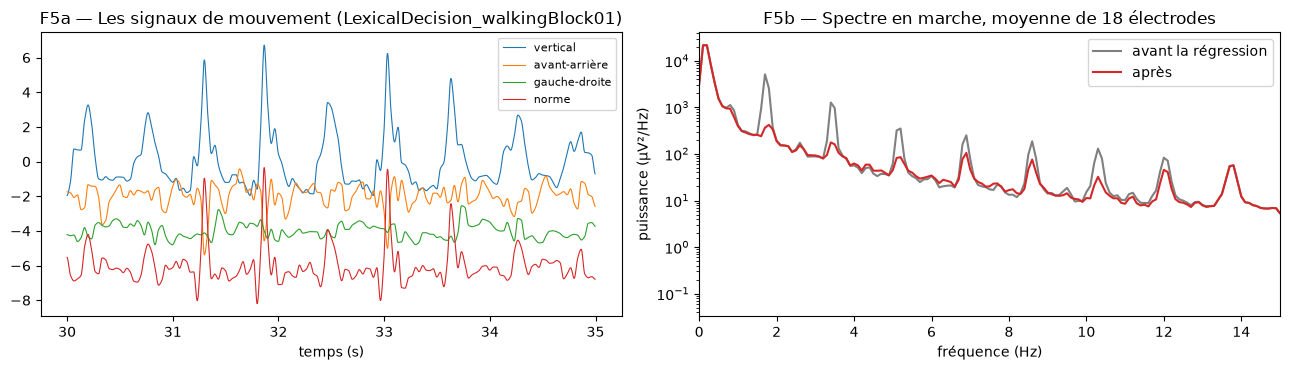

In [32]:
# ---- F5 : le spectre de l'EEG en marche, avant et après la régression -------------------------------------------------------------
montrees = choisir_electrodes(AFFICHAGE['F5'], noms_restants, 'F5b')         # les électrodes de F5b (AFFICHAGE, 0.4) : leur spectre moyen
lignes_f5 = [noms_restants.index(c) for c in montrees]
x_avant = base[exemple_marche][restants][lignes_f5][:, ~bad[exemple_marche]]
x_apres = propre[exemple_marche][restants][lignes_f5][:, ~bad[exemple_marche]]
f, p_avant = welch(x_avant, fs=FS, nperseg=int(10 * FS))                    # spectre de puissance (fenêtres de 10 s)
f, p_apres = welch(x_apres, fs=FS, nperseg=int(10 * FS))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
t = fenetre_temps(exemple_marche, refs_mvt[exemple_marche].shape[1], 'F5')  # de 30 à 35 s
for k, nom_signal in enumerate(['vertical', 'avant-arrière', 'gauche-droite', 'norme']):
    axes[0].plot(t / FS, refs_mvt[exemple_marche][k, t] - 2 * k, lw=0.8, label=nom_signal)
axes[0].set_xlabel('temps (s)')
axes[0].set_title(f'F5a — Les signaux de mouvement ({exemple_marche})')
axes[0].legend(fontsize=8, loc='upper right')
axes[1].semilogy(f, p_avant.mean(axis=0), color='0.5', label='avant la régression')
axes[1].semilogy(f, p_apres.mean(axis=0), color='C3', label='après')
axes[1].set_xlim(0, 15)
axes[1].set_xlabel('fréquence (Hz)')
axes[1].set_ylabel('puissance (µV²/Hz)')
axes[1].set_title(f'F5b — Spectre en marche, {nom_choix(montrees)}')
axes[1].legend()
plt.tight_layout()
plt.show()

**Que regarder ? (F5)** Les signaux de mouvement (F5a) se répètent à chaque pas, à peu près deux fois par seconde. Dans le spectre de l'EEG
(F5b), les pics à la fréquence des pas et à ses multiples baissent après la régression, jusqu'à 12 Hz. Au-dessus, ils restent : les
signaux de mouvement sont filtrés de 0,5 à 12 Hz (`BANDE_ACC`), la régression ne peut donc pas les prédire (et un accéléromètre qui
mesure 30 fois par seconde ne peut rien suivre au-delà de 15 Hz). Le filtre à 30 Hz de l'étape 10 ne les touche pas non plus. Avec `PASSE_BAS_CORR_HZ = 8.0` (le réglage de v1.0), les pics entre 8 et 12 Hz restent aussi : la correction
est lissée sous 8 Hz. En général, la régression est appliquée aux blocs en
marche et ne change rien aux blocs assis : assis, l'accéléromètre n'explique pas l'EEG. Le tableau de 5.5 dit ce qu'il en est chez votre
participant (un `alpha` à `NaN` veut dire que rien n'est corrigé).

Une baisse des pics liés aux pas montre que la régression a réduit la part de l'EEG qui suit le mouvement. Elle ne montre pas que tout ce
qui a été retiré était du bruit.

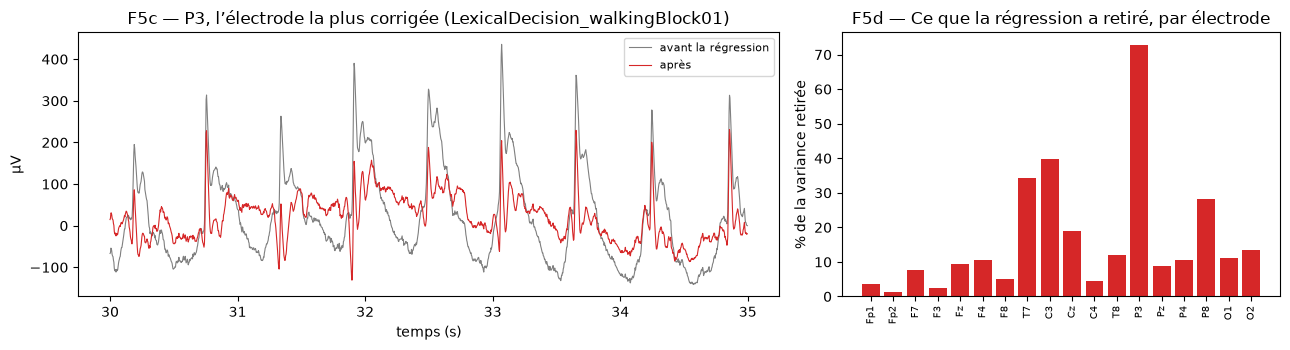

In [33]:
# ---- F5c : avant et après la régression, dans le temps et électrode par électrode ------------------------------------------------
ok = ~bad[exemple_marche]                                                    # les échantillons utilisables
x_avant, x_apres = base[exemple_marche][restants], propre[exemple_marche][restants]
part_retiree = 100 * (1 - x_apres[:, ok].var(axis=1) / x_avant[:, ok].var(axis=1))   # % de la variance retirée, par électrode
if AFFICHAGE['F5c'] == 'auto':
    i_max = int(np.argmax(part_retiree))                                     # l'électrode la plus corrigée
else:
    i_max = noms_restants.index(choisir_electrodes(AFFICHAGE['F5c'], noms_restants, 'F5c')[0])   # l'électrode d'AFFICHAGE (0.4)
if exemple_marche not in prediction_mvt:
    print(f'Rien n\'a été corrigé dans {exemple_marche} (alpha à NaN en 5.5) : avant et après se confondent.')
t = fenetre_temps(exemple_marche, x_avant.shape[1], 'F5')                    # les 5 s de F5a
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw=dict(width_ratios=[1.6, 1]))
axes[0].plot(t / FS, x_avant[i_max, t], color='0.5', lw=0.8, label='avant la régression')
axes[0].plot(t / FS, x_apres[i_max, t], color='C3', lw=0.8, label='après')
axes[0].set_xlabel('temps (s)')
axes[0].set_ylabel('µV')
axes[0].set_title(f'F5c — {noms_restants[i_max]}{", l’électrode la plus corrigée" if AFFICHAGE["F5c"] == "auto" else ""} ({exemple_marche})')
axes[0].legend(fontsize=8, loc='upper right')
montrees = choisir_electrodes(AFFICHAGE['F5'], noms_restants, 'F5d')         # les électrodes de F5d (AFFICHAGE, 0.4)
lignes_f5 = [noms_restants.index(c) for c in montrees]
axes[1].bar(range(len(montrees)), part_retiree[lignes_f5], color='C3')
axes[1].set_xticks(range(len(montrees)))
axes[1].set_xticklabels(montrees, fontsize=7, rotation=90)
axes[1].set_ylabel('% de la variance retirée')
axes[1].set_title('F5d — Ce que la régression a retiré, par électrode')
plt.tight_layout()
plt.show()

**Que regarder ? (F5c, F5d)** À l'électrode la plus corrigée (F5c), la vague lente qui suit chaque pas est en grande partie retirée ; les
pointes brèves restent, parce que l'accéléromètre ne les prédit pas. F5d montre que la régression ne retire pas la même chose partout : chez
P003, au premier bloc en marche, elle retire 73 % de la variance de P3 et moins de 15 % à la plupart des autres électrodes. Une électrode très
corrigée est souvent une électrode qui bouge sur la tête à chaque pas : la régression réduit le problème sans le régler (chez P003, P3 sera
reconstruite dans toutes les époques à l'étape 11.3).

### F5e et F5f — L'EEG autour de chaque contact du talon, et où tombent les mots dans le pas (Bloc Type 3)

L'accéléromètre mesure la tête, pas les électrodes : une électrode peut bouger à chaque pas sans que l'accélération de la tête le prédise
(Kline et al., 2015). Une vérification qui se passe de l'accéléromètre fait la moyenne de l'EEG autour de chaque contact du talon : Gwin et
al. (2010) ont construit leur correction de l'artefact de la marche à partir de telles moyennes, calées sur les pas. Les fichiers
d'événements contiennent les contacts du talon (`heel_contact` ; ils ne disent pas de quel pied).
- **F5e** : l'EEG d'`AFFICHAGE['PAS']` (0.4) autour de chaque contact du talon du premier bloc en marche, avant et après la régression. Une
  onde qui revient à chaque contact et qui reste après la régression est un mouvement que la régression n'a pas retiré.
- **F5f** : où tombe chaque mot dans le pas, de 0 (un contact du talon) à 1 (le suivant), dans tous les blocs en marche. Si les mots
  tombaient surtout à un moment du pas, l'artefact du pas serait calé sur les mots et ne s'effacerait pas dans l'ERP. R mesure cette
  concentration : 0 quand les mots sont répartis également dans le pas, 1 quand ils tombent tous au même moment. Chez P003, R = 0,05 :
  les 399 mots des blocs en marche sont répartis également dans le pas.

In [34]:
# ---- F5e et F5f (Bloc Type 3) : l'EEG autour de chaque contact du talon, et la phase du pas à chaque mot ---------------------------
if OPTIONNEL:
    montrees = choisir_electrodes(AFFICHAGE['PAS'], noms_restants, 'F5e')   # les électrodes de F5e (AFFICHAGE, 0.4) : leur moyenne
    lignes_pas = [CANAUX.index(c) for c in montrees]
    demi = int(round(0.6 * FS))                                              # 0,6 s de chaque côté du contact : environ un pas
    talons = evenements[exemple_marche].loc[evenements[exemple_marche]['trial_type'] == 'heel_contact', 'sample'].to_numpy(int)
    talons = [h for h in talons if h >= demi and h + demi < len(bad[exemple_marche]) and not bad[exemple_marche][h - demi:h + demi + 1].any()]
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), layout='constrained')
    for signal, etiquette, couleur in ((base, 'avant la régression (4)', '0.5'), (propre, 'après la régression (5)', 'C3')):
        if talons:
            calee = np.mean([signal[exemple_marche][lignes_pas, h - demi:h + demi + 1].mean(axis=0) for h in talons], axis=0)
            axes[0].plot(np.arange(-demi, demi + 1) / FS * 1000, calee - calee.mean(), color=couleur, label=etiquette)
    axes[0].axvline(0, color='0.4', lw=0.8)                                  # le contact du talon
    axes[0].set_xlabel('temps depuis le contact du talon (ms)')
    axes[0].set_ylabel('µV')
    axes[0].set_title(f'F5e — {nom_choix(montrees)}, {len(talons)} contacts du talon ({exemple_marche})')
    axes[0].legend(fontsize=8)
    phases = []                                                              # où tombe chaque mot dans le pas (de 0 à 1)
    for nom in gardes:
        contacts = np.sort(evenements[nom].loc[evenements[nom]['trial_type'] == 'heel_contact', 'sample'].to_numpy(int))
        if enregistrements.loc[nom, 'genre'] != 'walking' or len(contacts) < 2:
            continue
        mots = evenements[nom].loc[evenements[nom]['trial_type'] == 'stimulus', 'sample'].to_numpy(int)
        k = np.clip(np.searchsorted(contacts, mots) - 1, 0, len(contacts) - 2)   # le dernier contact avant chaque mot
        duree_pas = contacts[k + 1] - contacts[k]                            # la durée de ce pas (échantillons)
        dedans = (mots >= contacts[k]) & (mots < contacts[k + 1]) & (duree_pas < 1.5 * FS)   # sans chevaucher une pause des contacts
        phases.extend((mots[dedans] - contacts[k[dedans]]) / duree_pas[dedans])
    R = np.abs(np.mean(np.exp(2j * np.pi * np.array(phases)))) if phases else np.nan
    axes[1].hist(phases, bins=np.linspace(0, 1, 11), color='C1')
    axes[1].set_xlabel("phase du pas à l'apparition du mot (0 : contact du talon, 1 : le suivant)")
    axes[1].set_ylabel('mots')
    axes[1].set_title(f'F5f — {len(phases)} mots des blocs en marche, R = {R:.2f}')
    plt.show()
else:
    print('F5e et F5f non exécutées : mettez OPTIONNEL = True dans la cellule 0.4.')

F5e et F5f non exécutées : mettez OPTIONNEL = True dans la cellule 0.4.


## 6. Repérer les clignements et les saccades (Bloc Type 1)

**Pourquoi cette étape ?** Il n'y a pas d'électrode sous les yeux dans ce casque. Le pipeline repère donc les clignements et les mouvements
horizontaux des yeux (*saccades*) dans l'EEG lui-même. Il s'en sert aux étapes 7 à 9 pour savoir quelles composantes viennent des yeux et où
appliquer le filtre des clignements. Il les cherche dans le signal de l'étape 4, avant la régression sur l'accéléromètre.

**Ce que fait v1.0.**
- **Clignements** : la moyenne de Fp1 et Fp2 filtrée de 1 à 10 Hz. Un pic compte s'il dépasse la médiane de plus de 5 écarts-types robustes
  et au moins 50 µV, s'il est à plus de 0,2 s du suivant et s'il dure de 0,10 à 0,50 s à mi-hauteur.
- **Saccades** : la différence droite - gauche des électrodes frontales (F8 - F7 et Fp2 - Fp1 avec un poids 1, F4 - F3 et T8 - T7 avec un
  poids 0,5), lissée sous 30 Hz. Une saccade est un saut rapide : la vitesse dépasse 6 écarts-types robustes pendant au moins 10 ms, à plus de
  0,3 s d'un clignement.

In [35]:
# ---- 6.1 Les clignements -------------------------------------------------------------------------------------------------------
BANDE_CLIGNEMENT = (1.0, 10.0)   # modifiable (v1.0 : 1-10 Hz)
SEUIL_CLIGNEMENT_MAD = 5.0       # modifiable (v1.0 : 5)
MIN_CLIGNEMENT_UV = 50.0         # modifiable (v1.0 : 50 µV)
DUREE_CLIGNEMENT_S = (0.10, 0.50)   # modifiable (v1.0 : 0,10-0,50 s à mi-hauteur)
ECART_MIN_CLIG_S = 0.2           # modifiable (v1.0 : 0,2 s) : le plus petit temps entre deux clignements
verifier_bande('BANDE_CLIGNEMENT', BANDE_CLIGNEMENT, FS)                     # arrête si un choix est impossible (0.4)
verifier_fenetre('DUREE_CLIGNEMENT_S', DUREE_CLIGNEMENT_S)
sos_clig = butter(4, list(BANDE_CLIGNEMENT), btype='band', fs=FS, output='sos')
fp = [noms_restants.index(c) for c in ('Fp1', 'Fp2') if c in noms_restants]  # les électrodes au-dessus des yeux
clignements, signal_clig = {}, {}                                            # signal_clig : ce que voit le détecteur (F6a)
for nom in gardes:
    if not fp:
        clignements[nom] = np.array([])                                      # ni Fp1 ni Fp2 : pas de clignement repérable
        continue
    x, ok = base[nom][restants], ~bad[nom]                                   # le signal de l'étape 4
    moyenne_fp, clig_filtre = x[fp].mean(axis=0), np.zeros(x.shape[1])
    for a, b in segments[nom]:
        if b - a >= int(4 * FS):
            clig_filtre[a:b] = sosfiltfilt(sos_clig, moyenne_fp[a:b], padtype='odd', padlen=min(int(3 * FS), b - a - 1))
    med = np.median(clig_filtre[ok])
    seuil = max(MIN_CLIGNEMENT_UV, med + SEUIL_CLIGNEMENT_MAD * 1.4826 * np.median(np.abs(clig_filtre[ok] - med)))
    pics_clig, _ = find_peaks(np.where(ok, clig_filtre, 0.0), height=seuil, distance=int(ECART_MIN_CLIG_S * FS))   # assez hauts, à 0,2 s l'un de l'autre
    largeur = peak_widths(clig_filtre, pics_clig, rel_height=0.5)[0] / FS if len(pics_clig) else np.array([])   # largeur à mi-hauteur (s)
    clignements[nom] = pics_clig[(largeur >= DUREE_CLIGNEMENT_S[0]) & (largeur <= DUREE_CLIGNEMENT_S[1])] / FS   # le temps de chaque clignement
    signal_clig[nom] = (clig_filtre, seuil)

In [36]:
# ---- 6.2 Les saccades -------------------------------------------------------------------------------------------------------------
SEUIL_SACCADE_MAD = 6.0          # modifiable (v1.0 : 6)
DUREE_MIN_SACCADE_MS = 10.0      # modifiable (v1.0 : 10 ms)
ECART_CLIGNEMENT_S = 0.30        # modifiable (v1.0 : 0,3 s) : une saccade si proche d'un clignement est ignorée
PASSE_BAS_SAC_HZ = 30.0          # modifiable (v1.0 : 30 Hz) : le lissage du signal horizontal
PAIRES = [('F8', 'F7', 1.0), ('Fp2', 'Fp1', 1.0), ('F4', 'F3', 0.5), ('T8', 'T7', 0.5)]   # ne pas modifier : droite, gauche, poids
if not 0 < PASSE_BAS_SAC_HZ < FS / 2:
    raise ValueError(f'PASSE_BAS_SAC_HZ = {PASSE_BAS_SAC_HZ} : il faut 0 < PASSE_BAS_SAC_HZ < {FS / 2:g} Hz')
sos_sac = butter(4, PASSE_BAS_SAC_HZ, btype='lowpass', fs=FS, output='sos')
paires = [(d, g, p) for d, g, p in PAIRES if d in noms_restants and g in noms_restants]
saccades, signal_sac = {}, {}                                                # signal_sac : ce que voit le détecteur (F6c)
for nom in gardes:
    if not paires:
        saccades[nom] = np.array([])                                         # aucune paire gauche-droite : pas de saccade repérable
        continue
    x, ok = base[nom][restants], ~bad[nom]
    h = 0
    for d, g, p in paires:                                                   # la moyenne pondérée des différences droite - gauche
        h = h + p * (x[noms_restants.index(d)] - x[noms_restants.index(g)])
    h = h / sum(p for _, _, p in paires)
    lisse = np.zeros(x.shape[1])
    for a, b in segments[nom]:
        if b - a >= int(4 * FS):
            lisse[a:b] = sosfiltfilt(sos_sac, h[a:b], padtype='odd', padlen=min(int(3 * FS), b - a - 1))
    vitesse = np.gradient(lisse) * FS                                        # la vitesse du signal horizontal (µV/s)
    sd = 1.4826 * np.median(np.abs(vitesse[ok] - np.median(vitesse[ok])))
    rapide = (np.abs(vitesse) > SEUIL_SACCADE_MAD * sd) & ok                  # les moments où le signal change vite
    bords = np.diff(np.concatenate([[0], rapide.astype(int), [0]]))
    debuts, fins = np.flatnonzero(bords == 1), np.flatnonzero(bords == -1)    # début et fin de chaque moment rapide
    n_min = max(int(round(DUREE_MIN_SACCADE_MS / 1000 * FS)), 1)
    saccades[nom] = np.array([a / FS for a, b in zip(debuts, fins) if b - a >= n_min
                              and not (len(clignements[nom]) and np.min(np.abs(clignements[nom] - a / FS)) < ECART_CLIGNEMENT_S)])
    signal_sac[nom] = (lisse, vitesse, SEUIL_SACCADE_MAD * sd)
    print(f'{nom:32s} {len(clignements[nom]):4d} clignements, {len(saccades[nom]):4d} saccades')

RestingState_seatedPre             55 clignements,    1 saccades
LexicalDecision_seatedBlock01      94 clignements,    1 saccades
LexicalDecision_seatedBlock02     109 clignements,    6 saccades
LexicalDecision_seatedBlock03     103 clignements,    0 saccades


LexicalDecision_seatedBlock04     108 clignements,    0 saccades
WalkingOnly_walking               123 clignements,  137 saccades
LexicalDecision_walkingBlock01     67 clignements,   74 saccades
LexicalDecision_walkingBlock02     62 clignements,  252 saccades
LexicalDecision_walkingBlock03     68 clignements,  128 saccades
LexicalDecision_walkingBlock04     72 clignements,  126 saccades
RestingState_seatedPost            59 clignements,   11 saccades


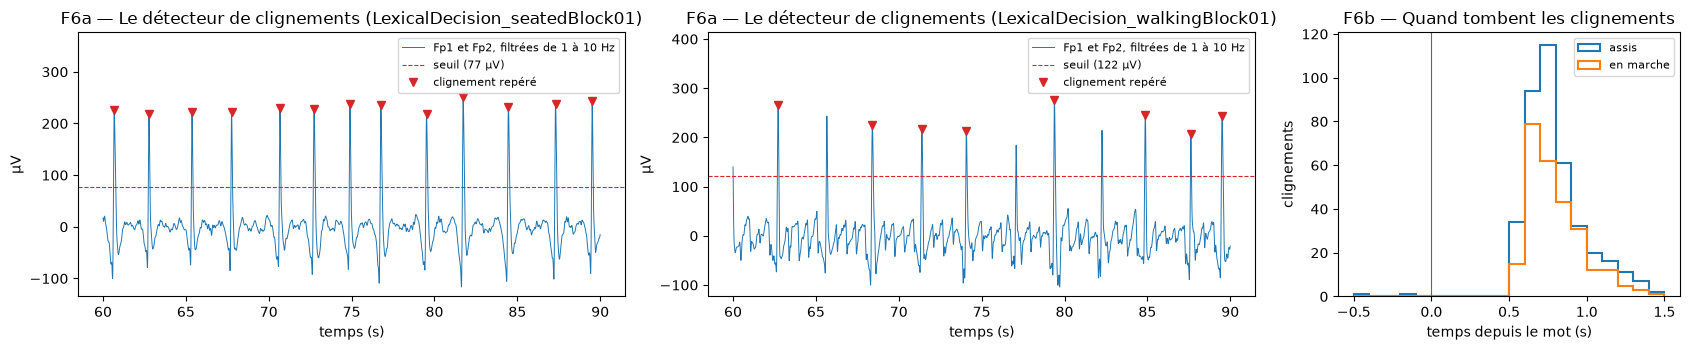

In [37]:
# ---- F6 : ce que voit le détecteur des clignements, et quand ils tombent par rapport aux mots --------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 3.6), gridspec_kw=dict(width_ratios=[1.6, 1.6, 1]))
for ax, nom in zip(axes[:2], [exemple_assis, exemple_marche]):
    if nom not in signal_clig:
        ax.text(0.5, 0.5, 'ni Fp1 ni Fp2 : aucun clignement repéré', transform=ax.transAxes, ha='center')
        continue
    signal, seuil = signal_clig[nom]                                         # le signal du détecteur et son seuil (6.1)
    t = fenetre_temps(nom, len(signal), 'F6')                                # 30 s, de 60 à 90 s
    dans = clignements[nom][(clignements[nom] >= t[0] / FS) & (clignements[nom] < t[-1] / FS)]
    ax.plot(t / FS, signal[t], lw=0.7, label='Fp1 et Fp2, filtrées de 1 à 10 Hz')
    ax.axhline(seuil, color='C3', ls='--', lw=0.8, label=f'seuil ({seuil:.0f} µV)')
    ax.plot(dans, signal[np.round(dans * FS).astype(int)], 'v', color='C3', label='clignement repéré')
    ax.set_ylim(None, 1.4 * ax.get_ylim()[1])                                # de la place pour la légende
    ax.set_xlabel('temps (s)')
    ax.set_ylabel('µV')
    ax.set_title(f'F6a — Le détecteur de clignements ({nom})')
    ax.legend(loc='upper right', fontsize=8)
ax = axes[2]
for posture, etiquette, couleur in (('seated', 'assis', 'C0'), ('walking', 'en marche', 'C1')):
    ecarts = []                                                              # le temps de chaque clignement par rapport à chaque mot (s)
    for nom in gardes:
        if enregistrements.loc[nom, 'tache'] == 'LexicalDecision' and enregistrements.loc[nom, 'posture'] == posture:
            mots = evenements[nom].loc[evenements[nom]['trial_type'] == 'stimulus', 'sample'].to_numpy() / FS   # l'apparition des mots (s)
            d = (clignements[nom][None, :] - mots[:, None]).ravel()
            ecarts.extend(d[(d >= -0.5) & (d < 1.5)])
    ax.hist(ecarts, bins=np.arange(-0.5, 1.51, 0.1), histtype='step', lw=1.5, color=couleur, label=etiquette)
ax.axvline(0, color='0.4', lw=0.8)                                           # l'apparition du mot
ax.set_xlabel('temps depuis le mot (s)')
ax.set_ylabel('clignements')
ax.set_title('F6b — Quand tombent les clignements')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [38]:
# ---- F6c (Bloc Type 3) : ce que voit le détecteur des saccades -------------------------------------------------------------------
if OPTIONNEL:
    fig, axes = plt.subplots(2, 2, figsize=(14, 6), layout='constrained')
    for ligne, nom in enumerate([exemple_assis, exemple_marche]):
        if nom not in signal_sac:
            axes[ligne, 0].text(0.5, 0.5, 'aucune paire gauche-droite : aucune saccade repérée', transform=axes[ligne, 0].transAxes, ha='center')
            continue
        lisse_6c, vitesse_6c, seuil_6c = signal_sac[nom]                     # les signaux de 6.2
        t = fenetre_temps(nom, len(lisse_6c), 'F6')                          # les 30 s de F6a
        detectees = saccades[nom][(saccades[nom] >= t[0] / FS) & (saccades[nom] < t[-1] / FS)]
        axes[ligne, 0].plot(t / FS, lisse_6c[t], lw=0.7)
        axes[ligne, 0].set_ylabel('µV')
        axes[ligne, 0].set_title(f'F6c — Droite - gauche, lissé ({nom})')
        axes[ligne, 1].plot(t / FS, vitesse_6c[t], lw=0.7)
        axes[ligne, 1].axhline(seuil_6c, color='C3', ls='--', lw=0.8, label='seuil')
        axes[ligne, 1].axhline(-seuil_6c, color='C3', ls='--', lw=0.8)
        axes[ligne, 1].plot(detectees, vitesse_6c[np.round(detectees * FS).astype(int)], 'v', color='C3', label='saccade repérée')
        axes[ligne, 1].set_ylabel('µV/s')
        axes[ligne, 1].set_title('sa vitesse, et le seuil de 6.2')
        axes[ligne, 1].legend(fontsize=8, loc='upper right')
        for ax in axes[ligne]:
            ax.set_xlabel('temps (s)')
    plt.show()
else:
    print('F6c non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.')

F6c non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.


**Que regarder ? (F6)** F6a montre ce que voit le détecteur, assis et en marche : la moyenne de Fp1 et Fp2 filtrée de 1 à 10 Hz, et son
seuil (en pointillé). Chaque clignement repéré est marqué d'un triangle. Un pic au-dessus du seuil sans triangle n'a pas passé le critère de
durée ou d'écart de 6.1. Le seuil se règle sur chaque enregistrement : en marche, il est souvent plus haut (chez P003, 77 µV au premier
bloc assis, 122 µV au premier bloc en marche). F6b montre quand les clignements tombent par rapport aux mots : presque jamais pendant la lecture, surtout à partir de 0,5 s après
le mot, c'est-à-dire juste après la réponse. La ligne de base (-200 à 0 ms) contient donc peu de clignements, mais la fin des époques en
contient beaucoup : c'est là que la correction des yeux compte le plus (sections 13 et 14).

Regardez aussi le tableau de 6.2 : assis, il y a très peu de saccades, parce que le regard reste sur le centre de l'écran ; en marche, il y
en a en général plus. Ce sont surtout des secousses des pas qui ressemblent à des saccades : c'est pourquoi l'étape 7 n'utilise les
saccades qu'en position assise.

## 7. Une ICA par posture, à la manière d'OPTICAT (Blocs Type 1 et 3)

**Pourquoi cette étape ?** L'**analyse en composantes indépendantes** (ICA) décompose les électrodes en *composantes* : des sources dont les
signaux sont aussi indépendants que possible. L'œil est une source très forte et très localisée : l'ICA lui donne en général ses propres
composantes. On peut alors corriger ces composantes sans toucher aux autres.

**Ce que fait v1.0**, pour chaque posture (assis : les 4 blocs et les 2 repos ; en marche : les 4 blocs et la marche seule) :
1. une copie de l'EEG de l'étape 5 est filtrée au-dessus de 2 Hz : l'ICA apprend mieux sans les ondes lentes ;
2. les échantillons des clignements (-0,25 à +0,25 s) et, assis, des saccades (-0,02 à +0,20 s) sont **surreprésentés** : tirés au sort avec
   remise jusqu'à faire 30 % des données d'apprentissage. C'est l'idée d'OPTICAT (Dimigen, 2020) : l'ICA voit plus souvent les yeux et les
   isole mieux. Au plus 400 000 échantillons sont gardés, tirés au sort ;
3. l'algorithme **Picard** (ICA « étendue ») trouve autant de composantes que le signal a de dimensions (18 quand seule P7 est laissée de côté) ;
4. une composante est **oculaire** si sa variance pendant les clignements, ou pendant les saccades, dépasse 1,1 fois sa variance en dehors.

Le tirage au sort utilise la même graine que le pipeline, pour obtenir exactement les mêmes composantes.

> **Une règle de décision, pas un fait.** Le seuil de 1,1 vient de Plöchl et al. (2012) : ils l'ont choisi pour des enregistrements en
> position assise, où un oculomètre donnait les saccades et les fixations, et il s'est révélé le meilleur sur leurs données. Ici, les moments
> des yeux viennent de l'EEG lui-même (étape 6), et la moitié des enregistrements sont faits en marchant : le seuil est une règle du projet, à
> tester avec d'autres valeurs. En marche, l'ICA peut aussi produire quelques composantes de pur artefact de mouvement qui ressemblent à des
> composantes du cerveau (Snyder et al., 2015).

In [39]:
# ---- 7.1 Les données d'apprentissage de chaque posture -------------------------------------------------------------------------
HP_ICA_HZ = 2.0              # modifiable (v1.0 : 2 Hz) : la copie sur laquelle l'ICA apprend
FENETRE_CLIG_S = (-0.25, 0.25)   # ne pas modifier (v1.0) : les échantillons « clignement »
FENETRE_SAC_S = (-0.02, 0.20)    # ne pas modifier (v1.0) : les échantillons « saccade »
donnees_ica = {}
for posture in ('seated', 'walking'):
    X, B, S = [], [], []                                                     # données, échantillons clignement, échantillons saccade
    for nom in gardes:
        if enregistrements.loc[nom, 'posture'] != posture:
            continue
        x = propre[nom][restants]                                            # l'EEG de l'étape 5
        xh = np.zeros_like(x)
        for a, b in segments[nom]:
            if b - a >= int(round(SEGMENT_MIN_S * FS)):
                xh[:, a:b] = mne.filter.filter_data(x[:, a:b], FS, HP_ICA_HZ, None, method='fir', phase='zero', fir_design='firwin')
        utile = ~bad[nom] & (xh != 0).any(axis=0)
        m_clig, m_sac = np.zeros(x.shape[1], bool), np.zeros(x.shape[1], bool)
        for t in clignements[nom]:
            i = int(round(t * FS))
            m_clig[max(0, i + int(FENETRE_CLIG_S[0] * FS)):i + int(FENETRE_CLIG_S[1] * FS) + 1] = True
        if posture == 'seated':                                              # en marche, les « saccades » sont surtout des pas
            for t in saccades[nom]:
                i = int(round(t * FS))
                m_sac[max(0, i + int(FENETRE_SAC_S[0] * FS)):i + int(FENETRE_SAC_S[1] * FS) + 1] = True
        X.append(xh[:, utile])
        B.append(m_clig[utile])
        S.append(m_sac[utile])
    if X:
        donnees_ica[posture] = (np.concatenate(X, axis=1), np.concatenate(B), np.concatenate(S))
        print(f'{posture}: {donnees_ica[posture][0].shape[1] / FS / 60:.1f} min, dont {100 * (donnees_ica[posture][1] | donnees_ica[posture][2]).mean():.1f} % '
              f'autour des yeux')

seated: 26.9 min, dont 16.5 % autour des yeux


walking: 21.9 min, dont 15.0 % autour des yeux


In [40]:
# ---- 7.2 Picard, puis les composantes oculaires ----------------------------------------------------------------------------------
SUREPRESENTATION = 0.3       # modifiable (v1.0 : 0.3) : part des échantillons « yeux » dans l'apprentissage
MAX_ECHANTILLONS = 400_000   # modifiable (v1.0 : 400 000)
SEUIL_RATIO = 1.1            # modifiable (v1.0 : 1.1) : rapport de variance qui rend une composante oculaire
modele = {}
for posture, (X, B, S) in donnees_ica.items():
    E = B | S                                                                # les échantillons autour des yeux
    rng = np.random.default_rng(int(hashlib.sha256(f'{GRAINE}:eyecombo-{posture}'.encode()).hexdigest()[:12], 16))   # le hasard du pipeline
    n_tout, n_yeux = len(E), int(E.sum())
    apprentissage = X
    if 0 < n_yeux < SUREPRESENTATION * n_tout:                               # surreprésenter les yeux
        k = (SUREPRESENTATION * n_tout - n_yeux) / (n_yeux * (1 - SUREPRESENTATION))
        extra = rng.choice(np.flatnonzero(E), size=int(round(k * n_yeux)), replace=True)
        apprentissage = np.concatenate([X, X[:, extra]], axis=1)
    if apprentissage.shape[1] > MAX_ECHANTILLONS:
        apprentissage = apprentissage[:, rng.choice(apprentissage.shape[1], size=MAX_ECHANTILLONS, replace=False)]
    valeurs_propres = np.linalg.eigvalsh(np.cov(apprentissage))
    rang = int((valeurs_propres > valeurs_propres.max() * 1e-6).sum())       # le nombre de dimensions du signal
    K, Wz, _ = picard(apprentissage, n_components=rang, ortho=False, extended=True, random_state=GRAINE, max_iter=1000, tol=1e-6)
    W = Wz @ K                                                               # électrodes -> composantes
    A = np.linalg.pinv(W)                                                    # composantes -> électrodes (les cartes)
    sources = W @ (X - X.mean(axis=1, keepdims=True))                        # le signal de chaque composante
    var_dehors = sources[:, ~E].var(axis=1)
    ratio_clig = sources[:, B].var(axis=1) / var_dehors if B.any() else np.zeros(len(sources))
    ratio_sac = sources[:, S].var(axis=1) / var_dehors if S.any() else np.zeros(len(sources))
    oculaires = np.flatnonzero((ratio_clig > SEUIL_RATIO) | (ratio_sac > SEUIL_RATIO))
    modele[posture] = dict(W=W, A=A, oculaires=oculaires, ratio_clig=ratio_clig, ratio_sac=ratio_sac, valeurs_propres=valeurs_propres, rang=rang)
    print(f'{posture}: {rang} composantes, dont {len(oculaires)} oculaires : {oculaires.tolist()}')

seated: 18 composantes, dont 16 oculaires : [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 13, 14, 15, 16, 17]


walking: 18 composantes, dont 7 oculaires : [4, 8, 10, 11, 12, 13, 16]


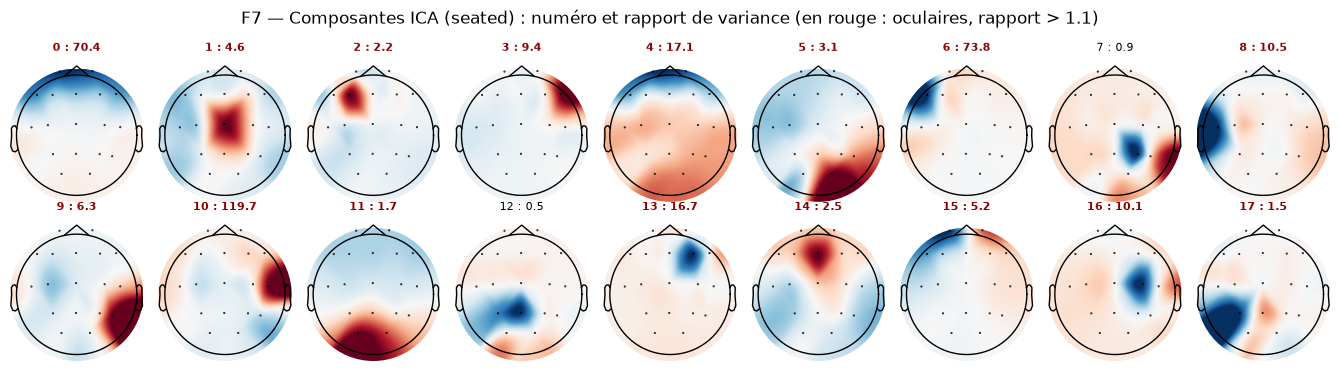

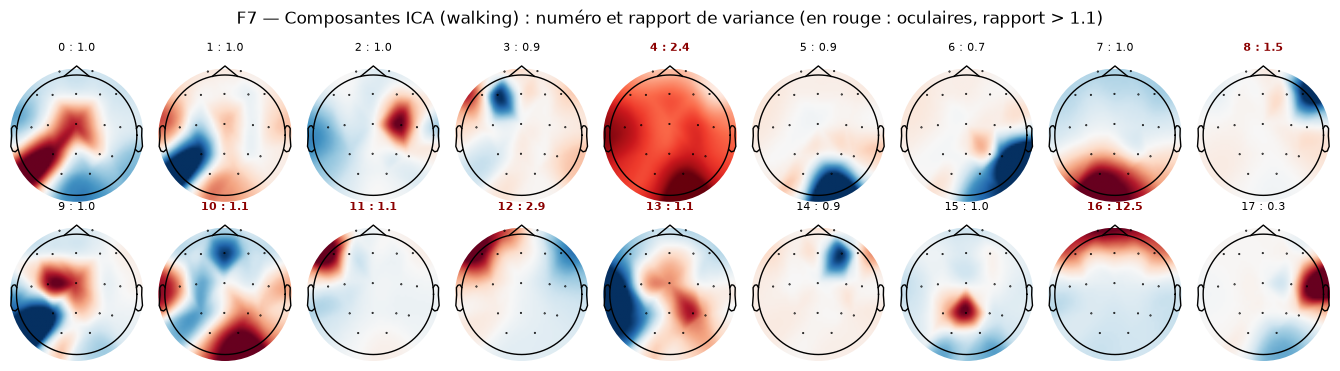

In [41]:
# ---- F7 : les cartes des composantes ------------------------------------------------------------------------------------------
info_restants = mne.create_info(noms_restants, FS, 'eeg')
info_restants.set_montage(MONTAGE)
for posture, m in modele.items():
    nc = m['A'].shape[1]
    colonnes = int(np.ceil(nc / 2))
    fig, axes = plt.subplots(2, colonnes, figsize=(1.5 * colonnes, 3.8))
    for j, ax in enumerate(axes.flat):
        if j >= nc:
            ax.axis('off')
            continue
        mne.viz.plot_topomap(m['A'][:, j], info_restants, axes=ax, show=False, contours=0)
        oculaire = j in m['oculaires']
        ax.set_title(f'{j} : {max(m["ratio_clig"][j], m["ratio_sac"][j]):.1f}', fontsize=8,
                     color='darkred' if oculaire else 'black', fontweight='bold' if oculaire else 'normal')
    fig.suptitle(f'F7 — Composantes ICA ({posture}) : numéro et rapport de variance (en rouge : oculaires, rapport > {SEUIL_RATIO})')
    plt.tight_layout()
    plt.show()

**Que regarder ? (F7)** Une composante de clignement a souvent une carte forte et symétrique à l'avant de la tête (Fp1, Fp2) ; une
composante de saccade, une carte opposée entre la gauche et la droite (F7 contre F8). Le nombre de composantes oculaires par posture est
affiché sous la cellule 7.2. Avec `SEUIL_RATIO = 1.1`, c'est souvent la majorité des composantes (chez P003, 16 sur 18 assis ; chez P002,
les 18) : le critère est très sensible. Cela ne veut pas dire que toutes ces composantes sont « des yeux » : leur variance est seulement plus grande pendant les
clignements ou les saccades qu'ailleurs. Comparez les rapports dans les titres de F7 : une composante à 1,2 et une à 5 ne sont pas dans
la même situation. L'étape 8 est moins brutale qu'enlever ces composantes, parce qu'elle n'enlève que leurs grands transitoires, mais une
sélection aussi large peut quand même retirer du signal utile.

**Bloc Type 3.** Mettez `SEUIL_RATIO = 2.0` : seules les composantes dont la variance augmente davantage pendant les yeux sont corrigées.
Comparez F8, F9 et, surtout, l'ERP final (F11b) : que gagne-t-on, que perd-on ?

### F7b — Les dimensions du signal, et le critère des composantes oculaires (Bloc Type 3)

Reconstruire une électrode à partir de ses voisines (interpolation sphérique) en fait presque un mélange des autres, et une nouvelle référence
prise sans la référence d'origine enlève une dimension : le signal a alors moins de dimensions indépendantes (son *rang*) que d'électrodes.
Une ICA qui cherche plus de composantes que ce rang peut produire des composantes « fantômes » (Kim et al., 2023). L'étape 7.2 compte les
dimensions (les valeurs propres de la covariance plus grandes qu'un millionième de la plus grande) et demande à Picard exactement autant de
composantes. F7b montre ces valeurs propres, et le rapport de chaque composante face à `SEUIL_RATIO` (en rouge : les composantes oculaires). Chez P003,
le signal garde 18 dimensions pour 18 électrodes, dans les deux postures.

In [42]:
# ---- F7b (Bloc Type 3) : les dimensions du signal, et le rapport de chaque composante ---------------------------------------------
if OPTIONNEL:
    fig, axes = plt.subplots(2, len(modele), figsize=(13, 7), layout='constrained', squeeze=False)
    for col, (posture, m) in enumerate(modele.items()):
        valeurs_triees = np.sort(m['valeurs_propres'])[::-1]                 # de la plus grande à la plus petite
        axes[0, col].semilogy(np.arange(1, len(valeurs_triees) + 1), valeurs_triees, 'o-')
        axes[0, col].axhline(valeurs_triees[0] * 1e-6, color='C3', ls='--', lw=0.8, label='le seuil de 7.2')
        axes[0, col].set_xlabel('dimension')
        axes[0, col].set_ylabel('valeur propre')
        axes[0, col].set_title(f'F7b — {posture} : {m["rang"]} dimensions pour {len(valeurs_triees)} électrodes')
        axes[0, col].legend(fontsize=8)
        ratio = np.maximum(m['ratio_clig'], m['ratio_sac'])                 # le rapport de F7
        ordre = np.argsort(ratio)[::-1]
        axes[1, col].bar(range(len(ratio)), ratio[ordre], color=['darkred' if j in m['oculaires'] else '0.6' for j in ordre])
        axes[1, col].axhline(SEUIL_RATIO, color='k', ls='--', lw=0.8, label=f'SEUIL_RATIO = {SEUIL_RATIO:g}')
        axes[1, col].set_yscale('log')
        axes[1, col].set_xticks(range(len(ratio)))
        axes[1, col].set_xticklabels(ordre, fontsize=7)
        axes[1, col].set_xlabel('composante (triées)')
        axes[1, col].set_ylabel('rapport de variance')
        axes[1, col].legend(fontsize=8)
    plt.show()
else:
    print('F7b non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.')

F7b non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.


## 8. La correction par ondelettes des composantes oculaires (wICA) (Bloc Type 1)

**Pourquoi cette étape ?** Enlever une composante entière enlèverait aussi l'activité du cerveau qu'elle contient. La **wICA** (Castellanos
et Makarov, 2006) découpe le signal de chaque composante oculaire en *ondelettes* (des petites oscillations de différentes durées), garde
seulement les coefficients très grands (les clignements et les saccades) et les soustrait. Le reste de la composante, plus faible, reste dans
l'EEG.

**Ce que fait v1.0.** Pour chaque composante oculaire : une transformée en ondelettes stationnaire (`pywt.swt`, ondelette *coif5*, 5 niveaux).
À chaque niveau, un coefficient est gardé comme artefact s'il dépasse le seuil universel √(2 ln N) × (écart robuste / 0,6745). La
reconstruction de ces seuls coefficients est l'artefact, qui est renvoyé vers les électrodes (avec les cartes `A`) et soustrait. La
correction s'applique au signal de l'étape 5 (celui à 0,1 Hz, pas la copie à 2 Hz).

La wICA réduit le risque d'enlever une composante entière. Elle ne garantit pas que les grands coefficients retirés soient tous des
artefacts : il faut donc regarder avant/après (F8).

In [43]:
# ---- 8.1 La wICA, enregistrement par enregistrement -------------------------------------------------------------------------------
ONDELETTE, NIVEAUX = 'coif5', 5    # modifiable (v1.0 : coif5, 5 niveaux)
apres_wica = {}
for nom in gardes:
    y = propre[nom][restants]                                                # l'EEG de l'étape 5
    m = modele.get(enregistrements.loc[nom, 'posture'])
    if m is None or len(m['oculaires']) == 0:
        apres_wica[nom] = y.copy()
        continue
    composantes = m['W'][m['oculaires']] @ y                                 # le signal des composantes oculaires
    n = y.shape[1]
    artefact = np.zeros_like(composantes)
    for j, comp in enumerate(composantes):
        complete = np.pad(comp, (0, (-n) % (2 ** NIVEAUX)), mode='reflect')   # la transformée veut une longueur multiple de 2^5
        coefficients = pywt.swt(complete, ONDELETTE, level=NIVEAUX, trim_approx=True)
        seuil_k = np.sqrt(2 * np.log(len(complete)))                         # le seuil universel
        grands = []
        for c in coefficients:
            sigma = np.median(np.abs(c - np.median(c))) / 0.6745             # le niveau de bruit de ce niveau d'ondelettes
            grands.append(np.where(np.abs(c) > seuil_k * sigma, c, 0.0))     # on ne garde que les grands coefficients
        artefact[j] = pywt.iswt(grands, ONDELETTE)[:n]                       # l'artefact de cette composante
    apres_wica[nom] = y - m['A'][:, m['oculaires']] @ artefact               # soustrait des électrodes
print('wICA appliquée à', len(apres_wica), 'enregistrements')

wICA appliquée à 11 enregistrements


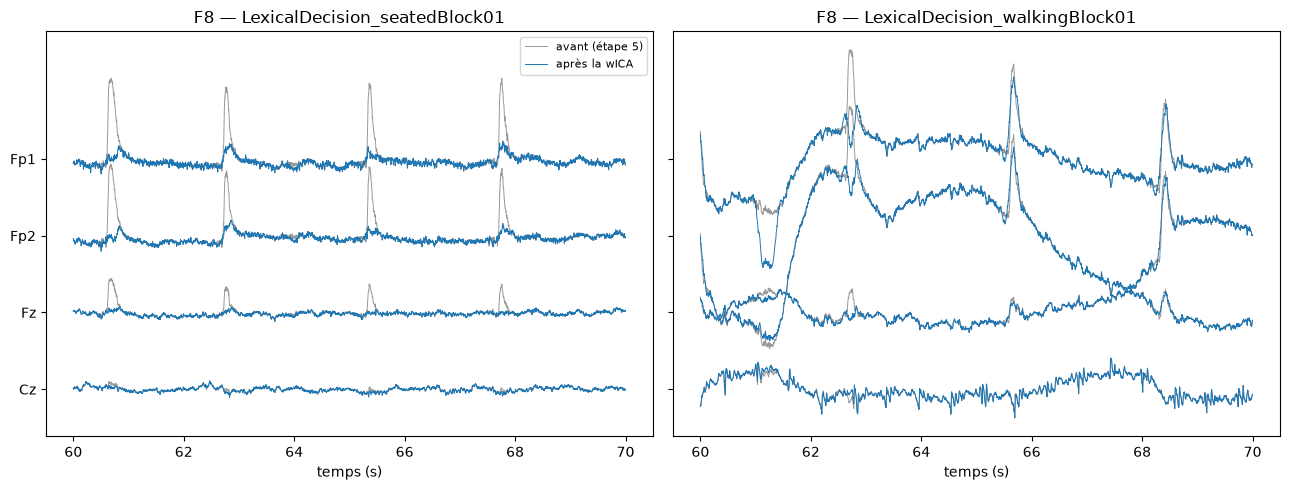

In [44]:
# ---- F8 : avant et après la wICA, 10 s de signal assis et en marche --------------------------------------------------------------
montrees = choisir_electrodes(AFFICHAGE['F8'], noms_restants, 'F8')          # les électrodes de la figure (AFFICHAGE, 0.4)
fig, axes = plt.subplots(1, 2, figsize=(13, 0.6 * len(montrees) + 2.6), sharey=True)
for ax, nom in zip(axes, [exemple_assis, exemple_marche]):
    t = fenetre_temps(nom, apres_wica[nom].shape[1], 'F8')                   # de 60 à 70 s
    for k, c in enumerate(montrees):
        j = noms_restants.index(c)
        avant = propre[nom][restants][j, t]
        ax.plot(t / FS, avant - avant.mean() - 300 * k, color='0.6', lw=0.7, label='avant (étape 5)' if k == 0 else None)
        ax.plot(t / FS, apres_wica[nom][j, t] - avant.mean() - 300 * k, color='C0', lw=0.7, label='après la wICA' if k == 0 else None)
    ax.set_title(f'F8 — {nom}')
    ax.set_xlabel('temps (s)')
axes[0].set_yticks(-300 * np.arange(len(montrees)))
axes[0].set_yticklabels(montrees)
axes[0].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

**Que regarder ? (F8)** Assis, la wICA enlève presque tout de chaque clignement à Fp1 et Fp2 ; il en reste une petite bosse. Plus loin des
yeux, il y avait moins à enlever, et le signal change peu. En marche, la wICA enlève en général beaucoup moins. Son seuil se règle sur le
bruit de fond de chaque composante. Or en marche, la composante du clignement (la carte forte et symétrique à l'avant de la tête, dans F7)
contient aussi beaucoup d'autres choses : chez P003, son rapport est de 70 assis et de 12 en marche. Une plus grande partie du clignement
reste alors sous le seuil. L'étape 9 s'occupe de ce qui reste (F9).

## 9. Le filtre des clignements (Blocs Type 1 et 2)

**Pourquoi cette étape ?** Après la wICA, il reste souvent une partie des clignements, surtout en marche. Le pipeline construit un **filtre
spatial** : la combinaison des électrodes qui fait le mieux ressortir le clignement moyen par rapport au reste de l'enregistrement (une
*décomposition propre généralisée* ; de Cheveigné et Parra, 2014). Il soustrait ce que ce filtre capte, mais **seulement pendant les
clignements** (de -0,25 à +0,35 s autour de chaque pic, avec des rampes de 50 ms). Entre les clignements, le signal n'est pas touché.

**Ce que fait v1.0**, pour chaque enregistrement qui a au moins 10 clignements utilisables :
1. il moyenne les clignements (-0,3 à +0,5 s, ligne de base -0,3 à -0,15 s) ;
2. il cherche le filtre `w` qui maximise la puissance de ce clignement moyen par rapport à la covariance de tout l'enregistrement, et son
   motif sur les électrodes ;
3. il soustrait le signal du filtre, multiplié par une fenêtre qui vaut 1 pendant chaque clignement et 0 ailleurs.

In [45]:
# ---- 9.1 Le filtre spatial des clignements ------------------------------------------------------------------------------------------
filtre_clig = {}
for nom in gardes:
    x1 = apres_wica[nom]
    M, n = x1.shape
    lo, hi = int(-0.3 * FS), int(0.5 * FS)                                   # la fenêtre autour de chaque clignement
    b0_clig, b1_clig = int(-0.3 * FS) - lo, int(-0.15 * FS) - lo             # la ligne de base
    ids = [int(round(t * FS)) for t in clignements[nom]]
    ids = [i for i in ids if i + lo >= 0 and i + hi < n and not bad[nom][i + lo:i + hi + 1].any()]
    if len(ids) < 10:
        continue                                                             # trop peu de clignements : pas de filtre
    ep = np.stack([x1[:, i + lo:i + hi + 1] for i in ids])                   # clignements x électrodes x temps
    ep = ep - ep[:, :, b0_clig:b1_clig].mean(axis=2, keepdims=True)
    moyenne = ep.mean(axis=0)                                                # le clignement moyen
    Cb = moyenne @ moyenne.T / moyenne.shape[1]                              # sa covariance
    X0 = x1[:, ~bad[nom]] - x1[:, ~bad[nom]].mean(axis=1, keepdims=True)
    C0 = X0 @ X0.T / X0.shape[1]                                             # la covariance de tout l'enregistrement
    C0 += 1e-6 * np.trace(C0) / M * np.eye(M)
    _, vecteurs = eigh(Cb, C0)                                               # la décomposition propre généralisée
    w = vecteurs[:, -1:]                                                     # le meilleur filtre
    filtre_clig[nom] = (w, C0 @ w @ np.linalg.inv(w.T @ C0 @ w))             # le filtre et son motif sur les électrodes
print(f'filtre des clignements dans {len(filtre_clig)} enregistrements sur {len(gardes)}')

filtre des clignements dans 11 enregistrements sur 11


In [46]:
# ---- 9.2 Soustraire le clignement, seulement pendant les clignements ---------------------------------------------------------------
FENETRE_FILTRE_S = (-0.25, 0.35)   # modifiable (v1.0 : -0,25 à +0,35 s autour du pic)
RAMPE_S = 0.05                     # modifiable (v1.0 : 0,05 s) : la montée et la descente de la fenêtre
nettoye = {}
for nom in gardes:
    x1 = apres_wica[nom]
    if nom not in filtre_clig:
        nettoye[nom] = x1.copy()
        continue
    w, motif = filtre_clig[nom]
    n = x1.shape[1]
    r = int(RAMPE_S * FS)
    rampe = 0.5 - 0.5 * np.cos(np.linspace(0, np.pi, r)) if r > 0 else np.array([])   # une montée en douceur de 0 à 1
    fenetre = np.zeros(n)                                                    # 1 pendant les clignements, 0 ailleurs
    for t in clignements[nom]:
        i = int(round(t * FS))
        a, b = i + int(FENETRE_FILTRE_S[0] * FS), i + int(FENETRE_FILTRE_S[1] * FS)
        morceau = np.concatenate([rampe, np.ones(max(b - a, 0)), rampe[::-1]])
        s0 = a - r
        lo, hi = max(s0, 0), min(s0 + len(morceau), n)
        if hi > lo:
            fenetre[lo:hi] = np.maximum(fenetre[lo:hi], morceau[lo - s0:hi - s0])
    nettoye[nom] = x1 - (motif @ (w.T @ x1)) * fenetre[None, :]

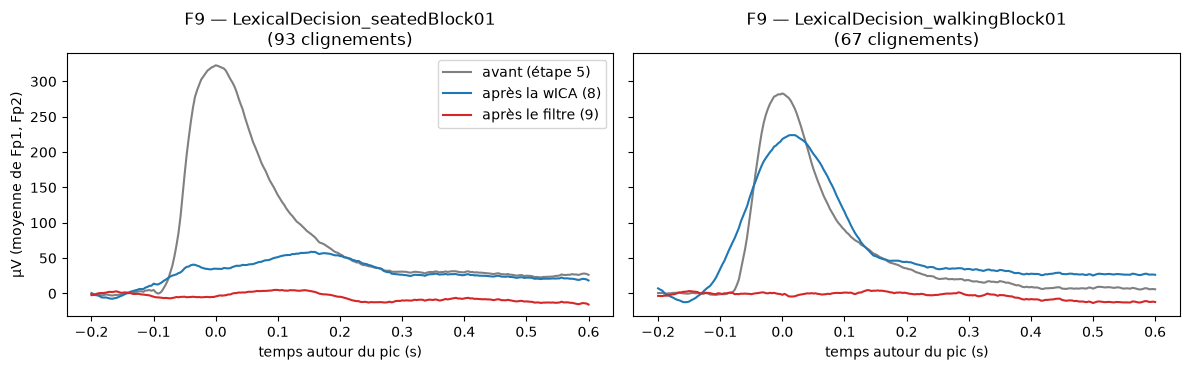

In [47]:
# ---- F9 : le clignement moyen à Fp1 et Fp2, à chaque étape -----------------------------------------------------------------------
montrees = choisir_electrodes(AFFICHAGE['F9'], noms_restants, 'F9')          # les électrodes de la figure (AFFICHAGE, 0.4) : leur moyenne
lignes_f9 = [noms_restants.index(c) for c in montrees]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, nom in zip(axes, [exemple_assis, exemple_marche]):
    ids = [int(round(t * FS)) for t in clignements[nom]]
    ids = [i for i in ids if i - 60 >= 0 and i + 180 < len(bad[nom]) and not bad[nom][i - 60:i + 181].any()]
    temps = np.arange(-60, 181) / FS
    ax.set_title(f'F9 — {nom}\n({len(ids)} clignements)')
    ax.set_xlabel('temps autour du pic (s)')
    if not ids:
        continue                                                             # aucun clignement utilisable dans cet enregistrement
    for signal, etiquette, couleur in ((propre, 'avant (étape 5)', '0.5'), (apres_wica, 'après la wICA (8)', 'C0'), (nettoye, 'après le filtre (9)', 'C3')):
        x = signal[nom][restants] if signal is propre else signal[nom]
        moyenne = np.mean([x[lignes_f9, i - 60:i + 181].mean(axis=0) - x[lignes_f9, i - 60:i - 30].mean() for i in ids], axis=0)
        ax.plot(temps, moyenne, color=couleur, label=etiquette)
axes[0].set_ylabel(f'µV ({nom_choix(montrees)})')
axes[0].legend()
plt.tight_layout()
plt.show()

**Que regarder ? (F9)** Avant la correction (gris), le clignement moyen dépasse 100 µV au-dessus des yeux (plus de 300 µV assis chez
P003). Après la wICA (bleu), il
en reste une partie ; après le filtre (rouge), presque plus rien. En marche, la part laissée par la wICA est plus grande : c'est là que le
filtre sert le plus.

**Bloc Type 2.** Mettez `FENETRE_FILTRE_S = (-0.1, 0.1)`. Le filtre agit sur une fenêtre trop courte : que voyez-vous dans F9 ?

In [48]:
# ---- F9b (Bloc Type 3) : ce que soustrait le filtre des clignements, dans le temps -----------------------------------------------
if OPTIONNEL:
    montrees = choisir_electrodes(AFFICHAGE['F9'], noms_restants, 'F9b')     # les électrodes de F9 (AFFICHAGE, 0.4) : leur moyenne
    lignes_f9 = [noms_restants.index(c) for c in montrees]
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.4), sharey=True, layout='constrained')
    for ax, nom in zip(axes, [exemple_assis, exemple_marche]):
        retire = (apres_wica[nom] - nettoye[nom])[lignes_f9].mean(axis=0)    # ce que l'étape 9 a soustrait (µV)
        t = fenetre_temps(nom, len(retire), 'F8')                            # les 10 s de F8
        ax.plot(t / FS, retire[t], lw=0.8, color='C3')
        ax.axhline(0, color='0.7', lw=0.8)
        ax.set_xlabel('temps (s)')
        ax.set_title(f'F9b — Soustrait par le filtre des clignements ({nom})')
    axes[0].set_ylabel(f'µV ({nom_choix(montrees)})')
    plt.show()
else:
    print('F9b non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.')

F9b non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.


In [49]:
# ---- F9c (Bloc Type 3) : où le filtre des clignements agit sur la tête ---------------------------------------------------------
if OPTIONNEL:
    info_9c = mne.create_info(noms_restants, FS, 'eeg')                      # les électrodes restantes, avec leurs positions
    info_9c.set_montage(MONTAGE)
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.6), layout='constrained')
    for ax, nom in zip(axes, [exemple_assis, exemple_marche]):
        retire = apres_wica[nom] - nettoye[nom]                              # ce que l'étape 9 a soustrait (µV)
        c0 = int(round(0.05 * FS))                                           # 50 ms de chaque côté du pic du clignement
        ids = [int(round(t * FS)) for t in clignements[nom]]
        ids = [i for i in ids if i - c0 >= 0 and i + c0 < retire.shape[1] and not bad[nom][i - c0:i + c0 + 1].any()]
        if not ids:
            ax.text(0.5, 0.5, 'aucun clignement utilisable', transform=ax.transAxes, ha='center')
            ax.set_axis_off()
            continue
        amplitude = np.mean([retire[:, i - c0:i + c0 + 1].mean(axis=1) for i in ids], axis=0)   # électrode par électrode
        lim = np.abs(amplitude).max()
        image, _ = mne.viz.plot_topomap(amplitude, info_9c, axes=ax, show=False, contours=0, cmap='RdBu_r', vlim=(-lim, lim))
        fig.colorbar(image, ax=ax, shrink=0.7, label='µV')
        ax.set_title(f'F9c — {nom}\n({len(ids)} clignements)', fontsize=9)
    plt.show()
else:
    print('F9c non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.')

F9c non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.


## 10. Le signal final (Bloc Type 1)

**Ce que fait v1.0**, pour chaque enregistrement :
1. il reconstruit les électrodes laissées de côté partout (P7 chez tous les participants) par interpolation, à partir des autres ;
2. il refait la référence moyenne sans bouffées, cette fois sur les 19 électrodes (le même calcul qu'à l'étape 4) ;
3. il applique un **filtre passe-bas à 30 Hz** (un filtre FIR à phase nulle de MNE). Les ERP étudiés ici sont surtout sous 30 Hz. Le filtre enlève ce
   qui est plus rapide, dont une partie de l'activité des muscles, sans garantir qu'il n'en reste pas sous 30 Hz.

In [50]:
# ---- 10.1 Reconstruire les électrodes laissées de côté partout ---------------------------------------------------------------------
complet = {}
for nom in gardes:
    n = nettoye[nom].shape[1]
    complet[nom] = np.zeros((N_CANAUX, n))
    complet[nom][restants] = nettoye[nom]                                    # les électrodes restantes, corrigées
    if systematiques.any():
        cibles = [c for c, s in zip(CANAUX, systematiques) if s]
        info = mne.create_info(noms_restants + cibles, FS, 'eeg')
        info.set_montage(MONTAGE)
        tmp = mne.io.RawArray(np.vstack([nettoye[nom], np.zeros((len(cibles), n))]) * 1e-6, info)
        tmp.info['bads'] = cibles
        tmp.interpolate_bads(reset_bads=True, method=dict(eeg='spline'), origin=(0.0, 0.0, 0.04))   # à partir des 18 autres
        complet[nom][systematiques] = tmp.get_data(picks=cibles) * 1e6

In [51]:
# ---- 10.2 La référence moyenne sans bouffées, sur les 19 électrodes (le calcul de 4.1) ----------------------------------------------
fen_bouffee, pas_bouffee = max(int(round(FENETRE_BOUFFEE_S * FS)), 2), max(int(round(FENETRE_BOUFFEE_S * FS / 2)), 1)   # les fenêtres de 4.1
for nom in gardes:
    x, n = complet[nom], complet[nom].shape[1]
    xb = np.zeros((N_CANAUX, n))
    for a, b in segments[nom]:
        if b - a >= int(2 * FS):
            xb[:, a:b] = sosfiltfilt(sos_bouffee, x[:, a:b], axis=1, padtype='odd', padlen=None)
    ecart = xb - np.median(xb, axis=0, keepdims=True)
    debuts = np.arange(0, max(n - fen_bouffee, 0) + 1, pas_bouffee)
    rms = np.stack([np.sqrt((ecart[:, s:s + fen_bouffee] ** 2).mean(axis=1)) for s in debuts], axis=1)
    bouffee = rms > SEUIL_BOUFFEE * np.maximum(np.median(rms, axis=1, keepdims=True), 1e-6)
    poids, compte = np.zeros((N_CANAUX, n)), np.zeros(n)
    for j, s in enumerate(debuts):
        poids[:, s:s + fen_bouffee] += (~bouffee[:, j])[:, None]
        compte[s:s + fen_bouffee] += 1
    poids = poids / np.maximum(compte, 1)[None, :]
    poids[:, compte == 0] = 1.0
    total = poids.sum(axis=0)
    complet[nom] = x - np.where(total > 0.5, (poids * x).sum(axis=0) / np.maximum(total, 1e-9), x.mean(axis=0))[None, :]

In [52]:
# ---- 10.3 Le filtre passe-bas à 30 Hz ---------------------------------------------------------------------------------------------
PASSE_BAS_HZ = 30.0          # modifiable (v1.0 : 30 Hz)
if not 0 < PASSE_BAS_HZ < FS / 2:
    raise ValueError(f'PASSE_BAS_HZ = {PASSE_BAS_HZ} : il faut 0 < PASSE_BAS_HZ < {FS / 2:g} Hz')
final = {}
for nom in gardes:
    final[nom] = np.zeros_like(complet[nom])
    for a, b in segments[nom]:                                               # morceau par morceau
        if b - a >= int(round(SEGMENT_MIN_S * FS)):
            final[nom][:, a:b] = mne.filter.filter_data(complet[nom][:, a:b], FS, None, PASSE_BAS_HZ, method='fir', phase='zero',
                                                        fir_design='firwin')
final_etape10 = {nom: x.copy() for nom, x in final.items()}                  # une copie pour la section 14 (l'étape 11.4 modifie final)
print('signal final prêt pour', len(final), 'enregistrements')

signal final prêt pour 11 enregistrements


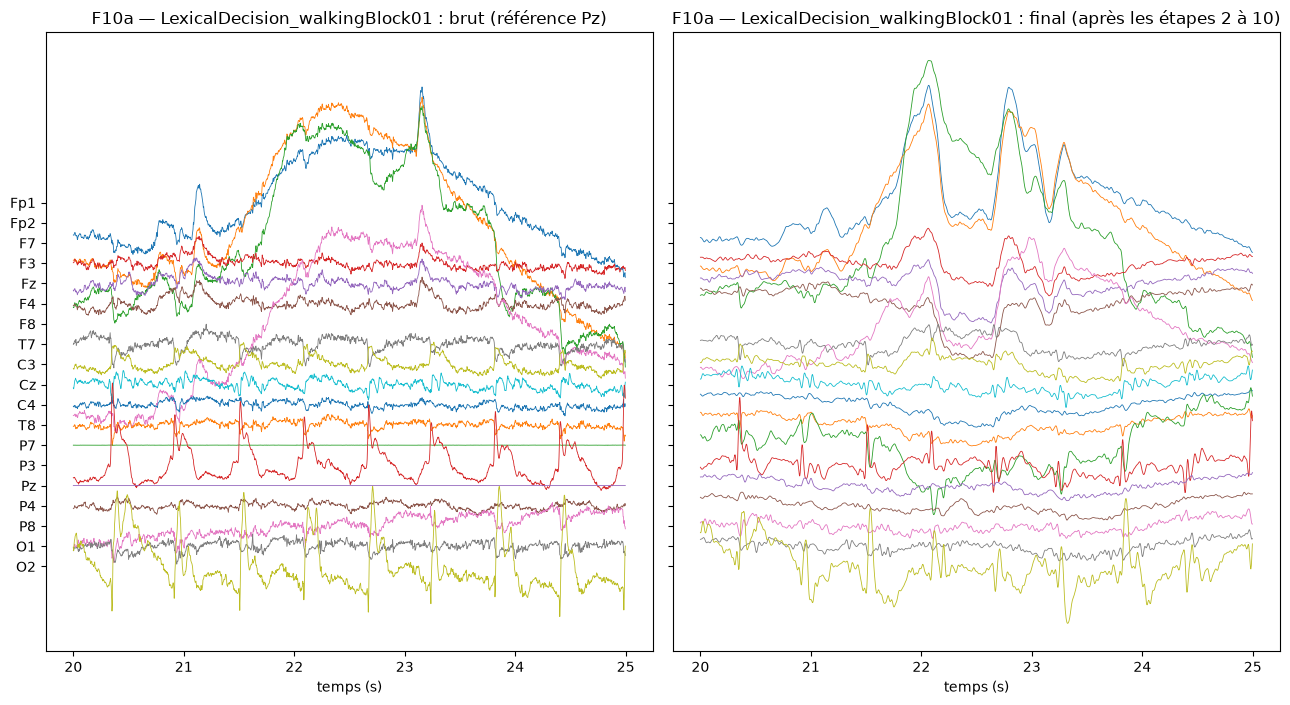

In [53]:
# ---- F10a : le même passage en marche, brut et final -----------------------------------------------------------------------------
montrees = choisir_electrodes(AFFICHAGE['F10'], CANAUX, 'F10a')              # les électrodes de la figure (AFFICHAGE, 0.4)
fig, axes = plt.subplots(1, 2, figsize=(13, 0.35 * len(montrees) + 0.5), sharey=True)
t = fenetre_temps(exemple_marche, brut[exemple_marche].shape[1], 'F10')      # de 20 à 25 s
for ax, (signal, titre) in zip(axes, [(brut, 'brut (référence Pz)'), (final_etape10, 'final (après les étapes 2 à 10)')]):
    for k, c in enumerate(montrees):
        i = CANAUX.index(c)
        ax.plot(t / FS, signal[exemple_marche][i, t] - signal[exemple_marche][i, t].mean() - 100 * k, lw=0.6)
    ax.set_title(f'F10a — {exemple_marche} : {titre}')
    ax.set_xlabel('temps (s)')
axes[0].set_yticks(-100 * np.arange(len(montrees)))
axes[0].set_yticklabels(montrees)
plt.tight_layout()
plt.show()

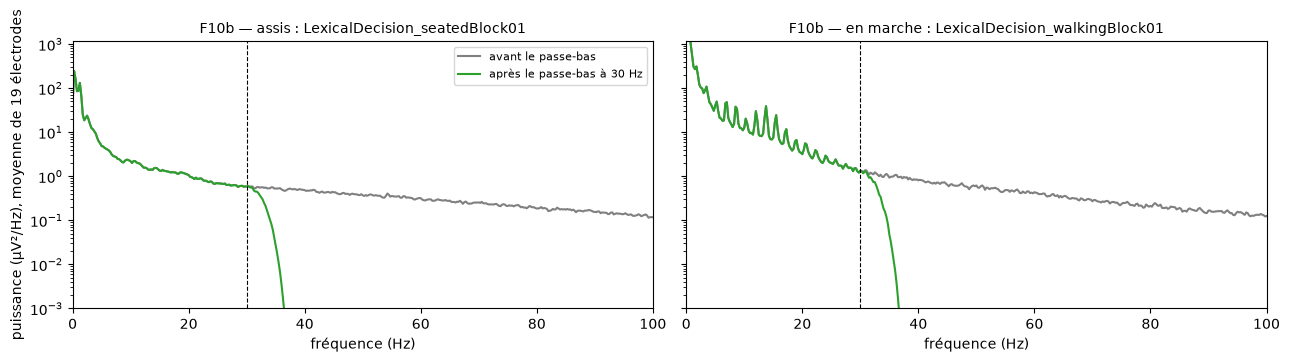

In [54]:
# ---- F10b : le spectre avant et après le passe-bas -------------------------------------------------------------------------------
montrees = choisir_electrodes(AFFICHAGE['F10'], CANAUX, 'F10b')              # les électrodes de la figure (AFFICHAGE, 0.4) : leur spectre moyen
lignes_f10 = [CANAUX.index(c) for c in montrees]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, nom, posture in zip(axes, [exemple_assis, exemple_marche], ['assis', 'en marche']):
    ok = ~bad[nom]                                                           # les échantillons utilisables
    f_avant, p_avant = welch(complet[nom][lignes_f10][:, ok], fs=FS, nperseg=int(4 * FS))   # spectre, fenêtres de 4 s
    f_apres, p_apres = welch(final_etape10[nom][lignes_f10][:, ok], fs=FS, nperseg=int(4 * FS))
    ax.semilogy(f_avant, p_avant.mean(axis=0), color='0.5', label='avant le passe-bas')
    ax.semilogy(f_apres, p_apres.mean(axis=0), color='C2', label=f'après le passe-bas à {PASSE_BAS_HZ:g} Hz')
    ax.axvline(PASSE_BAS_HZ, color='k', ls='--', lw=0.8)                     # la fréquence de coupure
    ax.set_xlim(0, 100)
    ax.set_ylim(1e-3, None)
    ax.set_title(f'F10b — {posture} : {nom}', fontsize=10)
    ax.set_xlabel('fréquence (Hz)')
axes[0].set_ylabel(f'puissance (µV²/Hz), {nom_choix(montrees)}')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Que regarder ? (F10a)** P7, plate à gauche (une électrode morte), est reconstruite à droite. Le signal est plus
lisse : tout ce qui est plus rapide que 30 Hz a disparu. Les grandes ondes lentes et une partie des pics des pas restent : c'est ce que les
époques trop grandes rejettent à l'étape 11 (le tableau de 11.6 compte les époques rejetées pour `amplitude`).

**Que regarder ? (F10b)** Sous 30 Hz, les deux spectres se confondent : le passe-bas ne touche pas aux fréquences des ERP. Au-dessus, la
puissance s'effondre. Il n'y a pas de pic à 60 Hz : le courant du secteur ne gênait pas ces enregistrements. En marche, des pics des pas
restent visibles jusque vers 25 Hz : la régression ne les prédit pas au-delà de 12 Hz (F5), et le passe-bas ne commence qu'à 30 Hz.

### Regarder n'importe quel signal (Bloc Type 2)

Chaque figure des étapes 1 à 10 répond à une question, aux électrodes et dans les fenêtres choisies en 0.4. La fonction `montrer_signal` de
la cellule suivante montre n'importe quel signal du code (le tableau « Les signaux du code », en haut du notebook), pour un enregistrement,
des électrodes et une fenêtre de temps de votre choix. Par exemple, `montrer_signal('hp', exemple_assis, 'toutes', 100, 10)` montre 10 s du
premier bloc assis après le filtre passe-haut. Une électrode laissée de côté à l'étape 2 n'est pas dans `apres_wica` ni dans `nettoye` : la
fonction le dit au lieu d'en montrer une autre.

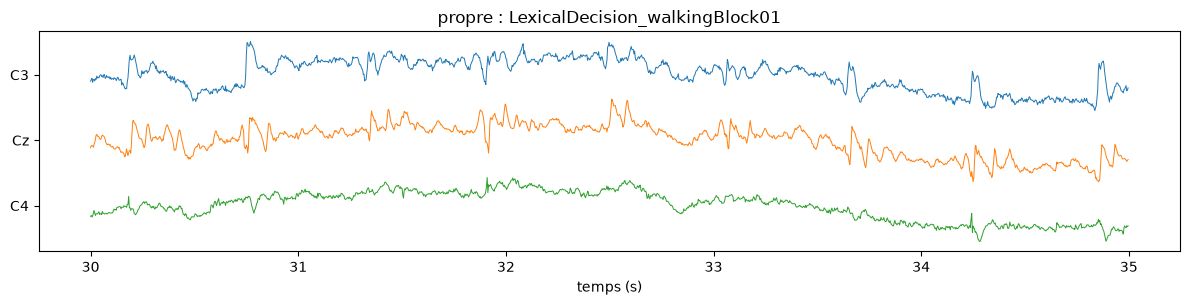

In [55]:
# ---- Regarder n'importe quel signal : montrer_signal(signal, enregistrement, électrodes, début (s), durée (s)) -----------------------
SIGNAUX = {'brut': (brut, CANAUX), 'hp': (hp, CANAUX), 'base': (base, CANAUX), 'propre': (propre, CANAUX),
           'apres_wica': (apres_wica, noms_restants), 'nettoye': (nettoye, noms_restants), 'complet': (complet, CANAUX),
           'final_etape10': (final_etape10, CANAUX)}                         # le nom de chaque signal, et ses électrodes


def montrer_signal(etape, enregistrement, electrodes, debut_s, duree_s):
    """Trace un signal du code (un nom de SIGNAUX), pour un enregistrement, une électrode ou une liste, et une fenêtre de temps (s)."""
    if etape not in SIGNAUX:
        raise ValueError(f'{etape!r} n\'est pas un signal du code. Choisissez parmi : {", ".join(SIGNAUX)}')
    signal, noms = SIGNAUX[etape]
    if enregistrement not in signal:
        raise ValueError(f'{enregistrement!r} n\'est pas disponible. Choisissez parmi : {", ".join(signal)}')
    montrees_x = choisir_electrodes(electrodes, noms, etape)                 # 'toutes', une électrode ou une liste
    a, b = int(round(debut_s * FS)), min(int(round((debut_s + duree_s) * FS)), signal[enregistrement].shape[1])
    if not 0 <= a < b:
        raise ValueError(f'La fenêtre de {debut_s} à {debut_s + duree_s} s n\'est pas dans {enregistrement}.')
    t = np.arange(a, b)
    fig, ax = plt.subplots(figsize=(12, 0.45 * len(montrees_x) + 1.8))
    for k, c in enumerate(montrees_x):
        trace = signal[enregistrement][list(noms).index(c), t]
        ax.plot(t / FS, trace - trace.mean() - 150 * k, lw=0.7)             # chaque électrode décalée de 150 µV
    ax.set_yticks(-150 * np.arange(len(montrees_x)))
    ax.set_yticklabels(montrees_x)
    ax.set_xlabel('temps (s)')
    ax.set_title(f'{etape} : {enregistrement}')
    plt.tight_layout()
    plt.show()


montrer_signal('propre', exemple_marche, ['C3', 'Cz', 'C4'], 30, 5)          # un exemple : changez le signal, les électrodes ou la fenêtre

## 11. Les époques (Blocs Type 1 et 2)

**Pourquoi cette étape ?** Un ERP est la moyenne du signal autour de nombreux essais. On découpe donc, autour de l'apparition de chaque mot,
une **époque** de -0,5 à +1,5 s. On soustrait ensuite à chaque électrode la moyenne de -0,2 à 0 s, la **ligne de base** : dans chaque
époque, la moyenne avant le mot devient 0 µV, pour que toutes partent de 0.

**Ce que fait v1.0.**
1. **Les essais.** Le comportement de chaque essai vient du fichier `beh` : réponse correcte ou non, temps de réaction (TR). Un essai sert aux
   ERP si la réponse est correcte, si le TR fait au moins 250 ms et s'il n'est pas aberrant (à plus de 3 écarts-types de la moyenne du
   participant dans cette posture, sur l'échelle logarithmique) : c'est `rt_ok`.
2. **Le découpage.** Une époque est inutilisable si elle sort de l'enregistrement (`outside`), contient une coupure (`dropout`) ou touche un
   moment BAD entre -0,2 et +1,0 s (`bad_span`).
3. **Les électrodes trop souvent au-dessus de 100 µV.** Une électrode qui dépasse ±100 µV entre -0,2 et +1,0 s dans au moins la moitié des
   époques d'une posture est reconstruite dans tous les enregistrements, et le découpage est refait. Si cela laissait moins de 9 vraies
   électrodes, la posture serait mise de côté.
4. **La réparation, époque par époque.** Dans une époque, jusqu'à 3 électrodes au-dessus de ±100 µV sont reconstruites à partir des autres ;
   avec plus de 3, l'époque est rejetée (`amplitude`).

> **La ligne de base est un choix.** Soustraire la moyenne de -200 à 0 ms suppose que cette période est comparable d'une condition à
> l'autre. Si assis et en marche diffèrent déjà avant le mot, la soustraction peut transformer cette différence en différence apparente
> après le mot (la section 15 essaie une autre façon de faire). Ici, on reproduit v1.0. Dans une analyse ERP, on justifie la fenêtre de base et
> on vérifie que les résultats tiennent avec une autre. Les études d'ERP en EEG mobile font la même correction locale : Ladouce et al. (2019)
> et De Sanctis et al. (2026), par exemple, soustraient la moyenne de -200 à 0 ms. Cela ne rend pas les lignes de base assise et en marche
> équivalentes.

In [56]:
# ---- 11.1 Le comportement de chaque essai --------------------------------------------------------------------------------------------
MIN_TR_S = 0.25              # modifiable (v1.0 : 0,25 s) : une réponse plus rapide n'est pas une décision
SEUIL_ABERRANT = 3.0         # modifiable (v1.0 : 3) : écarts-types du log(TR) au-delà desquels un TR est aberrant
morceaux = []
for posture in ('seated', 'walking'):
    fichier = SEANCE / 'beh' / f'sub-{PARTICIPANT}_ses-001_task-LexicalDecision_acq-{posture}_run-01_beh.tsv'
    if fichier.exists():
        d = pd.read_csv(fichier, sep='\t', na_values='n/a')
        morceaux.append(d[d['row_type'] == 'experimental_trial'].assign(posture=posture))   # sans les essais d'entraînement
comportement = pd.concat(morceaux, ignore_index=True)
comportement['trial'] = comportement['trial'].astype(int)
comportement['analyse'] = (comportement['omission'] != 1) & ~(comportement['response_time'] < MIN_TR_S)   # ni omission ni trop rapide
comportement['correct'] = comportement['analyse'] & (comportement['accuracy'] == 1)
comportement['logtr'] = np.log(comportement['response_time'])
corrects = comportement[comportement['correct']]
z = (corrects['logtr'] - corrects.groupby('posture')['logtr'].transform('mean')) / corrects.groupby('posture')['logtr'].transform('std')
comportement['aberrant'] = False
comportement.loc[corrects.index, 'aberrant'] = z.abs() > SEUIL_ABERRANT
comportement['rt_ok'] = comportement['correct'] & ~comportement['aberrant']
comportement['type'] = np.select([comportement['lexicality'] == 'pseudoword', comportement['frequency_class'] == 'high'], ['pseudo', 'HF'], 'LF')
essais = {}                                                                  # les essais de chaque bloc, dans l'ordre
for nom in gardes:
    if enregistrements.loc[nom, 'tache'] != 'LexicalDecision':
        continue
    ev = evenements[nom]
    stim = ev[ev['trial_type'] == 'stimulus'][['onset', 'sample', 'trial']].copy()   # l'apparition de chaque mot
    stim['posture'] = enregistrements.loc[nom, 'posture']
    essais[nom] = stim.merge(comportement[['posture', 'trial', 'block', 'stimulus', 'type', 'response_time', 'rt_ok']],
                             on=['posture', 'trial'], how='left').reset_index(drop=True)
comportement.groupby('posture')[['correct', 'rt_ok']].mean().round(3)

,correct,rt_ok
posture,,
seated,0.912,0.902
walking,0.905,0.892


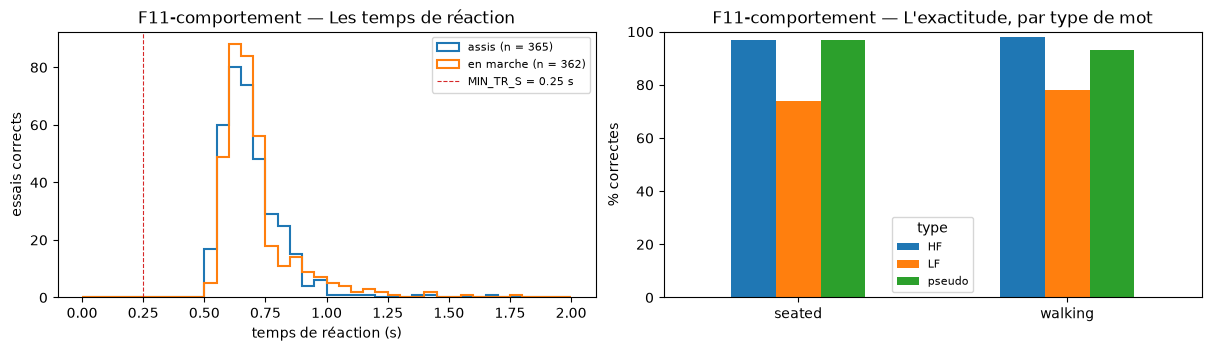

In [57]:
# ---- F11-comportement : les temps de réaction et l'exactitude, assis et en marche -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), layout='constrained')
for posture, etiquette, couleur in (('seated', 'assis', 'C0'), ('walking', 'en marche', 'C1')):
    tr = comportement.loc[(comportement['posture'] == posture) & comportement['correct'], 'response_time']   # les réponses correctes (s)
    axes[0].hist(tr, bins=np.arange(0, 2.01, 0.05), histtype='step', lw=1.5, color=couleur, label=f'{etiquette} (n = {len(tr)})')
axes[0].axvline(MIN_TR_S, color='C3', ls='--', lw=0.8, label=f'MIN_TR_S = {MIN_TR_S:g} s')
axes[0].set_xlabel('temps de réaction (s)')
axes[0].set_ylabel('essais corrects')
axes[0].set_title('F11-comportement — Les temps de réaction')
axes[0].legend(fontsize=8)
exactitude = 100 * comportement.groupby(['posture', 'type'])['correct'].mean().unstack('type')   # % de réponses correctes
exactitude.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_ylim(0, 100)
axes[1].set_xlabel('')
axes[1].set_ylabel('% correctes')
axes[1].set_title("F11-comportement — L'exactitude, par type de mot")
axes[1].legend(title='type', fontsize=8)
plt.show()

**Que regarder ? (F11-comportement)** Chez P003, les temps de réaction ont presque la même distribution assis et en marche (médiane de 664 et
672 ms pour les réponses correctes). L'exactitude est haute pour les mots fréquents et les pseudo-mots (93 à 98 %), plus basse pour les mots
rares (74 % assis, 78 % en marche) : un mot rare est plus souvent pris pour un pseudo-mot. Seules les réponses correctes entrent dans les ERP
(`rt_ok`).

In [58]:
# ---- 11.2 Découper les époques (premier passage) ---------------------------------------------------------------------------------
TMIN, TMAX = -0.5, 1.5       # modifiable (v1.0 : -0,5 à 1,5 s)
LIGNE_BASE = (-0.2, 0.0)     # modifiable (v1.0 : -0,2 à 0 s)
FENETRE_REJET = (-0.2, 1.0)  # modifiable (v1.0 : -0,2 à 1,0 s)
SEUIL_REJET_UV = 100.0       # modifiable (v1.0 : 100 µV)
verifier_fenetre('TMIN, TMAX', (TMIN, TMAX))                                 # arrête si une fenêtre est impossible (0.4)
verifier_fenetre('LIGNE_BASE', LIGNE_BASE, (TMIN, TMAX))
verifier_fenetre('FENETRE_REJET', FENETRE_REJET, (TMIN, TMAX))
t0, t1 = int(round(TMIN * FS)), int(round(TMAX * FS))                        # en échantillons
b0, b1 = int(round(LIGNE_BASE[0] * FS)), int(round(LIGNE_BASE[1] * FS))
r0, r1 = int(round(FENETRE_REJET[0] * FS)), int(round(FENETRE_REJET[1] * FS))
reelles_etape10 = {nom: np.array([(c not in raisons[nom]) and restants[i] for i, c in enumerate(CANAUX)]) for nom in gardes}   # électrodes vraiment mesurées
pics_1, raison_1 = {}, {}                                                    # le premier passage (11.5 fait le deuxième)
for nom in essais:
    n = final_etape10[nom].shape[1]
    pics_1[nom] = np.full((len(essais[nom]), N_CANAUX), np.nan)              # le plus grand écart à 0 de chaque électrode, par époque
    raison_1[nom] = []
    for k, s in enumerate(essais[nom]['sample'].to_numpy(int)):
        a, b = s + t0, s + t1 + 1
        if a < 0 or b > n:
            raison_1[nom].append('outside')
            continue
        epoque = final_etape10[nom][:, a:b] - final_etape10[nom][:, s + b0:s + b1].mean(axis=1, keepdims=True)   # le signal de l'étape 10, ligne de base retirée
        if len(coupures[nom]) and np.any((coupures[nom] > a) & (coupures[nom] < b)):
            raison_1[nom].append('dropout')
            continue
        if bad[nom][s + r0:s + r1 + 1].any():
            raison_1[nom].append('bad_span')
            continue
        pics_1[nom][k] = np.abs(epoque[:, (r0 - t0):(r1 - t0 + 1)]).max(axis=1)
        pics_1[nom][k, ~reelles_etape10[nom]] = np.nan                       # les électrodes reconstruites ne comptent pas
        raison_1[nom].append('en attente')

In [59]:
# ---- 11.3 Les électrodes trop souvent au-dessus de 100 µV ------------------------------------------------------------------------
PART_EPOQUES = 0.5           # modifiable (v1.0 : 0.5) : part des époques d'une posture
MIN_ELECTRODES = 9           # modifiable (v1.0 : 9) : vraies électrodes nécessaires pour garder une posture
ensembles = {}
for posture in ('seated', 'walking'):
    p = [pics_1[nom][np.array(raison_1[nom]) == 'en attente'] for nom in essais if enregistrements.loc[nom, 'posture'] == posture]
    p = np.concatenate(p) if p else np.zeros((0, N_CANAUX))
    if p.shape[0] < 20:
        continue                                                             # trop peu d'époques pour juger
    valides = np.isfinite(p)
    n_valides = valides.sum(axis=0)
    au_dessus = ((p > SEUIL_REJET_UV) & valides).sum(axis=0)
    ensembles[posture] = np.where(n_valides >= 20, au_dessus / np.maximum(n_valides, 1), 0.0) >= PART_EPOQUES
n_vraies = {posture: int((restants & ~s).sum()) for posture, s in ensembles.items()}
postures_gardees = [posture for posture in ensembles if n_vraies[posture] >= MIN_ELECTRODES]
mises_de_cote = [posture for posture in ensembles if posture not in postures_gardees]
while len(postures_gardees) > 1 and int((restants & ~np.any([ensembles[p] for p in postures_gardees], axis=0)).sum()) < MIN_ELECTRODES:
    pire = postures_gardees[int(np.argmax([ensembles[p].sum() for p in postures_gardees]))]   # la posture qui en demande le plus
    postures_gardees.remove(pire)
    mises_de_cote.append(pire)
a_reconstruire = np.any([ensembles[p] for p in postures_gardees], axis=0) if postures_gardees else np.zeros(N_CANAUX, bool)
print('Reconstruites dans toutes les époques :', [c for c, s in zip(CANAUX, a_reconstruire) if s] or 'aucune')
print('Postures mises de côté :', mises_de_cote or 'aucune')

Reconstruites dans toutes les époques : ['Fp2', 'F7', 'F8', 'P3', 'O2']
Postures mises de côté : aucune


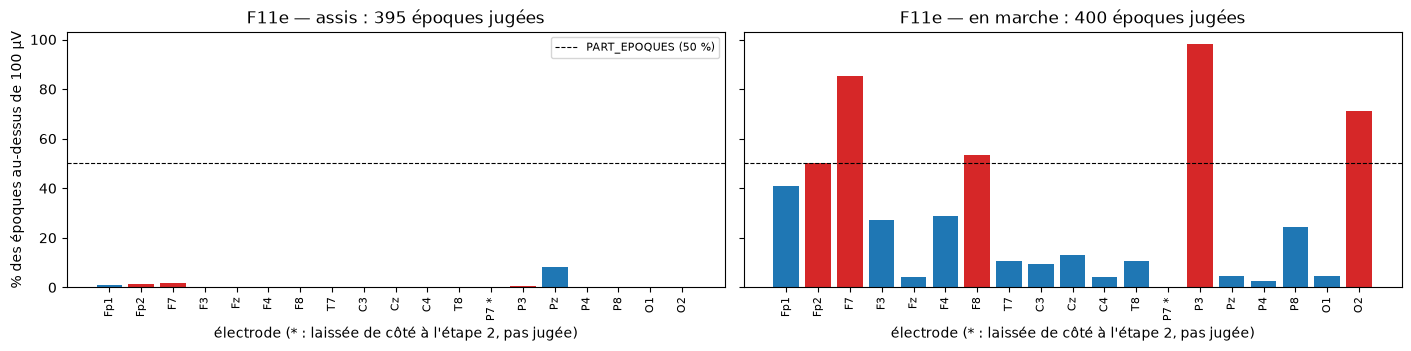

In [60]:
# ---- F11e : combien de fois chaque électrode dépasse 100 µV dans les époques de 11.2 (ce que juge 11.3) ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 3.4), sharey=True, layout='constrained')
for ax, posture, etiquette in zip(axes, ('seated', 'walking'), ('assis', 'en marche')):
    p = [pics_1[nom][np.array(raison_1[nom]) == 'en attente'] for nom in essais if enregistrements.loc[nom, 'posture'] == posture]
    p = np.concatenate(p) if p else np.zeros((0, N_CANAUX))
    valides = np.isfinite(p)                                                 # les électrodes mesurées de chaque époque
    pourcent = 100 * ((p > SEUIL_REJET_UV) & valides).sum(axis=0) / np.maximum(valides.sum(axis=0), 1)   # % des époques
    ax.bar(range(N_CANAUX), pourcent, color=['C3' if s else 'C0' for s in a_reconstruire])   # en rouge : reconstruites dans toutes les époques
    ax.axhline(100 * PART_EPOQUES, color='k', ls='--', lw=0.8, label=f'PART_EPOQUES ({100 * PART_EPOQUES:g} %)')
    ax.set_xticks(range(N_CANAUX))
    ax.set_xticklabels([c + (' *' if s else '') for c, s in zip(CANAUX, systematiques)], fontsize=8, rotation=90)
    ax.set_xlabel('électrode (* : laissée de côté à l\'étape 2, pas jugée)')
    ax.set_title(f'F11e — {etiquette} : {len(p)} époques jugées' + (' (posture mise de côté)' if posture in mises_de_cote else ''))
axes[0].set_ylabel(f'% des époques au-dessus de {SEUIL_REJET_UV:g} µV')
axes[0].legend(fontsize=8)
plt.show()

**Que regarder ? (F11e)** Chaque barre est la part des époques de 11.2 où l'électrode dépasse 100 µV ; le pointillé est `PART_EPOQUES`.
Une électrode au-dessus dans une posture est reconstruite dans toutes les époques, dans les deux postures (en rouge). Chez P003, aucune
électrode ne dépasse 100 µV dans le cinquième des époques assises. En marche, P3 le fait dans 98 % d'entre elles, F7 dans 85 %, O2 dans
71 %, F8 dans 54 % et Fp2 dans 50 % : ces cinq-là sont reconstruites partout, assis compris.

In [61]:
# ---- 11.4 Les reconstruire partout, puis refaire la référence moyenne sans bouffées (le calcul de 4.1) ---------------------
final = {nom: x.copy() for nom, x in final_etape10.items()}                  # repartir de l'étape 10 (pour pouvoir relancer 11.3 à 11.7)
reelles = {nom: r & ~a_reconstruire for nom, r in reelles_etape10.items()}   # les électrodes encore vraiment mesurées
if a_reconstruire.any():
    for nom in gardes:
        sources = reelles[nom]
        noms_sources, cibles = [c for c, k in zip(CANAUX, sources) if k], [c for c, k in zip(CANAUX, a_reconstruire) if k]
        n = final[nom].shape[1]
        info = mne.create_info(noms_sources + cibles, FS, 'eeg')
        info.set_montage(MONTAGE)
        tmp = mne.io.RawArray(np.vstack([final[nom][sources], np.zeros((len(cibles), n))]) * 1e-6, info)
        tmp.info['bads'] = cibles
        tmp.interpolate_bads(reset_bads=True, method=dict(eeg='spline'), origin=(0.0, 0.0, 0.04))
        final[nom][a_reconstruire] = tmp.get_data(picks=cibles) * 1e6
        xb = np.zeros((N_CANAUX, n))                                         # la référence moyenne sans bouffées (comme à l'étape 4)
        for a, b in segments[nom]:
            if b - a >= int(2 * FS):
                xb[:, a:b] = sosfiltfilt(sos_bouffee, final[nom][:, a:b], axis=1, padtype='odd', padlen=None)
        ecart = xb - np.median(xb, axis=0, keepdims=True)
        fen_bouffee, pas_bouffee = max(int(round(FENETRE_BOUFFEE_S * FS)), 2), max(int(round(FENETRE_BOUFFEE_S * FS / 2)), 1)
        debuts = np.arange(0, max(n - fen_bouffee, 0) + 1, pas_bouffee)
        rms = np.stack([np.sqrt((ecart[:, s:s + fen_bouffee] ** 2).mean(axis=1)) for s in debuts], axis=1)
        bouffee = rms > SEUIL_BOUFFEE * np.maximum(np.median(rms, axis=1, keepdims=True), 1e-6)
        poids, compte = np.zeros((N_CANAUX, n)), np.zeros(n)
        for j, s in enumerate(debuts):
            poids[:, s:s + fen_bouffee] += (~bouffee[:, j])[:, None]
            compte[s:s + fen_bouffee] += 1
        poids = poids / np.maximum(compte, 1)[None, :]
        poids[:, compte == 0] = 1.0
        total = poids.sum(axis=0)
        final[nom] = final[nom] - np.where(total > 0.5, (poids * final[nom]).sum(axis=0) / np.maximum(total, 1e-9), final[nom].mean(axis=0))[None, :]

In [62]:
# ---- 11.5 Refaire le découpage (le calcul de 11.2), en gardant cette fois les époques ------------------------------------
epoques_coupees, pics, raison_coupee = {}, {}, {}                            # le découpage, refait (11.6 en répare une copie)
for nom in essais:
    n = final[nom].shape[1]
    epoques_coupees[nom] = np.full((len(essais[nom]), N_CANAUX, t1 - t0 + 1), np.nan)   # époques x électrodes x temps
    pics[nom] = np.full((len(essais[nom]), N_CANAUX), np.nan)
    raison_coupee[nom] = []
    for k, s in enumerate(essais[nom]['sample'].to_numpy(int)):
        a, b = s + t0, s + t1 + 1
        if a < 0 or b > n:
            raison_coupee[nom].append('outside')
            continue
        epoques_coupees[nom][k] = final[nom][:, a:b] - final[nom][:, s + b0:s + b1].mean(axis=1, keepdims=True)
        if len(coupures[nom]) and np.any((coupures[nom] > a) & (coupures[nom] < b)):
            raison_coupee[nom].append('dropout')
            continue
        if bad[nom][s + r0:s + r1 + 1].any():
            raison_coupee[nom].append('bad_span')
            continue
        pics[nom][k] = np.abs(epoques_coupees[nom][k][:, (r0 - t0):(r1 - t0 + 1)]).max(axis=1)
        pics[nom][k, ~reelles[nom]] = np.nan
        raison_coupee[nom].append('en attente')

In [63]:
# ---- 11.6 Réparer, époque par époque ---------------------------------------------------------------------------------------------
MAX_REPARATIONS = 3          # modifiable (v1.0 : 3) : électrodes reconstruites au plus dans une époque
epoques = {nom: x.copy() for nom, x in epoques_coupees.items()}              # repartir de 11.5 (pour pouvoir relancer cette cellule)
raison = {nom: list(r) for nom, r in raison_coupee.items()}
for nom in essais:
    for k, pourquoi in enumerate(raison[nom]):
        if pourquoi != 'en attente':
            continue
        trop = reelles[nom] & (pics[nom][k] > SEUIL_REJET_UV)                # les électrodes au-dessus de 100 µV dans cette époque
        if not trop.any():
            raison[nom][k] = 'ok'
        elif trop.sum() > MAX_REPARATIONS or (reelles[nom] & ~trop).sum() < 6:
            raison[nom][k] = 'amplitude'                                     # trop d'électrodes à reconstruire : époque rejetée
        else:
            sources = reelles[nom] & ~trop
            noms_sources, cibles = [c for c, s in zip(CANAUX, sources) if s], [c for c, s in zip(CANAUX, trop) if s]
            info = mne.create_info(noms_sources + cibles, FS, 'eeg')
            info.set_montage(MONTAGE)
            tmp = mne.io.RawArray(np.vstack([epoques[nom][k][sources], np.zeros((len(cibles), epoques[nom].shape[2]))]) * 1e-6, info)
            tmp.info['bads'] = cibles
            tmp.interpolate_bads(reset_bads=True, method=dict(eeg='spline'), origin=(0.0, 0.0, 0.04))
            epoques[nom][k][trop] = tmp.get_data(picks=cibles) * 1e6
            raison[nom][k] = 'ok'
    if enregistrements.loc[nom, 'posture'] in mises_de_cote:
        raison[nom] = ['posture_unusable' if r == 'ok' else r for r in raison[nom]]
tableau = pd.concat([essais[nom].assign(enregistrement=nom, epoch_reason=raison[nom]) for nom in essais], ignore_index=True)
tableau.groupby(['posture', 'epoch_reason']).size().unstack(fill_value=0)

epoch_reason,amplitude,bad_span,ok
posture,,,
seated,0,2,395
walking,43,0,357


In [64]:
# ---- 11.7 Les époques utilisables pour les ERP, au format des fichiers fournis ----------------------------------------------------
NOM_POSTURE = {'seated': 'assis', 'walking': 'marche'}                       # ne pas modifier : les noms des fichiers fournis
toutes = np.concatenate([epoques[nom] for nom in essais])                    # toutes les époques, dans l'ordre des blocs
utiles = ((tableau['epoch_reason'] == 'ok') & (tableau['rt_ok'] == True)).to_numpy()   # époque propre et réponse correcte
meta = tableau[utiles].reset_index(drop=True)
k_bloc = tableau.groupby('enregistrement').cumcount()[utiles].to_numpy()   # la place de chaque essai dans son bloc
electrodes_reconstruites = [' '.join(c for c, vraie, trop in zip(CANAUX, reelles[nom], pics[nom][k] > SEUIL_REJET_UV) if not vraie or trop)
                            for nom, k in zip(meta['enregistrement'], k_bloc)]   # pas mesurées dans le bloc, ou réparées dans l'époque (11.6)
noms_evenements = {f'{p}/{t}': i + 1 for i, (p, t) in enumerate([(p, t) for p in ('assis', 'marche') for t in ('HF', 'LF', 'pseudo')])}
codes = np.array([noms_evenements[f'{NOM_POSTURE[p]}/{t}'] for p, t in zip(meta['posture'], meta['type'])], int)
info = mne.create_info(CANAUX, FS, 'eeg')
info.set_montage(MONTAGE)
mes_epoques = mne.EpochsArray(toutes[utiles] * 1e-6, info, events=np.column_stack([np.arange(len(meta)), np.zeros(len(meta), int), codes]),
                              tmin=TMIN, event_id=noms_evenements, on_missing='ignore')   # MNE travaille en volts
mes_epoques.baseline = (b0 / FS, (b1 - 1) / FS)                              # la ligne de base déjà soustraite en 11.2, comme dans les fichiers fournis
mes_epoques.metadata = pd.DataFrame({'participant': PARTICIPANT, 'essai': meta['trial'].astype(int), 'bloc': meta['block'].astype(int),
                                     'posture': meta['posture'].map(NOM_POSTURE), 'type': meta['type'],
                                     'tr_ms': (meta['response_time'] * 1000).round(1), 'stimulus': meta['stimulus'],
                                     'reconstruites': electrodes_reconstruites})
mes_epoques.crop(-0.2, 1.0)                                                  # la fenêtre des fichiers fournis
(DOSSIER / 'mes_resultats').mkdir(exist_ok=True)
mes_epoques.save(DOSSIER / 'mes_resultats' / f'sub-{PARTICIPANT}_epo.fif', overwrite=True, fmt='single')
mes_epoques

<EpochsArray | 675 events (all good), -0.2 – 1 s (baseline -0.2 – -0.003 s), ~35.3 MiB, data loaded, with metadata,
 'assis/HF': 97
 'assis/LF': 73
 'assis/pseudo': 188
 'marche/HF': 84
 'marche/LF': 69
 'marche/pseudo': 164>

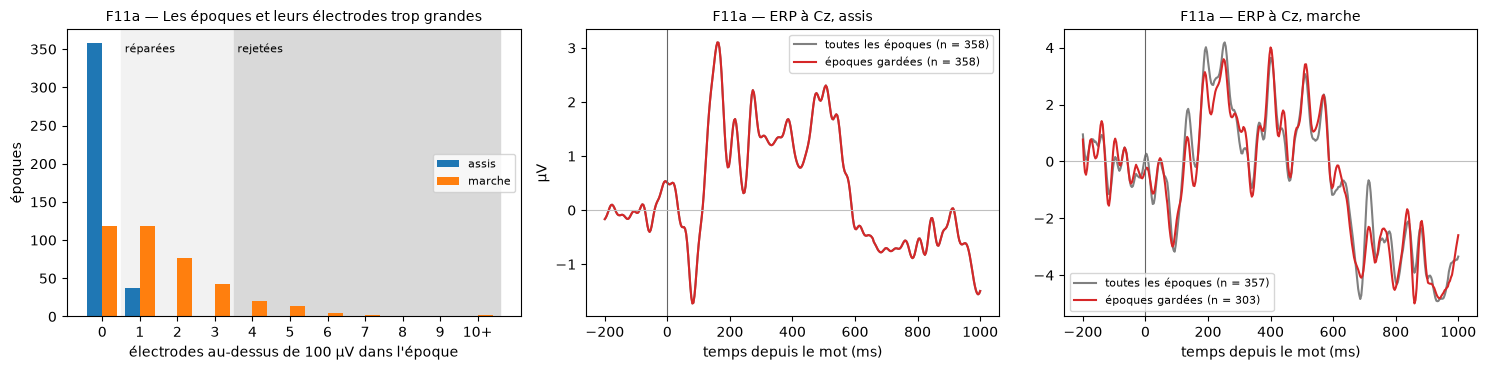

In [65]:
# ---- F11a : avant et après le rejet et la réparation des époques -----------------------------------------------------------------
montrees = choisir_electrodes(AFFICHAGE['F11'], CANAUX, 'F11a')              # les électrodes de l'ERP (AFFICHAGE, 0.4) : leur moyenne
lignes_f11 = [CANAUX.index(c) for c in montrees]
signal_f11, n_f11 = region_mesuree(mes_epoques, montrees)                    # vos époques (11.7), électrodes mesurées seulement (0.4)
temps_ms = np.arange(r0, r1 + 1) / FS * 1000                                 # de -200 à 1000 ms
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), gridspec_kw=dict(width_ratios=[1.1, 1, 1]))
for posture, decalage, couleur in (('seated', -0.2, 'C0'), ('walking', 0.2, 'C1')):
    n_trop = [(pics[nom][np.isin(raison[nom], ['ok', 'amplitude', 'posture_unusable'])] > SEUIL_REJET_UV).sum(axis=1)
              for nom in essais if enregistrements.loc[nom, 'posture'] == posture]   # électrodes au-dessus du seuil, dans chaque époque
    if not n_trop:
        continue
    compte_trop = np.bincount(np.minimum(np.concatenate(n_trop), 10), minlength=11)   # 10 ou plus : la dernière colonne
    axes[0].bar(np.arange(11) + decalage, compte_trop, 0.4, color=couleur, label=NOM_POSTURE[posture])
axes[0].axvspan(0.5, MAX_REPARATIONS + 0.5, color='0.95', zorder=0)
axes[0].axvspan(MAX_REPARATIONS + 0.5, 10.6, color='0.85', zorder=0)
haut = axes[0].get_ylim()[1]
axes[0].text(0.6, 0.92 * haut, 'réparées', fontsize=8)
axes[0].text(MAX_REPARATIONS + 0.6, 0.92 * haut, 'rejetées', fontsize=8)
axes[0].set_xticks(range(11))
axes[0].set_xticklabels([str(k) for k in range(10)] + ['10+'])
axes[0].set_xlabel(f'électrodes au-dessus de {SEUIL_REJET_UV:g} µV dans l\'époque')
axes[0].set_ylabel('époques')
axes[0].set_title('F11a — Les époques et leurs électrodes trop grandes', fontsize=10)
axes[0].legend(fontsize=8, loc='center right')
for ax, posture in zip(axes[1:], ('seated', 'walking')):
    non_reparees = []                                                        # sans rejet ni réparation, les essais à réponse correcte
    for nom in essais:
        if enregistrements.loc[nom, 'posture'] != posture:
            continue
        for k, s in enumerate(essais[nom]['sample'].to_numpy(int)):
            if raison[nom][k] in ('ok', 'amplitude') and essais[nom].loc[k, 'rt_ok'] == True:
                non_reparees.append(final[nom][lignes_f11, s + r0:s + r1 + 1].mean(axis=0) - final[nom][lignes_f11, s + b0:s + b1].mean())
    apres = signal_f11[(mes_epoques.metadata['posture'] == NOM_POSTURE[posture]).to_numpy() & (n_f11 > 0)]   # au moins une électrode mesurée
    if not non_reparees or not len(apres):
        ax.text(0.5, 0.5, 'aucune époque utilisable', transform=ax.transAxes, ha='center')
        ax.set_title(f'F11a — ERP à {nom_choix(montrees)}, {NOM_POSTURE[posture]}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    ax.plot(temps_ms, np.mean(non_reparees, axis=0), color='0.5', label=f'toutes les époques (n = {len(non_reparees)})')
    ax.plot(mes_epoques.times * 1000, apres.mean(axis=0), color='C3', label=f'époques gardées (n = {len(apres)})')
    ax.axvline(0, color='0.4', lw=0.8)                                       # l'apparition du mot
    ax.axhline(0, color='0.75', lw=0.8)
    ax.set_title(f'F11a — ERP à {nom_choix(montrees)}, {NOM_POSTURE[posture]}', fontsize=10)
    ax.set_xlabel('temps depuis le mot (ms)')
    ax.legend(fontsize=8)
axes[1].set_ylabel('µV')
plt.tight_layout()
plt.show()

**Que regarder ? (F11a)** À gauche, les époques sont rangées selon le nombre de leurs électrodes au-dessus de 100 µV : 0, l'époque est
gardée telle quelle ; 1 à 3, ces électrodes sont reconstruites ; 4 ou plus, l'époque est rejetée. Chez P003, assis, presque toutes les
époques sont à 0 ; en marche, beaucoup ont au moins une électrode trop grande. Au milieu et à droite, l'ERP à Cz (`AFFICHAGE['F11']`, 0.4) avec
toutes les époques (gris, sans rejet ni réparation) et avec les époques gardées (rouge). Chez P003, l'écart reste petit à Cz : les époques
rejetées étaient surtout trop grandes ailleurs, aux électrodes qui bougent avec les pas.

**Bloc Type 2 : pourquoi réparer ?** Mettez `MAX_REPARATIONS = 0` dans la cellule 11.6 : une époque est alors rejetée dès qu'une seule de
ses électrodes dépasse 100 µV. Relancez la cellule 11.6 et celles qui suivent : combien d'époques restent utilisables en marche ? Mettez
ensuite aussi `PART_EPOQUES = 1.01` dans la cellule 11.3, pour qu'aucune électrode ne soit plus reconstruite dans toutes les époques, et
relancez à partir de 11.3. Comparez les essais gardés, la SME (section 14) et les effets de la section 13 avant de juger. Remettez enfin
`MAX_REPARATIONS = 3` et `PART_EPOQUES = 0.5`.

<details><summary>Indice</summary>

Chez P003, les époques utilisables pour les ERP passent de 358 assis et 317 en marche à 327 et 105 sans réparation, puis à 320 et 2 quand
plus aucune électrode n'est reconstruite. Rejeter toute époque dont une seule électrode est trop grande paraît prudent, mais avec des
électrodes sèches, en marche, cela détruit presque toutes les données. La réparation n'est pas là parce que l'interpolation est parfaite :
elle échange un peu de signal reconstruit contre beaucoup d'essais gardés. C'est pourquoi les mesures n'utilisent ensuite que les
électrodes mesurées (11.9 et section 13).
</details>

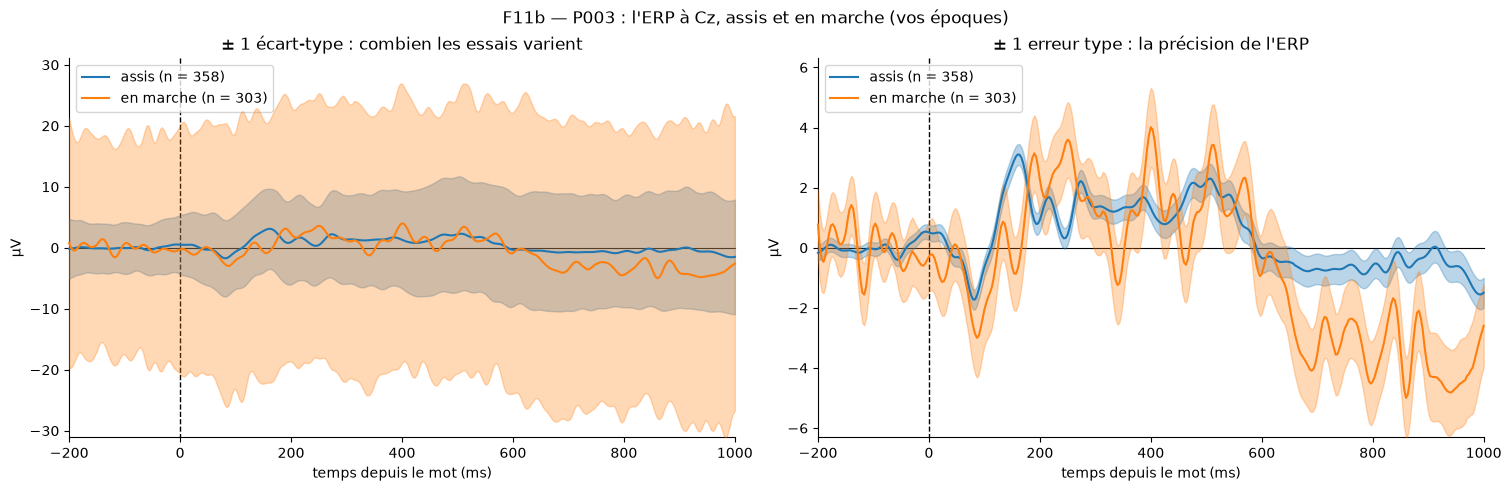

In [66]:
# ---- F11b : l'ERP, assis et en marche, avec deux bandes -------------------------------------------------------------------------
BANDE_ERP = 'écart-type'     # modifiable : la bande de F11c et F13a, 'écart-type' (combien les époques varient) ou 'erreur type' (la précision)


def ecart_type(x):
    """La bande ± 1 écart-type. MNE donne x (une ligne par époque, une colonne par instant) ; on rend le bas et le haut de la bande."""
    moyenne, ecart = x.mean(axis=0), x.std(axis=0, ddof=1)                  # l'ERP et l'écart-type des époques, à chaque instant
    return np.array([moyenne - ecart, moyenne + ecart])


def erreur_type(x):
    """La bande ± 1 erreur type : l'écart-type divisé par la racine du nombre d'époques."""
    moyenne, erreur = x.mean(axis=0), x.std(axis=0, ddof=1) / np.sqrt(len(x))
    return np.array([moyenne - erreur, moyenne + erreur])


bande_erp = ecart_type if BANDE_ERP == 'écart-type' else erreur_type        # la bande de F11c et F13a
montrees = choisir_electrodes(AFFICHAGE['F11'], CANAUX, 'F11b')              # les électrodes de l'ERP (AFFICHAGE, 0.4) : leur moyenne
signal_f11, n_f11 = region_mesuree(mes_epoques, montrees)                    # chaque époque : ses électrodes mesurées seulement (0.4)
courbes = {}                                                                 # légende : les époques de la courbe
for posture, legende in (('assis', 'assis'), ('marche', 'en marche')):
    choix = (mes_epoques.metadata['posture'] == posture).to_numpy() & (n_f11 > 0)   # cette posture, au moins une électrode mesurée
    if choix.sum() >= 3:                                                     # une posture sans époque n'a pas de courbe
        une = mne.EpochsArray(signal_f11[choix][:, None, :] * 1e-6, mne.create_info(['ERP'], FS, 'eeg'), tmin=mes_epoques.tmin, verbose=False)
        courbes[f'{legende} (n = {choix.sum()})'] = list(une.iter_evoked())   # chaque époque à part ; MNE fait la moyenne
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), layout='constrained')
for ax, bande, titre in ((axes[0], ecart_type, '± 1 écart-type : combien les essais varient'),
                         (axes[1], erreur_type, '± 1 erreur type : la précision de l\'ERP')):
    mne.viz.plot_compare_evokeds(courbes, picks='ERP', ci=bande, axes=ax, show=False, time_unit='ms', legend='upper left',
                                 show_sensors=False, truncate_xaxis=False, truncate_yaxis=False)
    ax.set_title(titre)
    ax.set_xlabel('temps depuis le mot (ms)')
fig.suptitle(f'F11b — {PARTICIPANT} : l\'ERP à {nom_choix(montrees)}, assis et en marche (vos époques)')
plt.show()

**Que regarder ? (F11b)** Le nombre d'époques de chaque posture est dans la légende. Après une onde négative vers 100 ms, l'ERP monte vers
une onde positive entre 150 et 250 ms (la P2), puis viennent les ondes plus lentes qui suivent la lecture du mot. La figure est faite par
MNE (`mne.viz.plot_compare_evokeds`) : on lui donne chaque époque à part, et il trace leur moyenne (l'ERP) avec une bande autour. Les deux
panneaux montrent les mêmes courbes avec deux bandes :
- à gauche, **± 1 écart-type** : à chaque instant, l'écart-type des époques. Cette bande montre combien les essais varient autour de l'ERP :
  si leurs valeurs suivent à peu près une loi normale, environ deux époques sur trois y tombent. En marche, elle est bien plus large, parce
  que chaque essai est plus agité ;
- à droite, **± 1 erreur type** : l'écart-type divisé par la racine du nombre d'époques. Cette bande montre la précision de l'ERP : plus
  elle est étroite, plus la courbe est sûre. Elle rétrécit quand on ajoute des essais, l'écart-type non. Son échelle est plus serrée : la
  forme des courbes s'y voit mieux.

`BANDE_ERP` choisit la bande de F11c et de F13a (au départ, l'écart-type). Le notebook 09 fait cette analyse sur tous les participants.

F11a à F11c montrent les électrodes d'`AFFICHAGE['F11']` (0.4, Cz au départ). Chaque époque ne compte que celles d'entre elles qui y ont
été mesurées, et une époque où elles sont toutes reconstruites est laissée de côté (11.9). Regarder d'autres électrodes ici est une
exploration : cela ne change pas les régions de la section 13.

### F11c — L'ERP pour chaque type de mot

F11b mélangeait tous les types de mot. Ici, il y a une courbe par type (mot fréquent `HF`, mot rare `LF`, pseudo-mot) et par posture ; `n`
est le nombre d'époques utilisables, et la bande est celle de F11b. Les deux postures n'ont pas la même échelle : lisez l'axe
vertical avant de les comparer. La figure décrit les données, elle ne teste rien : le notebook 09 fait les tests. Une condition qui a
peu d'essais donne une courbe plus bruitée, donc regardez les `n` avant de comparer les courbes.

Regardez aussi la période avant le mot (de -200 à 0 ms). Si les courbes y bougent déjà beaucoup (chez P003, en marche), la ligne de base de
l'étape 11 est elle-même bruitée, et ce bruit se retrouve dans chaque époque (la section 15 y revient). F11g (avec `OPTIONNEL = True`,
0.4) montre l'ERP à chaque électrode, reconstruites comprises.

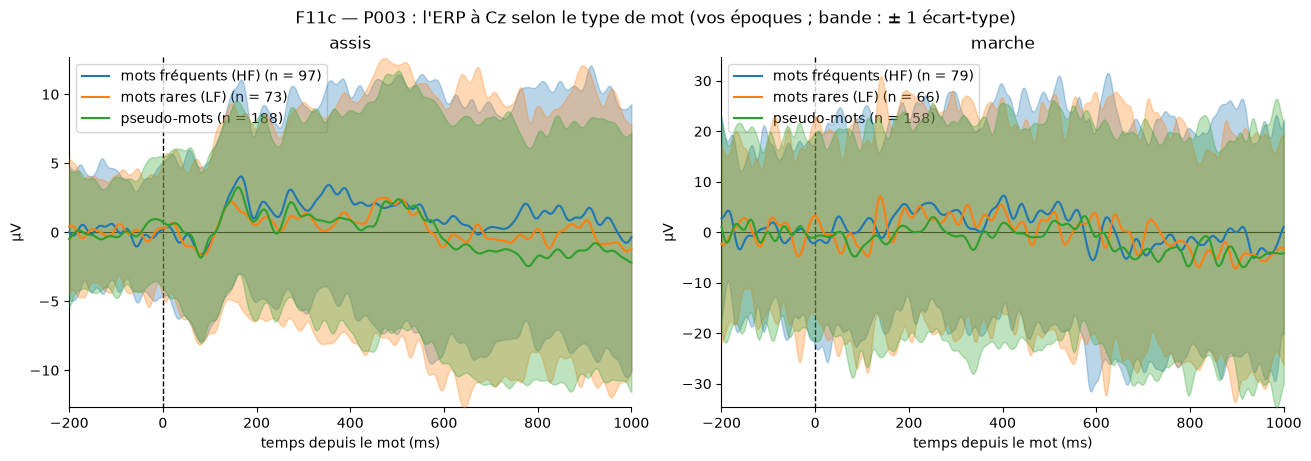

In [67]:
# ---- F11c : l'ERP pour chaque type de mot, séparément pour chaque posture --------------------------------------------------------
TYPES = {'mots fréquents (HF)': 'HF', 'mots rares (LF)': 'LF', 'pseudo-mots': 'pseudo'}   # légende : le type de mot dans les métadonnées
montrees = choisir_electrodes(AFFICHAGE['F11'], CANAUX, 'F11c')              # les électrodes de l'ERP (AFFICHAGE, 0.4) : leur moyenne
signal_f11, n_f11 = region_mesuree(mes_epoques, montrees)                    # chaque époque : ses électrodes mesurées seulement (0.4)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout='constrained')
for ax, posture in zip(axes, ('assis', 'marche')):
    courbes = {}
    for legende, typ in TYPES.items():
        choix = ((mes_epoques.metadata['posture'] == posture) & (mes_epoques.metadata['type'] == typ)).to_numpy() & (n_f11 > 0)   # cette posture, ce type de mot
        if choix.sum() >= 3:                                                 # un type sans époque n'a pas de courbe
            une = mne.EpochsArray(signal_f11[choix][:, None, :] * 1e-6, mne.create_info(['ERP'], FS, 'eeg'), tmin=mes_epoques.tmin, verbose=False)
            courbes[f'{legende} (n = {choix.sum()})'] = list(une.iter_evoked())
    if courbes:
        mne.viz.plot_compare_evokeds(courbes, picks='ERP', ci=bande_erp, axes=ax, show=False, time_unit='ms', legend='upper left',
                                     show_sensors=False, truncate_xaxis=False, truncate_yaxis=False)
        ax.set_xlabel('temps depuis le mot (ms)')
    else:
        ax.text(0.5, 0.5, 'aucune époque utilisable', transform=ax.transAxes, ha='center')
    ax.set_title(posture)
fig.suptitle(f'F11c — {PARTICIPANT} : l\'ERP à {nom_choix(montrees)} selon le type de mot (vos époques ; bande : ± 1 {BANDE_ERP})')
plt.show()

In [68]:
# ---- F11g (Bloc Type 3) : l'ERP à chaque électrode, assis et en marche -------------------------------------------------------------
if OPTIONNEL:
    evoques = {legende: mes_epoques[posture].average() for posture, legende in (('assis', 'assis'), ('marche', 'en marche'))
               if (mes_epoques.metadata['posture'] == posture).any()}       # la moyenne des époques, électrodes reconstruites comprises
    mne.viz.plot_compare_evokeds(evoques, picks='eeg', axes='topo', show_sensors=False, truncate_xaxis=False, truncate_yaxis=False,
                                 title=f'F11g — {PARTICIPANT} : l\'ERP à chaque électrode (électrodes reconstruites comprises)')
else:
    print('F11g non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.')

F11g non exécutée : mettez OPTIONNEL = True dans la cellule 0.4.


### 11.8 Bilan : ce que le pipeline a modifié

Un pipeline devrait laisser un résumé de ce qu'il a modifié, pas seulement un fichier final. Le tableau rassemble, pour votre participant,
les essais gardés par posture et le nombre de composantes oculaires corrigées. Une forte correction (beaucoup de composantes corrigées,
d'électrodes reconstruites ou d'époques rejetées) est un résultat à rapporter, pas seulement une étape à valider.

In [69]:
# ---- 11.8 Résumé du prétraitement ------------------------------------------------------------------------------------------------
lignes_qc = []
for posture_fr, posture_en in (('assis', 'seated'), ('marche', 'walking')):
    t = tableau[tableau['posture'] == posture_en]                            # les essais de cette posture
    n_total = len(t)
    n_eeg_ok = int((t['epoch_reason'] == 'ok').sum())                        # époques dont l'EEG est acceptable
    n_erp = int(((t['epoch_reason'] == 'ok') & (t['rt_ok'] == True)).sum())  # et dont la réponse est correcte et pas aberrante
    lignes_qc.append({
        'posture': posture_fr,
        'essais': n_total,
        'EEG acceptable': n_eeg_ok,
        'ERP utilisables': n_erp,
        'part gardée pour les ERP (%)': round(100 * n_erp / n_total, 1) if n_total else np.nan,
        'composantes corrigées par la wICA': len(modele[posture_en]['oculaires']) if posture_en in modele else 0,
    })
display(pd.DataFrame(lignes_qc).set_index('posture'))
print('Électrodes laissées de côté partout (étape 2) :', [c for c, s in zip(CANAUX, systematiques) if s] or 'aucune')
print('Électrodes reconstruites dans toutes les époques (étape 11.3) :', [c for c, s in zip(CANAUX, a_reconstruire) if s] or 'aucune')

,essais,EEG acceptable,ERP utilisables,part gardée pour les ERP (%),composantes corrigées par la wICA
posture,,,,,
assis,397,395,358,90.2,16
marche,400,357,317,79.2,7


Électrodes laissées de côté partout (étape 2) : ['P7']
Électrodes reconstruites dans toutes les époques (étape 11.3) : ['Fp2', 'F7', 'F8', 'P3', 'O2']


### 11.9 Les électrodes mesurées dans chaque région (Bloc Type 1)

Une électrode reconstruite garde la carte complète, mais son signal ne vient pas d'elle : c'est une combinaison de ses voisines. Une
électrode peut être reconstruite à quatre moments : laissée de côté partout (étape 2), mauvaise dans un seul enregistrement (4.2), trop
souvent au-dessus de 100 µV (11.3) ou trop grande dans une seule époque (11.6). La colonne `reconstruites` des métadonnées (11.7) garde,
pour chaque époque, la liste de ces électrodes, comme dans les fichiers fournis. Le tableau compte, pour les trois régions de la section 13,
combien d'électrodes sont vraiment mesurées dans vos époques, et la part des époques qui en ont moins que `MIN_MESUREES`.

`MIN_MESUREES` n'est pas une étape de rejet : les époques restent dans le fichier. Dans la section 13, `EXIGER_MINIMUM = True` (13.1) laisse
une époque hors d'une composante seulement quand moins de `MIN_MESUREES` électrodes de sa région y ont été mesurées, comme
`EXIGER_MINIMUM` dans le notebook 09.

In [70]:
# ---- 11.9 Les électrodes mesurées dans chaque région -------------------------------------------------------------------------------
REGIONS_ERP = {'P2': ['Fz', 'Cz', 'F3', 'F4'], 'N400': ['C3', 'Cz', 'C4', 'P3', 'Pz', 'P4'], 'LPC': ['P3', 'Pz', 'P4']}   # ne pas modifier : celles de la section 13
MIN_MESUREES = {'P2': 3, 'N400': 4, 'LPC': 2}   # modifiable : le minimum d'électrodes mesurées pour qu'une époque compte dans la région
lignes_reg = []
for posture in ('assis', 'marche'):
    md = mes_epoques.metadata[mes_epoques.metadata['posture'] == posture]   # vos époques de cette posture
    if md.empty:
        continue
    listes = [str(r).split() for r in md['reconstruites']]                 # les électrodes reconstruites de chaque époque
    ligne = {'posture': posture, 'époques': len(md),
             'reconstruites dans toutes les époques': ' '.join(c for c in CANAUX if all(c in r for r in listes)) or '-',
             'reconstruites par époque (moyenne)': round(np.mean([len(r) for r in listes]), 1)}
    for composante, region in REGIONS_ERP.items():
        n_mesurees = np.array([sum(c not in r for c in region) for r in listes])   # les électrodes mesurées de la région, époque par époque
        ligne[f'{composante} : électrodes mesurées (sur {len(region)})'] = round(n_mesurees.mean(), 2)
        ligne[f'{composante} : époques sous {MIN_MESUREES[composante]} (%)'] = round(100 * (n_mesurees < MIN_MESUREES[composante]).mean(), 1)
    lignes_reg.append(ligne)
pd.DataFrame(lignes_reg).set_index('posture').T

posture,assis,marche
époques,358,317
reconstruites dans toutes les époques,Fp2 F7 F8 P7 P3 O2,Fp2 F7 F8 P7 P3 O2
reconstruites par époque (moyenne),6.1,7.4
P2 : électrodes mesurées (sur 4),4.0,3.51
P2 : époques sous 3 (%),0.0,9.1
N400 : électrodes mesurées (sur 6),4.92,4.89
N400 : époques sous 4 (%),0.0,0.6
LPC : électrodes mesurées (sur 3),1.92,1.98
LPC : époques sous 2 (%),7.5,1.6


**Que regarder ? (11.9)** Chez P003, six électrodes sont reconstruites dans toutes les époques (Fp2, F7, F8, P7, P3, O2), et une époque en
compte en moyenne 6,1 assis et 7,4 en marche : le tiers du casque. La région de la LPC n'a plus que Pz et P4, et seulement P4 dans
27 époques assises (7,5 %), où Pz est réparée. En marche, 9 % des époques ont moins de 3 des 4 électrodes de la P2. Le notebook 09 fait
le même tableau pour tous les participants (section 0.5).

### 11.10 Une électrode reconstruite vaut-elle une électrode mesurée ? (Bloc Type 3)

Pour le savoir, on cache une électrode mesurée, on la reconstruit à partir de toutes les autres (la même interpolation sphérique que le
pipeline), puis on compare la reconstruction à ce que l'électrode a vraiment enregistré, de deux façons :
- **le signal continu** : la corrélation r, échantillon par échantillon, sur tous les échantillons utilisables des blocs ;
- **l'ERP moyen** : la corrélation entre l'ERP de l'électrode (de -200 à 1000 ms, vos époques où elle n'a pas été réparée) et celui de sa
  reconstruction, et l'écart quadratique moyen entre les deux (en µV).

On recommence pour chaque électrode mesurée, dans chaque posture.

In [71]:
# ---- 11.10 (Bloc Type 3) Cacher chaque électrode mesurée, la reconstruire à partir des autres, comparer ------------------------
vrai_c, refait_c, vrai_erp, refait_erp = {}, {}, {}, {}      # (posture, électrode) -> le signal mesuré et le reconstruit, et leurs époques
for nom in essais:                                           # les blocs de la tâche
    posture = NOM_POSTURE[enregistrements.loc[nom, 'posture']]
    vraies = [c for c, k in zip(CANAUX, reelles[nom]) if k]  # les électrodes mesurées dans ce bloc (après 11.4)
    du_bloc = (meta['enregistrement'] == nom).to_numpy()     # vos époques (11.7) qui viennent de ce bloc
    debuts_bloc, k_du_bloc = meta.loc[du_bloc, 'sample'].to_numpy(int), k_bloc[du_bloc]
    for c in vraies:
        voisines = [v for v in vraies if v != c]             # toutes les autres électrodes mesurées
        info_v = mne.create_info(voisines + [c], FS, 'eeg')
        info_v.set_montage(MONTAGE)
        tmp = mne.io.RawArray(np.vstack([final[nom][[CANAUX.index(v) for v in voisines]], np.zeros((1, final[nom].shape[1]))]) * 1e-6, info_v)
        tmp.info['bads'] = [c]
        tmp.interpolate_bads(reset_bads=True, method=dict(eeg='spline'), origin=(0.0, 0.0, 0.04))   # comme aux étapes 4.2, 10.1 et 11
        refait = tmp.get_data(picks=[c])[0] * 1e6            # l'électrode reconstruite (µV)
        vrai = final[nom][CANAUX.index(c)]                   # l'électrode mesurée (µV)
        vrai_c.setdefault((posture, c), []).append(vrai[~bad[nom]])   # les échantillons utilisables
        refait_c.setdefault((posture, c), []).append(refait[~bad[nom]])
        for s in debuts_bloc[pics[nom][k_du_bloc, CANAUX.index(c)] <= SEUIL_REJET_UV]:   # les époques où c n'a pas été réparée (11.6)
            vrai_erp.setdefault((posture, c), []).append(vrai[s + r0:s + r1 + 1] - vrai[s + b0:s + b1].mean())
            refait_erp.setdefault((posture, c), []).append(refait[s + r0:s + r1 + 1] - refait[s + b0:s + b1].mean())
lignes_loo = []
for posture, c in vrai_c:
    if len(vrai_erp.get((posture, c), [])) < 20:
        continue                                             # trop peu d'époques pour un ERP
    erp_vrai, erp_refait = np.mean(vrai_erp[(posture, c)], axis=0), np.mean(refait_erp[(posture, c)], axis=0)   # les deux ERP moyens
    lignes_loo.append(dict(posture=posture, electrode=c,
                           r_continu=np.corrcoef(np.concatenate(vrai_c[(posture, c)]), np.concatenate(refait_c[(posture, c)]))[0, 1],
                           r_erp=np.corrcoef(erp_vrai, erp_refait)[0, 1], ecart_erp_uv=np.sqrt(np.mean((erp_vrai - erp_refait) ** 2))))
loo = pd.DataFrame(lignes_loo)
print('r : la corrélation entre l\'électrode mesurée et sa reconstruction ; écart : en µV, sur l\'ERP moyen. La médiane des électrodes :')
print(loo.groupby('posture')[['r_continu', 'r_erp', 'ecart_erp_uv']].median().round(2).to_string())
loo.pivot(index='electrode', columns='posture', values=['r_continu', 'r_erp', 'ecart_erp_uv']).round(2)   # électrode par électrode

r : la corrélation entre l'électrode mesurée et sa reconstruction ; écart : en µV, sur l'ERP moyen. La médiane des électrodes :
         r_continu  r_erp  ecart_erp_uv
posture                                
assis         0.25   0.93          2.51
marche        0.08   0.73          2.21


r_continu        r_erp        ecart_erp_uv       
posture       assis marche assis marche        assis marche
electrode                                                  
C3             0.27   0.13  0.91   0.84         6.85   3.50
C4             0.39   0.13  0.97   0.77         2.31   1.72
Cz             0.05   0.36  0.72   0.81         0.79   1.39
F3             0.47   0.08  0.90   0.85         4.85   2.14
F4             0.40  -0.26  0.93   0.77         3.17   2.21
Fp1            0.25  -0.26  0.93  -0.15        12.75  10.59
Fz             0.57   0.01  0.95   0.80         1.46   1.27
O1             0.11   0.16  0.97   0.73         5.93   3.23
P4             0.09   0.30  0.96   0.72         1.52   1.96
P8             0.30   0.09  0.96   0.73         1.39   7.51
Pz             0.02   0.06  0.79   0.65         2.51   1.79
T7             0.10   0.06 -0.85  -0.07        10.63   4.65
T8             0.17  -0.02  0.87  -0.05         2.34   4.26

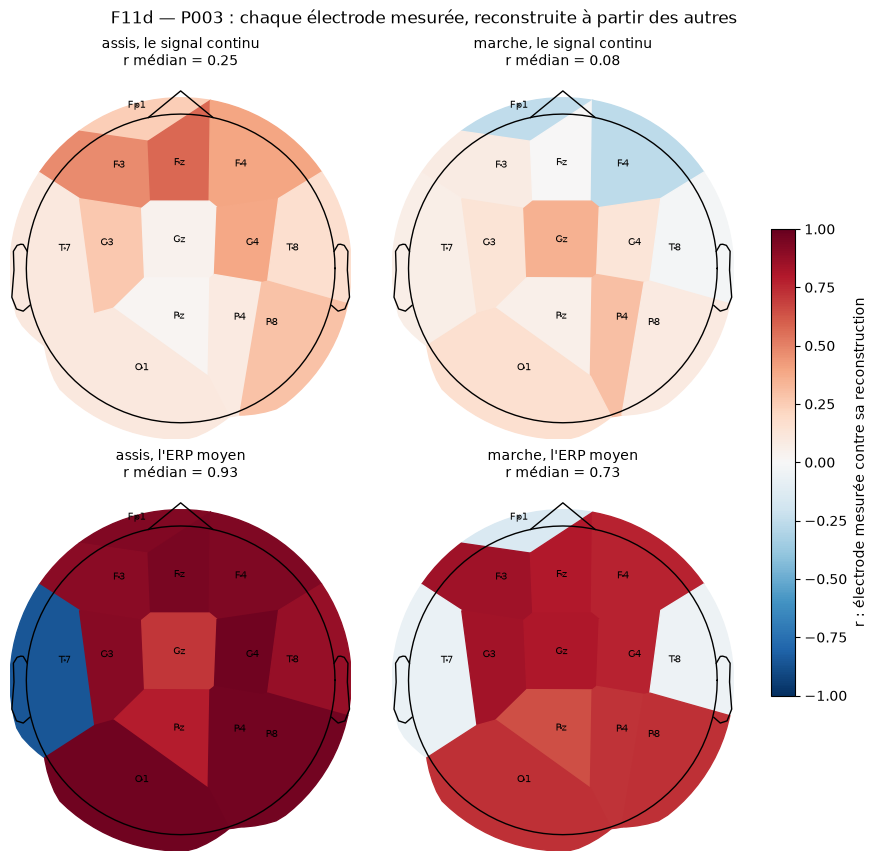

In [72]:
# ---- F11d : la reconstruction de chaque électrode, assis et en marche ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(9, 8.5), layout='constrained')
image = None
for col, posture in enumerate(('assis', 'marche')):
    res = loo[loo['posture'] == posture]                     # les électrodes testées dans cette posture
    for ligne, (colonne, titre) in enumerate((('r_continu', 'le signal continu'), ('r_erp', 'l\'ERP moyen'))):
        ax = axes[ligne, col]
        if res.empty:
            ax.text(0.5, 0.5, 'aucune époque utilisable', transform=ax.transAxes, ha='center')
            ax.set_axis_off()
            continue
        info_r = mne.create_info(list(res['electrode']), FS, 'eeg')
        info_r.set_montage(MONTAGE)
        image, _ = mne.viz.plot_topomap(res[colonne].to_numpy(), info_r, axes=ax, show=False, vlim=(-1, 1), cmap='RdBu_r', contours=0,
                                        image_interp='nearest', names=list(res['electrode']))   # une case par électrode, sans lissage
        ax.set_title(f'{posture}, {titre}\nr médian = {res[colonne].median():.2f}', fontsize=10)
if image is not None:
    fig.colorbar(image, ax=axes, shrink=0.6, label='r : électrode mesurée contre sa reconstruction')
fig.suptitle(f'F11d — {PARTICIPANT} : chaque électrode mesurée, reconstruite à partir des autres')
plt.show()

**Que regarder ? (11.10, F11d)** Chez P003, la reconstruction suit assez bien la forme de l'ERP moyen (r médian 0,93 assis, 0,73 en
marche), mais presque pas le signal continu (0,25 et 0,08). L'interpolation combine les voisines : elle reproduit ce qu'elles partagent, la
partie lisse et étendue du signal que la moyenne des essais garde, pas ce que l'électrode enregistre seule, essai par essai. Même quand la
forme suit, l'amplitude peut être fausse : à C3, r = 0,91 assis, mais l'écart est de 6,9 µV. Les électrodes du bord sont les moins bien
reconstruites : T7 (r = -0,85 assis pour l'ERP), T8 en marche, et Fp1, dont les voisines Fp2 et F7 sont elles-mêmes reconstruites (12,8 µV
d'écart assis). Sur les dix participants du projet Brain Walk, le même test donne des r médians de 0,35 (signal continu) et 0,92 (ERP)
assis, 0,25 et 0,77 en marche.

C'est pourquoi le pipeline garde les électrodes reconstruites pour avoir une carte complète, mais pas pour les mesures : la valeur d'une
région, dans une époque, est la moyenne de ses seules électrodes mesurées dans cette époque (section 13, et notebooks 09 à 11).

## 12. Comparer avec le fichier fourni (Bloc Type 1)

Le fichier `pretraite/sub-PXXX_epo.fif` de votre participant (`PXXX` : son numéro) a été produit par le pipeline du projet Brain Walk avec les réglages de ce notebook (ceux de v1.0, sauf la correction non lissée de
l'étape 5). Si vous n'avez changé aucun paramètre, vos époques doivent être
les mêmes, à de minuscules arrondis près (quelques millièmes de µV au plus). Si vous avez changé un paramètre, cette cellule mesure la différence. Elle vérifie aussi que vos époques ont les mêmes électrodes
reconstruites (la colonne `reconstruites`, 11.7) que le fichier fourni.

Les versions des paquets comptent. Ce notebook a été testé avec MNE 1.13, NumPy 2.5, SciPy 1.18, PyWavelets 1.8 et python-picard 0.8 :
avec ces versions, les époques sont celles des fichiers fournis (vérifié chez les 9 participants). Avec des versions plus anciennes,
plusieurs époques peuvent différer d'environ 1 µV sans que votre code soit en cause. Si la cellule 12.1 montre une différence alors que vous
n'avez rien changé, comparez d'abord vos versions (cellule 0.2) avant de chercher une erreur dans la logique.

Une ou deux époques peuvent quand même différer de quelques dixièmes de µV sans que vous ayez rien changé : quand une décision tombe presque
pile sur un seuil (par exemple un coefficient d'ondelette de l'étape 8), de minuscules différences de calcul entre ordinateurs la font basculer.
La cellule dit combien d'époques diffèrent et lesquelles.

F12 montre votre ERP, celui du fichier fourni et leur différence, aux électrodes d'`AFFICHAGE['F12']` (0.4). Quand vous changez un
paramètre (Blocs Type 2), elle montre où, dans l'époque, la différence apparaît.

In [73]:
# ---- 12.1 Vos époques contre celles du fichier fourni ------------------------------------------------------------------------------
fournies = mne.read_epochs(DOSSIER / 'pretraite' / f'sub-{PARTICIPANT}_epo.fif', preload=True)
print(f'Époques : les vôtres {len(mes_epoques)}, le fichier fourni {len(fournies)}')
memes_essais = (len(mes_epoques) == len(fournies)
                and (mes_epoques.metadata[['posture', 'essai']].to_numpy() == fournies.metadata[['posture', 'essai']].to_numpy()).all())
if memes_essais:
    ecarts = np.abs(mes_epoques.get_data() - fournies.get_data()).max(axis=(1, 2)) * 1e6   # le plus grand écart de chaque époque (µV)
    n_diff = int((ecarts >= 0.01).sum())                                     # les époques qui diffèrent de 0,01 µV ou plus
    print(f'Les mêmes essais. Plus grand écart : {ecarts.max():.4f} µV')
    if n_diff == 0:
        print('Identique au fichier fourni.')
    else:
        print(f'{n_diff} époque(s) sur {len(ecarts)} diffère(nt) de 0,01 µV ou plus :')
        print(mes_epoques.metadata.loc[ecarts >= 0.01, ['posture', 'bloc', 'essai']].head(10).to_string(index=False))
        print('Quelques époques seulement : un arrondi de calcul qui fait basculer une décision au seuil (voir plus haut), ou un paramètre changé.' if n_diff <= 3
              else 'Beaucoup d\'époques diffèrent : avez-vous changé un paramètre ? Sinon, comparez vos versions (cellule 0.2) à celles de l\'étape 12.')
    if 'reconstruites' in fournies.metadata:                 # les électrodes reconstruites de chaque époque (11.7)
        autres = int((mes_epoques.metadata['reconstruites'].to_numpy() != fournies.metadata['reconstruites'].to_numpy()).sum())
        print('Électrodes reconstruites : ' + ('les mêmes que dans le fichier fourni.' if autres == 0 else f'{autres} époque(s) diffèrent.'))
    else:
        print('Le fichier fourni ne dit pas quelles électrodes sont reconstruites : relancez la cellule 0.1, elle télécharge la dernière version des données.')
else:
    print('Pas les mêmes essais : un paramètre a changé quelles époques sont gardées.')
montrees = choisir_electrodes(AFFICHAGE['F12'], CANAUX, '12.1')             # les électrodes de l'ERP comparé (AFFICHAGE, 0.4) : leur moyenne
for posture in ('assis', 'marche'):
    if not ((mes_epoques.metadata['posture'] == posture).any() and (fournies.metadata['posture'] == posture).any()):
        print(f'{posture} : aucune époque utilisable (posture mise de côté à l\'étape 11.3)')
        continue
    a, b = mes_epoques[posture].average(picks=montrees).data.mean(axis=0), fournies[posture].average(picks=montrees).data.mean(axis=0)
    print(f'{posture} : ERP à {nom_choix(montrees)}, plus grand écart {np.abs(a - b).max() * 1e6:.4f} µV')

Époques : les vôtres 675, le fichier fourni 675
Les mêmes essais. Plus grand écart : 0.0001 µV
Identique au fichier fourni.
Électrodes reconstruites : les mêmes que dans le fichier fourni.
assis : ERP à Cz, plus grand écart 0.0000 µV
marche : ERP à Cz, plus grand écart 0.0000 µV


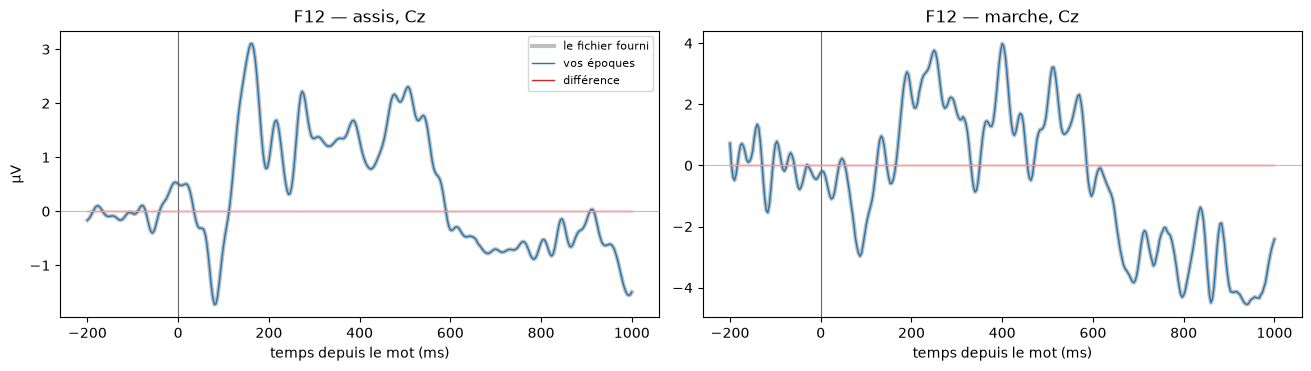

In [74]:
# ---- F12 : votre ERP et celui du fichier fourni ----------------------------------------------------------------------------------
montrees = choisir_electrodes(AFFICHAGE['F12'], CANAUX, 'F12')               # les électrodes de l'ERP comparé (AFFICHAGE, 0.4) : leur moyenne
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), layout='constrained')
for ax, posture in zip(axes, ('assis', 'marche')):
    if not ((mes_epoques.metadata['posture'] == posture).any() and (fournies.metadata['posture'] == posture).any()):
        ax.text(0.5, 0.5, 'aucune époque utilisable', transform=ax.transAxes, ha='center')
        continue
    mien = mes_epoques[posture].average(picks=montrees).data.mean(axis=0) * 1e6   # votre ERP (µV)
    fourni = fournies[posture].average(picks=montrees).data.mean(axis=0) * 1e6    # celui du fichier fourni
    ax.plot(fournies.times * 1000, fourni, color='0.75', lw=3, label='le fichier fourni')
    ax.plot(mes_epoques.times * 1000, mien, color='C0', lw=1, label='vos époques')
    ax.plot(mes_epoques.times * 1000, mien - fourni, color='C3', lw=1, label='différence')
    ax.axvline(0, color='0.4', lw=0.8)                                       # l'apparition du mot
    ax.axhline(0, color='0.75', lw=0.8)
    ax.set_xlabel('temps depuis le mot (ms)')
    ax.set_title(f'F12 — {posture}, {nom_choix(montrees)}')
axes[0].set_ylabel('µV')
axes[0].legend(fontsize=8)
plt.show()

## 13. Trois composantes et deux effets (Bloc Type 1)

**Pourquoi cette section ?** F11b et F11c montraient l'ERP à une électrode. Une analyse d'ERP mesure plutôt des **composantes** : une onde,
dans une fenêtre de temps, sur une région du scalp. On mesure ici, sur vos époques, les trois composantes du notebook 09 et les deux effets
qu'il teste : la **posture** (en marche moins assis) et la **fréquence** des mots (mots rares, LF, moins mots fréquents, HF ; les
pseudo-mots ne sont pas dans cette comparaison).

| Composante | Région | Fenêtre | Ce qu'on en sait |
|---|---|---|---|
| P2 | Fz, Cz, F3, F4 | 180 à 250 ms après le mot | onde positive précoce, liée à l'attention et à l'analyse visuelle du mot |
| N400 | C3, Cz, C4, P3, Pz, P4 | 300 à 500 ms après le mot | onde négative, plus grande quand l'accès au sens du mot est difficile, par exemple pour un mot rare (Kutas et Federmeier, 2011) |
| LPC | P3, Pz, P4 | de 100 ms avant la tape jusqu'à la tape | onde positive tardive, liée à la décision (Twomey et al., 2015) |

**Des fenêtres et des régions fixées d'avance.** Ce sont celles du notebook 09, choisies d'après la littérature avant de voir les données.
Déplacer une fenêtre, pour un participant ou une condition, là où l'effet paraît le plus grand rend le test trop optimiste. Si une fenêtre
doit changer (la P2 ne culmine pas à la même latence chez tout le monde), le changement se décide avant de regarder les effets, s'applique
à tous les participants et à toutes les conditions, et se rapporte comme une analyse de sensibilité. Pour regarder d'autres électrodes,
utilisez F11b et F11c (`AFFICHAGE['F11']`, 0.4) : c'est une exploration, pas une nouvelle région.

**Les électrodes mesurées seulement.** Une électrode reconstruite n'est pas une mesure (11.10). La valeur d'une région, dans une époque,
est donc la moyenne de ses seules électrodes mesurées dans cette époque (la fonction `region_mesuree`, en 0.4), et les cartes (F13b) n'ont
de valeur qu'aux électrodes mesurées. Chez P003, P3 est reconstruite dans toutes les époques : la région de la N400 repose sur C3, Cz, C4,
Pz et P4, celle de la LPC sur Pz et P4. Avec `EXIGER_MINIMUM = True` (13.1), une époque doit aussi avoir au moins `MIN_MESUREES` électrodes
mesurées dans la région (11.9 : 3 sur 4 pour la P2, 4 sur 6 pour la N400, 2 sur 3 pour la LPC) pour compter dans cette composante. C'est le
choix `EXIGER_MINIMUM` du notebook 09, désactivé au départ dans les deux.

**La LPC, centrée sur la tape.** Dans les tâches de décision, cette onde pariétale monte pendant que la décision se forme et atteint son
maximum vers le moment de la réponse (O'Connell et al., 2012 ; Twomey et al., 2015). Or la tape arrive à un moment différent dans chaque
essai : dans une époque centrée sur le mot, la LPC de chaque essai tombe à un moment différent, et la moyenne l'étale. On découpe donc une
deuxième époque, de -800 à +200 ms autour de la tape, dans le signal de 11.4, et on mesure la LPC de -100 à 0 ms, comme le projet Brain
Walk. Cette époque garde la ligne de base de l'époque du mot (-200 à 0 ms avant le mot), pour que les deux époques d'un même essai partent
du même zéro, et on y reconstruit les électrodes reconstruites dans l'époque du mot (11.6). Le dossier `pretraite/tape/` contient les
époques de la tape du projet Brain Walk : 13.2 les compare aux vôtres, comme 12.1 pour les époques du mot, et le notebook 09 s'en sert pour
mesurer la LPC chez tous les participants.

**Les clignements autour de la tape.** On cligne souvent des yeux juste après avoir répondu (F6b). L'étape 9 traite chaque clignement de
250 ms avant son sommet à 350 ms après : un clignement qui culmine juste après la tape commence avant elle, dans la fenêtre de la
LPC, et les étapes 8 et 9 n'en enlèvent pas tout. On montre donc la LPC deux fois : avec tous les essais, puis avec les seuls essais
**sans clignement**, ceux où l'étape 6 n'a repéré aucun clignement entre 250 ms avant le mot et 250 ms après la tape. Brosnan et al. (2023)
font ce tri avec un oculomètre, de 100 ms avant le stimulus à 100 ms après la réponse ; la marge est plus grande ici parce que l'étape 6
repère le sommet du clignement, pas son début. Ce tri coûte des essais, et il ne voit que les clignements que l'étape 6 a repérés.

In [75]:
# ---- 13.1 Les trois composantes, et une deuxième époque centrée sur la tape ------------------------------------------------------
FENETRE_LPC = (-0.100, 0.0)  # modifiable (Brain Walk : -0,1 à 0 s) : la fenêtre de la LPC par rapport à la tape, entre -0,8 et 0,2 s
MARGE_CLIG_S = 0.25          # modifiable (au départ : 0,25 s) : aucun clignement de cette marge avant le mot à cette marge après la tape
EXIGER_MINIMUM = False       # modifiable : True pour qu'une époque compte dans une composante seulement si MIN_MESUREES (11.9) électrodes de sa région sont mesurées
EPOQUE_TAPE = (-0.8, 0.2)    # ne pas modifier : l'époque autour de la tape (s), celle du projet Brain Walk
COMPOSANTES = {                                                              # ne pas modifier : celles du notebook 09 (la LPC : sur la tape)
    'P2': dict(region=['Fz', 'Cz', 'F3', 'F4'], fenetre=(0.180, 0.250), centre='mot'),
    'N400': dict(region=['C3', 'Cz', 'C4', 'P3', 'Pz', 'P4'], fenetre=(0.300, 0.500), centre='mot'),
    'LPC': dict(region=['P3', 'Pz', 'P4'], fenetre=FENETRE_LPC, centre='tape'),
}
EFFETS = {'posture': ('posture', {'assis': 'assis', 'en marche': 'marche'}),         # effet : (colonne des métadonnées, {légende : valeur})
          'fréquence': ('type', {'mots fréquents (HF)': 'HF', 'mots rares (LF)': 'LF'})}   # sans les pseudo-mots
q0, q1 = int(round(EPOQUE_TAPE[0] * FS)), int(round(EPOQUE_TAPE[1] * FS))     # en échantillons
tapes = {}
for nom in essais:
    reponses = evenements[nom][evenements[nom]['trial_type'] == 'response']
    if reponses['trial'].duplicated().any():                                 # une vérification : ces données ont une réponse par essai
        print(f'{nom} : un essai a plusieurs réponses ; la dernière est gardée')
    # numéro de l'essai : l'échantillon de sa tape, arrondi depuis son temps (onset), comme dans le projet Brain Walk
    tapes[nom] = dict(zip(reponses['trial'].astype(int), np.round(reponses['onset'].to_numpy(float) * FS).astype(int)))
essais_tape = tableau[utiles].assign(k=tableau.groupby('enregistrement').cumcount()[utiles]).reset_index(drop=True)   # vos époques (11.7)
donnees_tape, meta_tape, verif_tape = [], [], []
for i, ligne in essais_tape.iterrows():                                      # la ligne i est l'époque i de mes_epoques
    nom, s, k = ligne['enregistrement'], int(ligne['sample']), int(ligne['k'])   # k : la place de l'essai dans son bloc
    tape = tapes[nom].get(int(ligne['trial']))
    if tape is None or tape + q0 < 0 or tape + q1 + 1 > final[nom].shape[1]:
        continue                                                             # pas de tape, ou son époque sort de l'enregistrement
    epoque = final[nom][:, tape + q0:tape + q1 + 1] - final[nom][:, s + b0:s + b1].mean(axis=1, keepdims=True)   # le signal de 11.4, ligne de base du mot
    trop = reelles[nom] & (pics[nom][k] > SEUIL_REJET_UV)                    # les électrodes reconstruites dans l'époque du mot (11.6)
    if trop.any():                                                           # on les reconstruit ici aussi, de la même façon
        noms_sources = [c for c, garde_c in zip(CANAUX, reelles[nom] & ~trop) if garde_c]
        cibles = [c for c, t in zip(CANAUX, trop) if t]
        info_tape = mne.create_info(noms_sources + cibles, FS, 'eeg')
        info_tape.set_montage(MONTAGE)
        tmp = mne.io.RawArray(np.vstack([epoque[reelles[nom] & ~trop], np.zeros((len(cibles), epoque.shape[1]))]) * 1e-6, info_tape, verbose=False)
        tmp.info['bads'] = cibles
        tmp.interpolate_bads(reset_bads=True, method=dict(eeg='spline'), origin=(0.0, 0.0, 0.04), verbose=False)
        epoque[trop] = tmp.get_data(picks=cibles) * 1e6
    donnees_tape.append(epoque)
    sans = not np.any((clignements[nom] >= s / FS - MARGE_CLIG_S) & (clignements[nom] <= tape / FS + MARGE_CLIG_S))   # aucun clignement (6.1)
    meta_tape.append(dict(mes_epoques.metadata.iloc[i]) | {'sans_clignement': sans})
    verif_tape.append(dict(posture=NOM_POSTURE[ligne['posture']], ecart_ms=1000 * ((tape - s) / FS - ligne['response_time']),   # la tape contre le TR (13.1b)
                           touche_bad=bool(bad[nom][tape + q0:tape + q1 + 1].any())))   # un moment BAD dans l'époque de la tape
epoques_tape = mne.EpochsArray(np.array(donnees_tape) * 1e-6, mes_epoques.info, tmin=EPOQUE_TAPE[0], metadata=pd.DataFrame(meta_tape),
                               verbose=False)                                # MNE travaille en volts
verif_tape = pd.DataFrame(verif_tape)
LIGNES_13 = [('P2', mes_epoques, False), ('N400', mes_epoques, False),     # (composante, époques, essais sans clignement seulement)
             ('LPC', epoques_tape, False), ('LPC', epoques_tape, True)]
print(f'{len(epoques_tape)} époques centrées sur la tape, pour {len(mes_epoques)} époques centrées sur le mot')
for posture in ('assis', 'marche'):
    sans_clig = epoques_tape.metadata.loc[epoques_tape.metadata['posture'] == posture, 'sans_clignement']
    if len(sans_clig):
        print(f'{posture} : {sans_clig.sum()} essais sans clignement sur {len(sans_clig)}')

675 époques centrées sur la tape, pour 675 époques centrées sur le mot
assis : 56 essais sans clignement sur 358
marche : 118 essais sans clignement sur 317


### 13.1b Deux vérifications des époques de la tape (Bloc Type 1)

L'étape 11 a vérifié les époques du mot de -0,2 à +1,0 s. Les époques de la tape vont plus loin : la tape arrive 0,5 à 1,5 s après le mot,
et son époque finit 0,2 s après elle. Deux vérifications, dans le premier tableau :
- `plus_grand_ecart_ms` : la tape du fichier d'événements contre le temps de réaction du fichier de comportement. Les deux doivent
  s'accorder à quelques ms près ; sinon, l'époque n'est pas calée sur la réponse.
- `touchent_BAD` : les époques de la tape qui touchent un moment marqué BAD (étapes 1 et 2), que l'étape 11 n'a pas vu.

Le deuxième tableau compare les temps de réaction des essais sans clignement à ceux des essais avec un clignement. Les essais sans clignement
sont un sous-ensemble choisi par un comportement : s'ils sont plus rapides ou plus lents, ce ne sont pas seulement « les mêmes essais sans
les clignements », et leur LPC peut aussi différer pour cette raison. F13d montre quand tombent les clignements par rapport à la tape.

In [76]:
# ---- 13.1b Deux vérifications des époques de la tape, et les temps de réaction des essais sans clignement --------------------------
verif_13 = verif_tape.groupby('posture').agg(epoques=('ecart_ms', 'size'), plus_grand_ecart_ms=('ecart_ms', lambda g: g.abs().max()),
                                             touchent_BAD=('touche_bad', 'sum'))
display(verif_13.round(1))
tr_clig = epoques_tape.metadata.assign(essais=np.where(epoques_tape.metadata['sans_clignement'], 'sans clignement', 'avec un clignement'))
tr_clig.groupby(['posture', 'essais'])['tr_ms'].agg(['count', 'median']).round(0)   # temps de réaction (ms)

,epoques,plus_grand_ecart_ms,touchent_BAD
posture,,,
assis,358,3.2,0
marche,317,3.1,0


count  median
posture essais                           
assis   avec un clignement    302   664.0
        sans clignement        56   655.0
marche  avec un clignement    199   677.0
        sans clignement       118   662.0

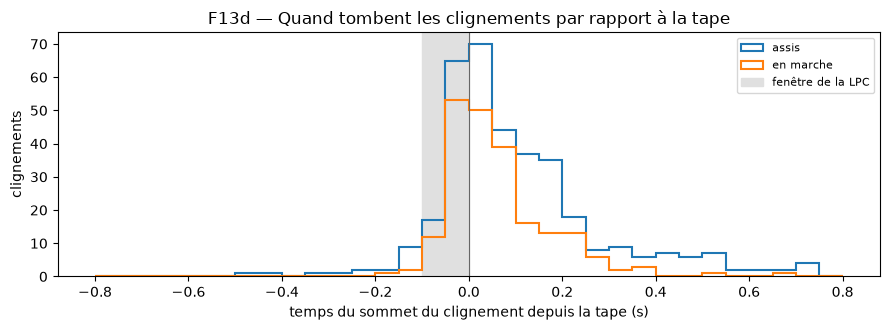

In [77]:
# ---- F13d : quand tombent les clignements par rapport à la tape ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 3.4))
for posture, etiquette, couleur in (('assis', 'assis', 'C0'), ('marche', 'en marche', 'C1')):
    ecarts = []                                                              # le temps de chaque clignement par rapport à la tape de chaque essai (s)
    for i, ligne in essais_tape.iterrows():
        tape = tapes[ligne['enregistrement']].get(int(ligne['trial']))
        if tape is not None and NOM_POSTURE[ligne['posture']] == posture:
            d = clignements[ligne['enregistrement']] - tape / FS
            ecarts.extend(d[(d >= -0.8) & (d < 0.8)])
    ax.hist(ecarts, bins=np.arange(-0.8, 0.81, 0.05), histtype='step', lw=1.5, color=couleur, label=etiquette)
ax.axvspan(FENETRE_LPC[0], FENETRE_LPC[1], color='0.88', zorder=0, label='fenêtre de la LPC')
ax.axvline(0, color='0.4', lw=0.8)                                           # la tape
ax.set_xlabel('temps du sommet du clignement depuis la tape (s)')
ax.set_ylabel('clignements')
ax.set_title('F13d — Quand tombent les clignements par rapport à la tape')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Que regarder ? (13.1b, F13d)** Chez P003, la tape du fichier d'événements et le temps de réaction du fichier de comportement s'accordent à
3 ms près, et aucune époque de la tape ne touche un moment BAD. Les essais sans clignement sont à peu près aussi rapides que les autres
(médiane de 655 contre 664 ms assis, 662 contre 677 ms en marche). F13d montre pourquoi si peu d'essais sont sans clignement : assis, les
sommets des clignements s'accumulent juste après la tape (227 dans les 400 ms qui la suivent), et 82 tombent dans la fenêtre de la LPC
elle-même. Un clignement qui culmine juste après la tape commence avant elle.

In [78]:
# ---- 13.2 Vos époques de la tape contre celles du fichier fourni (le calcul de 12.1) ---------------------------------------------
fichier_tape = DOSSIER / 'pretraite' / 'tape' / f'sub-{PARTICIPANT}_tape_epo.fif'
if not fichier_tape.exists():
    print(f'{fichier_tape.name} est introuvable : vos données datent d\'avant les époques de la tape (relancez la cellule 0.1, elle télécharge la dernière version des données)')
else:
    fournies_tape = mne.read_epochs(fichier_tape, preload=True)
    print(f'Époques de la tape : les vôtres {len(epoques_tape)}, le fichier fourni {len(fournies_tape)}')
    memes_tape = (len(epoques_tape) == len(fournies_tape)
                  and (epoques_tape.metadata[['posture', 'essai']].to_numpy() == fournies_tape.metadata[['posture', 'essai']].to_numpy()).all())
    if memes_tape:
        ecarts = np.abs(epoques_tape.get_data() - fournies_tape.get_data()).max(axis=(1, 2)) * 1e6   # le plus grand écart de chaque époque (µV)
        n_diff = int((ecarts >= 0.01).sum())
        print(f'Les mêmes essais. Plus grand écart : {ecarts.max():.4f} µV')
        print('Identique au fichier fourni.' if n_diff == 0 else f'{n_diff} époque(s) sur {len(ecarts)} diffère(nt) de 0,01 µV ou plus (voir 12.1).')
        if MARGE_CLIG_S == 0.25:                                             # le fichier fourni utilise la marge de départ
            autres = int((epoques_tape.metadata['sans_clignement'].to_numpy() != fournies_tape.metadata['sans_clignement'].to_numpy()).sum())
            print('Essais sans clignement : ' + ('les mêmes que dans le fichier fourni.' if autres == 0 else f'{autres} essai(s) diffèrent.'))
    else:
        print('Pas les mêmes essais : un paramètre a changé quelles époques sont gardées.')

Époques de la tape : les vôtres 675, le fichier fourni 675
Les mêmes essais. Plus grand écart : 0.0001 µV
Identique au fichier fourni.
Essais sans clignement : les mêmes que dans le fichier fourni.


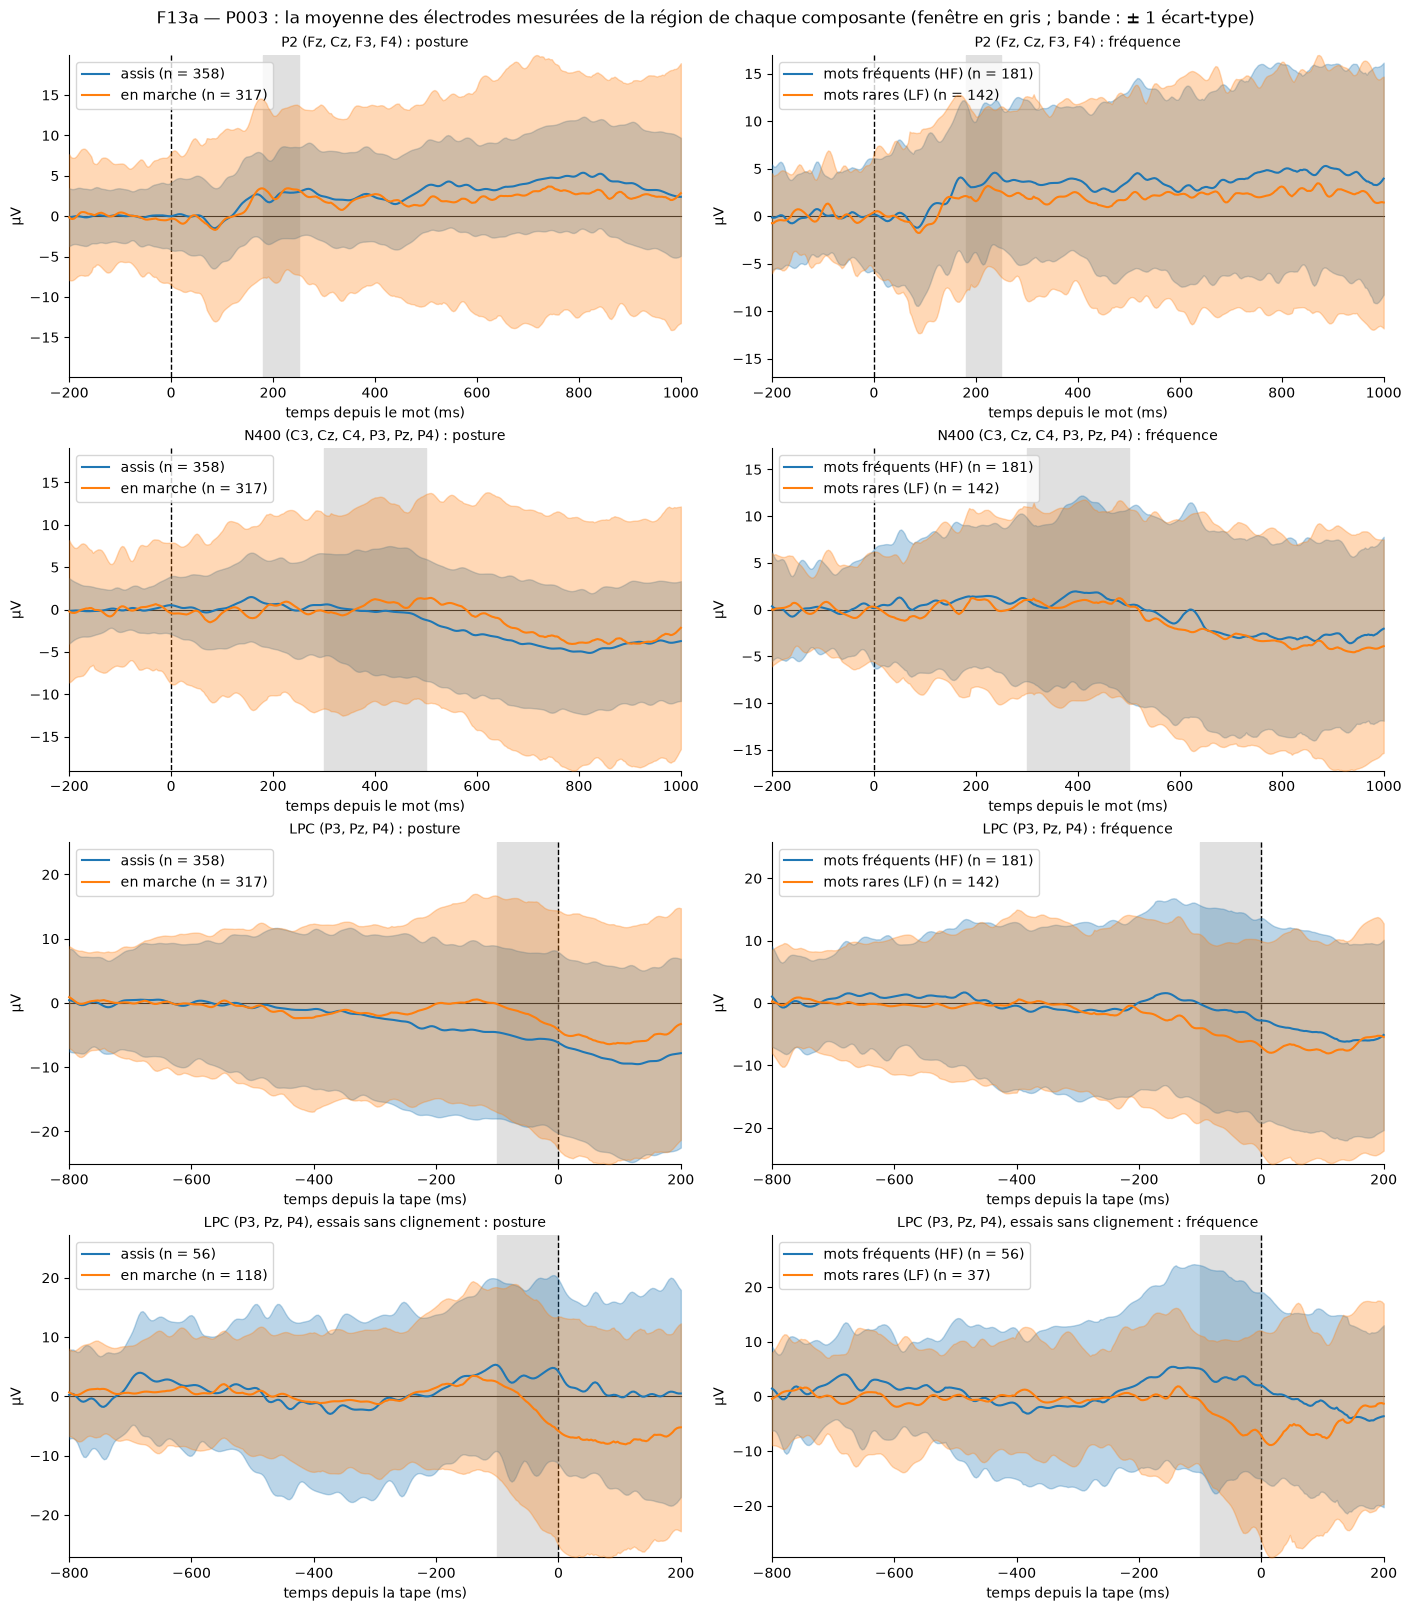

In [79]:
# ---- F13a : les trois composantes, pour chacun des deux effets -------------------------------------------------------------------
fig, axes = plt.subplots(len(LIGNES_13), len(EFFETS), figsize=(14, 16), layout='constrained')
for ligne, (composante, ep, sans_clig) in enumerate(LIGNES_13):
    c = COMPOSANTES[composante]
    signal, n_mesurees = region_mesuree(ep, c['region'])                     # la région, époque par époque, sans les électrodes reconstruites (0.4)
    garde = ep.metadata['sans_clignement'].to_numpy() if sans_clig else np.ones(len(ep), bool)
    if EXIGER_MINIMUM:
        garde = garde & (n_mesurees >= MIN_MESUREES[composante])             # assez d'électrodes mesurées dans la région (11.9)
    for col, (effet, (colonne, niveaux)) in enumerate(EFFETS.items()):
        ax = axes[ligne, col]
        courbes = {}
        for legende, valeur in niveaux.items():
            choix = garde & (ep.metadata[colonne] == valeur).to_numpy()
            if choix.sum() >= 3:                                             # il faut quelques époques pour une courbe et sa bande
                une = mne.EpochsArray(signal[choix][:, None, :] * 1e-6, mne.create_info(['région'], FS, 'eeg'), tmin=ep.tmin, verbose=False)
                courbes[f'{legende} (n = {choix.sum()})'] = list(une.iter_evoked())
        if courbes:
            mne.viz.plot_compare_evokeds(courbes, picks='région', ci=bande_erp, axes=ax, show=False, time_unit='ms',
                                         legend='upper left', show_sensors=False, truncate_xaxis=False, truncate_yaxis=False)
            ax.axvspan(c['fenetre'][0] * 1000, c['fenetre'][1] * 1000, color='0.88', zorder=0)   # la fenêtre de la composante
            ax.set_xlabel(f'temps depuis {"le mot" if c["centre"] == "mot" else "la tape"} (ms)')
        else:
            ax.text(0.5, 0.5, 'trop peu d\'époques', transform=ax.transAxes, ha='center')
        ax.set_title(f'{composante} ({", ".join(c["region"])}){", essais sans clignement" if sans_clig else ""} : {effet}', fontsize=10)
fig.suptitle(f'F13a — {PARTICIPANT} : la moyenne des électrodes mesurées de la région de chaque composante (fenêtre en gris ; bande : ± 1 {BANDE_ERP})'
             + (f'\nseulement les époques qui ont au moins MIN_MESUREES électrodes mesurées dans la région' if EXIGER_MINIMUM else ''))
plt.show()

**Que regarder ? (F13a)** Chaque courbe est la moyenne, époque par époque, des électrodes mesurées de la région (le titre donne la
région) ; la bande grise verticale est la fenêtre de la composante. La bande colorée (± 1 écart-type) est bien plus large que l'écart entre les courbes : un essai
varie beaucoup plus que la différence entre deux conditions, et c'est pourquoi il faut des dizaines d'essais par condition. Chez P003 :
- la **P2** est nette dans les deux postures et pour les deux types de mots : une onde positive vers 200 ms ;
- dans la fenêtre de la **N400**, les courbes restent près de 0 µV, et les mots rares ne s'y distinguent pas des mots fréquents ;
- avec tous les essais, la **LPC** n'a pas l'allure d'une onde positive : assis, la région descend vers -5 µV dans la fenêtre et vers
  -10 µV juste après la tape. Sur les essais sans clignement (dernière ligne), elle est positive assis (+3,7 µV dans la fenêtre). Regardez
  les `n` : il reste 56 essais assis sur 358, et 118 en marche sur 317.

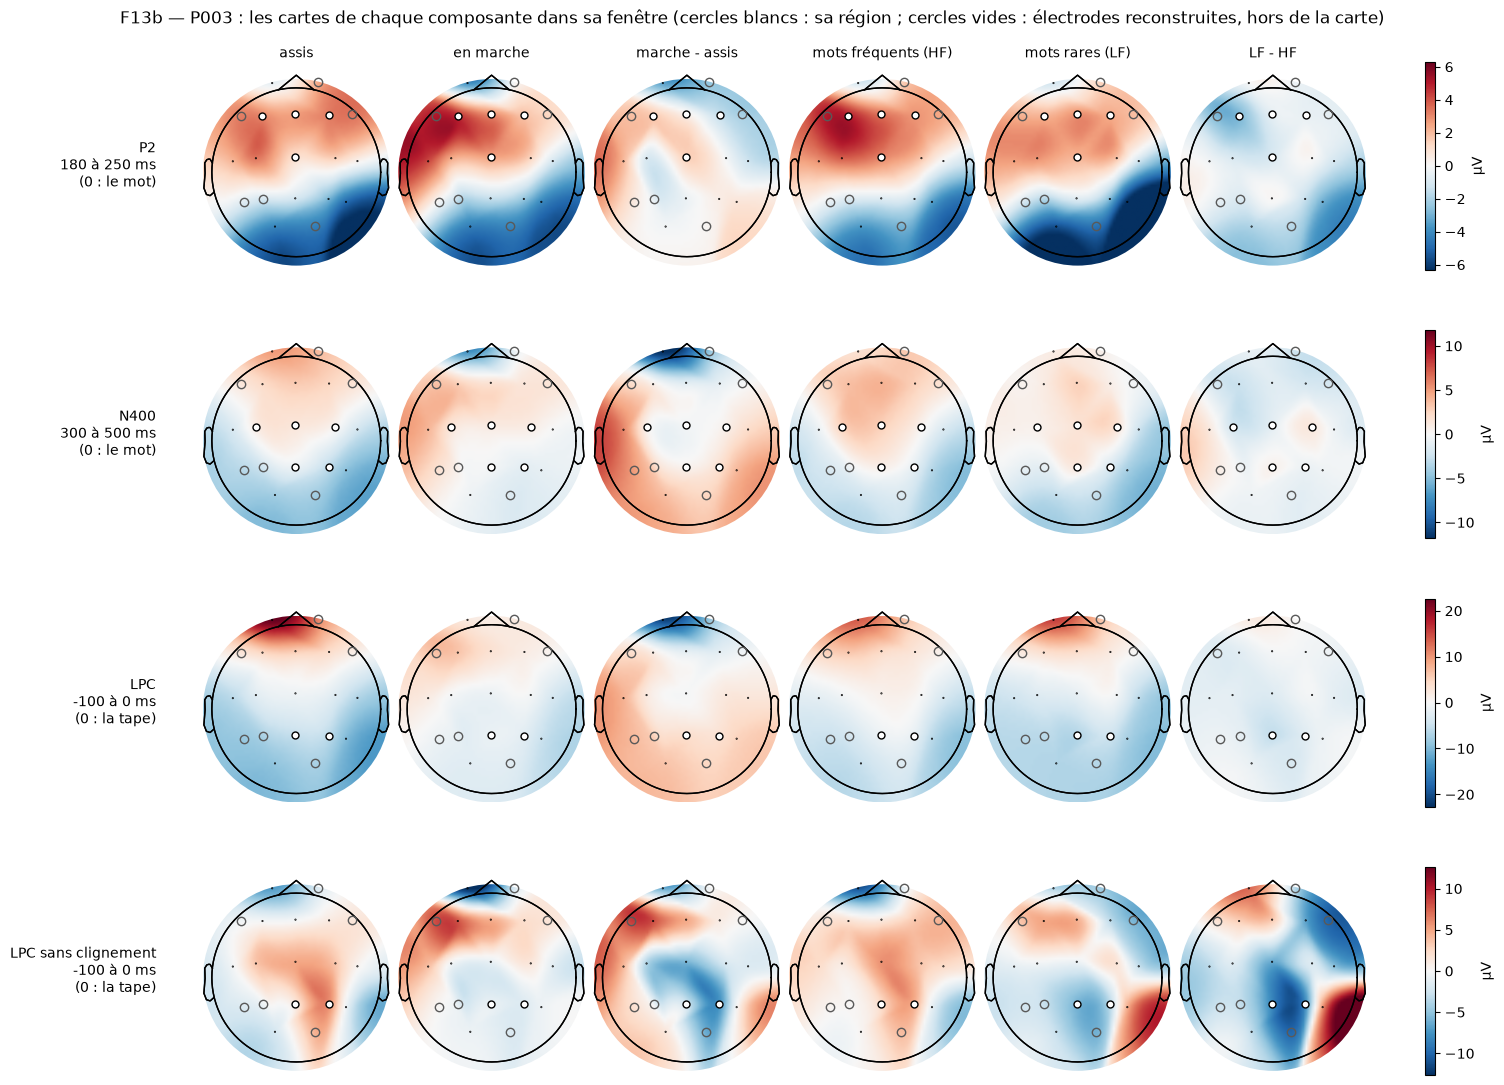

In [80]:
# ---- F13b : les cartes de chaque composante dans sa fenêtre ----------------------------------------------------------------------
from matplotlib.colors import ListedColormap                 # une carte de couleurs transparente, pour les cercles vides
# (titre, colonne des métadonnées, a, b) : chaque carte est la moyenne des époques a, ou la différence a - b
COLONNES = [('assis', 'posture', 'assis', None), ('en marche', 'posture', 'marche', None), ('marche - assis', 'posture', 'marche', 'assis'),
            ('mots fréquents (HF)', 'type', 'HF', None), ('mots rares (LF)', 'type', 'LF', None), ('LF - HF', 'type', 'LF', 'HF')]


def moyenne_mesuree(amplitude, mesuree, choix):
    """Pour chaque électrode, la moyenne des époques choisies où elle a été mesurée (NaN si elle l'a été dans moins de 3)."""
    compte = (mesuree & choix[:, None]).sum(axis=0)                            # le nombre d'époques mesurées, électrode par électrode
    somme = np.where(mesuree & choix[:, None], amplitude, 0.0).sum(axis=0)
    return np.where(compte >= 3, somme / np.maximum(compte, 1), np.nan)


fig, axes = plt.subplots(len(LIGNES_13), len(COLONNES), figsize=(15, 11), layout='constrained')
for ligne, (composante, ep, sans_clig) in enumerate(LIGNES_13):
    c = COMPOSANTES[composante]
    amplitude = ep.get_data(tmin=c['fenetre'][0], tmax=c['fenetre'][1], units='uV').mean(axis=2)   # moyenne de la fenêtre, par époque et électrode
    mesuree = np.array([[ch not in str(r).split() for ch in ep.ch_names] for r in ep.metadata['reconstruites']])   # époques x électrodes
    garde = ep.metadata['sans_clignement'].to_numpy() if sans_clig else np.ones(len(ep), bool)
    cartes = []
    for titre, colonne, a, b in COLONNES:
        choix_a = garde & (ep.metadata[colonne] == a).to_numpy()
        choix_b = garde & (ep.metadata[colonne] == b).to_numpy()
        if choix_a.sum() < 3 or (b is not None and choix_b.sum() < 3):
            cartes.append(None)                                              # trop peu d'époques pour une carte
        else:
            cartes.append(moyenne_mesuree(amplitude, mesuree, choix_a) - (moyenne_mesuree(amplitude, mesuree, choix_b) if b is not None else 0))
    lim = max([np.nanmax(np.abs(carte)) for carte in cartes if carte is not None] or [1.0])   # la même échelle pour toute la ligne
    for col, carte in enumerate(cartes):
        ax = axes[ligne, col]
        if carte is None:
            ax.text(0.5, 0.5, 'trop peu\nd\'époques', transform=ax.transAxes, ha='center', va='center')
            ax.set_aspect('equal')                                           # carrée, comme une carte
            ax.set_axis_off()
            continue
        vue = np.isfinite(carte)                                             # les électrodes mesurées dans assez d'époques
        mne.viz.plot_topomap(carte[vue], mne.pick_info(ep.info, np.flatnonzero(vue)), axes=ax, show=False, vlim=(-lim, lim), cmap='RdBu_r',
                             contours=0, mask=np.isin(np.array(ep.ch_names)[vue], c['region']),   # la région de la composante : les cercles blancs
                             mask_params=dict(marker='o', markerfacecolor='w', markeredgecolor='k', markersize=5))
        if not vue.all():                                                    # les électrodes reconstruites : des cercles vides, sans valeur
            mne.viz.plot_topomap(np.zeros(len(carte)), ep.info, axes=ax, show=False, vlim=(-1, 1), cmap=ListedColormap([(0, 0, 0, 0)]),
                                 contours=0, sensors=False, mask=~vue,
                                 mask_params=dict(marker='o', markerfacecolor='none', markeredgecolor='0.35', markersize=6))
        if ligne == 0:
            ax.set_title(COLONNES[col][0], fontsize=10)
    axes[ligne, 0].text(-0.25, 0.5, f'{composante}{" sans clignement" if sans_clig else ""}\n{c["fenetre"][0] * 1000:.0f} à '
                        f'{c["fenetre"][1] * 1000:.0f} ms\n(0 : {"le mot" if c["centre"] == "mot" else "la tape"})',
                        transform=axes[ligne, 0].transAxes, ha='right', va='center')
    fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(-lim, lim), cmap='RdBu_r'), ax=axes[ligne, :], shrink=0.8, label='µV')
fig.suptitle(f'F13b — {PARTICIPANT} : les cartes de chaque composante dans sa fenêtre (cercles blancs : sa région ; '
             f'cercles vides : électrodes reconstruites, hors de la carte)')
plt.show()

In [81]:
# ---- 13.3 La valeur de chaque composante, et les deux effets ---------------------------------------------------------------------
valeurs_13 = {}
for composante, ep, sans_clig in LIGNES_13:
    c = COMPOSANTES[composante]
    # la valeur d'une époque : la moyenne des électrodes de la région mesurées dans cette époque, dans la fenêtre de la composante
    signal, n_mesurees = region_mesuree(ep.copy().crop(*c['fenetre']), c['region'])   # la région dans la fenêtre, sans les électrodes reconstruites
    valeur = signal.mean(axis=1)                                             # une valeur par époque
    garde = ep.metadata['sans_clignement'].to_numpy() if sans_clig else np.ones(len(ep), bool)
    if EXIGER_MINIMUM:
        garde = garde & (n_mesurees >= MIN_MESUREES[composante])             # assez d'électrodes mesurées dans la région (11.9)
    resultats = {}
    for effet, (colonne, niveaux) in EFFETS.items():
        a, b = niveaux.values()                                              # assis et marche, ou HF et LF
        xa, xb = valeur[garde & (ep.metadata[colonne] == a).to_numpy()], valeur[garde & (ep.metadata[colonne] == b).to_numpy()]
        resultats[(effet, a)] = xa.mean() if len(xa) else np.nan
        resultats[(effet, b)] = xb.mean() if len(xb) else np.nan
        assez = min(len(xa), len(xb)) >= 3
        resultats[(effet, f'{b} - {a}')] = xb.mean() - xa.mean() if assez else np.nan   # l'effet
        resultats[(effet, 'erreur type')] = np.sqrt(xa.var(ddof=1) / len(xa) + xb.var(ddof=1) / len(xb)) if assez else np.nan   # son erreur type
        resultats[(effet, 'n')] = f'{len(xa)} / {len(xb)}'                   # le nombre d'époques de chaque condition
    valeurs_13[composante + (' sans clignement' if sans_clig else '')] = resultats
print('La moyenne de la région dans la fenêtre (µV), et chaque effet avec son erreur type (µV)'
      + (", seulement les époques qui ont MIN_MESUREES électrodes mesurées dans la région :" if EXIGER_MINIMUM else ' :'))
pd.DataFrame.from_dict(valeurs_13, orient='index').round(2)

La moyenne de la région dans la fenêtre (µV), et chaque effet avec son erreur type (µV) :


posture                                               \
                      assis marche marche - assis erreur type          n   
P2                     2.53   2.98           0.44        0.57  358 / 317   
N400                  -0.18   0.43           0.61        0.65  358 / 317   
LPC                   -5.42  -1.99           3.43        1.15  358 / 317   
LPC sans clignement    3.67  -1.37          -5.04        2.50   56 / 118   

                    fréquence                                       
                           HF    LF LF - HF erreur type          n  
P2                       3.69  2.42   -1.27        0.81  181 / 142  
N400                     1.12  0.72   -0.40        0.96  181 / 142  
LPC                     -1.41 -5.56   -4.14        1.66  181 / 142  
LPC sans clignement      3.22 -4.76   -7.99        3.34    56 / 37

**Que regarder ? (F13b, 13.3)** Chaque carte montre, à chaque électrode mesurée, la moyenne de la fenêtre de la composante ; les cercles
blancs marquent sa région, et les cercles vides les électrodes reconstruites, qui n'ont pas de valeur. Entre les électrodes, la couleur
n'est qu'une interpolation pour l'affichage. Une ligne de cartes n'a qu'une échelle de couleurs : les différences (marche - assis, LF - HF)
se lisent sur la même échelle que les conditions. Chez P003 :
- la **P2** est positive à l'avant et au centre de la tête, là où est sa région ;
- avec tous les essais, la **LPC** assise est très positive au-dessus des yeux (Fp1 : +23 µV ; Fp2 est reconstruite) et négative à
  l'arrière de la tête. C'est la carte d'un clignement, pas celle d'une LPC : avec la référence moyenne, un clignement très positif à l'avant
  rend les autres électrodes un peu négatives, dont celles de la région de la LPC. Sur les essais sans clignement, la positivité à l'avant
  disparaît et la région devient positive ;
- dans le tableau de 13.3, l'effet de la posture sur la LPC vaut +3,4 µV avec tous les essais et -5,0 µV sans les essais à clignement : il
  change de signe. Assis, P003 cligne près de la tape dans 84 % des essais (302 sur 358), contre 63 % en marche (199 sur 317) : avec tous
  les essais, l'effet de la posture sur la LPC vient surtout des clignements.

**Lire l'erreur type d'un effet.** L'erreur type d'une condition est l'écart-type des valeurs de ses essais, divisé par la racine de leur
nombre (la section 14 l'appelle la SME). Celle d'une différence est la racine de la somme des carrés des deux. Un effet plus petit que
deux fois son erreur type ne se distingue pas du bruit chez ce participant. Chez P003, quatre effets dépassent deux erreurs types, tous sur
la LPC : celui de la posture avec tous les essais (+3,4 ± 1,2 µV), qui vient des clignements, et sans clignement (-5,0 ± 2,5 µV, tout
juste) ; celui de la fréquence avec tous les essais (LF - HF : -4,1 ± 1,7 µV) et sans clignement (-8,0 ± 3,3 µV, avec 56 et 37 essais) :
la LPC est plus grande pour les mots fréquents. Un participant ne suffit pas pour conclure : le notebook 09 teste les effets sur tous les
participants, avec la LPC centrée sur la tape et, si vous le choisissez, les seuls essais sans clignement.

**Les électrodes reconstruites.** Chez P003, P3 est reconstruite dans toutes les époques, et Pz dans 27 époques assises : dans ces époques,
la région de la LPC repose sur P4 seule (11.9). Si l'on moyennait aussi P3 reconstruite, comme si elle avait été mesurée, l'effet de la
posture sur la LPC vaudrait +4,3 µV au lieu de +3,4 µV. Une électrode reconstruite n'ajoute aucune mesure : elle ajoute à la région un
mélange de ses voisines, dont certaines n'en font pas partie.

**Bloc Type 2.**
1. Mettez `BANDE_ERP = 'erreur type'` dans la cellule F11b et relancez à partir de F11b : F11c et F13a montrent alors la précision de
   chaque courbe, et leur forme se voit mieux. Quelles différences entre conditions dépassent les bandes ?
2. Dans la cellule 13.1, mettez `MARGE_CLIG_S = 0.1`, puis `0.5`. Combien d'essais restent sans clignement ? À partir de quelle marge la
   LPC des essais sans clignement ne bouge-t-elle presque plus ?
3. Remettez `MARGE_CLIG_S = 0.25` et mettez `FENETRE_LPC = (-0.300, -0.100)` : la fenêtre s'arrête 100 ms avant la tape. L'effet de la
   posture est-il plus proche avec et sans les essais à clignement ?

### 13.4 L'effet de la fréquence change-t-il avec la posture ? (Bloc Type 1)

L'effet de la posture de 13.3 (marche - assis) mélange tout ce qui diffère entre les deux postures : le mouvement, l'attention, le bruit des
électrodes. Pour savoir si la marche change le traitement des mots, un contraste plus précis compare l'effet de la fréquence dans chaque
posture : (LF - HF) en marche moins (LF - HF) assis. Un décalage commun à tous les mots d'une posture s'annule dans chaque effet. C'est
l'interaction du notebook 09 (F7). Le tableau la donne pour votre participant, avec les règles de 13.3 et sans test : le notebook 09 la
teste sur tous les participants.

In [82]:
# ---- 13.4 L'effet de la fréquence dans chaque posture, et sa différence (un participant, sans test) ---------------------------------
valeurs_134 = {}
for composante, ep, sans_clig in LIGNES_13:
    c = COMPOSANTES[composante]
    signal, n_mesurees = region_mesuree(ep.copy().crop(*c['fenetre']), c['region'])   # comme en 13.3
    valeur = signal.mean(axis=1)
    garde = ep.metadata['sans_clignement'].to_numpy() if sans_clig else np.ones(len(ep), bool)
    if EXIGER_MINIMUM:
        garde = garde & (n_mesurees >= MIN_MESUREES[composante])
    resultats = {}
    for posture, legende in (('assis', 'assis'), ('marche', 'en marche')):
        dans_posture = garde & (ep.metadata['posture'] == posture).to_numpy()
        hf, lf = valeur[dans_posture & (ep.metadata['type'] == 'HF').to_numpy()], valeur[dans_posture & (ep.metadata['type'] == 'LF').to_numpy()]
        resultats[f'LF - HF, {legende}'] = lf.mean() - hf.mean() if min(len(hf), len(lf)) >= 3 else np.nan
        resultats[f'n {legende} (HF / LF)'] = f'{len(hf)} / {len(lf)}'
    resultats['marche - assis'] = resultats['LF - HF, en marche'] - resultats['LF - HF, assis']   # l'interaction
    valeurs_134[composante + (' sans clignement' if sans_clig else '')] = resultats
print("L'effet de la fréquence (LF - HF, µV) dans chaque posture, et sa différence entre les postures :")
pd.DataFrame.from_dict(valeurs_134, orient='index').round(2)

L'effet de la fréquence (LF - HF, µV) dans chaque posture, et sa différence entre les postures :


,"LF - HF, assis",n assis (HF / LF),"LF - HF, en marche",n en marche (HF / LF),marche - assis
P2,-0.06,97 / 73,-2.62,84 / 69,-2.57
N400,-0.25,97 / 73,-0.63,84 / 69,-0.37
LPC,-1.74,97 / 73,-6.93,84 / 69,-5.19
LPC sans clignement,-0.59,21 / 13,-12.13,35 / 24,-11.53


**Que regarder ? (13.4)** Chez P003, l'effet de la fréquence est plus grand en marche, pour la P2 (LF - HF : -0,1 µV assis, -2,6 µV en
marche) et pour la LPC (-1,7 et -6,9 µV). Sur les essais sans clignement, la différence de la LPC atteint -11,5 µV, mais avec 13 à 35 essais
par case. Ce sont les valeurs d'un participant, sans test : le notebook 09 teste l'interaction sur tous les participants.

## 14. Ce que chaque étape a changé dans l'ERP (Bloc Type 1)

**Pourquoi cette section ?** Les figures des étapes 3 à 11 montraient chaque étape sur le signal continu. Ici, on regarde ce qui compte à
la fin : l'ERP. On refait l'ERP à `ELECTRODE_14` (Cz au départ) à partir du signal de chaque étape, **avec les mêmes essais** (ceux de vos époques, 11.7) et la même
ligne de base (-200 à 0 ms) : d'une courbe à l'autre, seul le prétraitement change. Le rejet et la réparation des époques (11.6) n'entrent
pas ici : F11a les montre.

On mesure aussi la précision de chaque ERP avec l'**erreur de mesure standardisée** (SME ; Luck et al., 2021). Dans chaque essai, on prend
l'amplitude moyenne d'une fenêtre (par exemple de 300 à 500 ms, celle de la N400) ; la SME est l'écart-type de ces valeurs divisé par la
racine du nombre d'essais. C'est l'erreur type de l'amplitude moyenne de l'ERP : plus elle est petite, plus l'ERP est précis. Les trois
fenêtres sont celles du notebook 09, toutes comptées depuis le mot. La troisième, de 500 à 800 ms, est la « LPC (mot) » du notebook 09, pas
la LPC de la section 13, mesurée à la tape.

In [83]:
# ---- 14.1 L'ERP et sa SME après chaque étape, avec les mêmes essais --------------------------------------------------------------
ELECTRODE_14 = 'Cz'          # modifiable : une électrode, ou une liste d'électrodes (leur moyenne), pas reconstruites dans toutes les époques (11.9)
FENETRES_ERP = {'P2': (0.180, 0.250), 'N400': (0.300, 0.500), 'LPC (mot)': (0.500, 0.800)}   # ne pas modifier : les fenêtres du notebook 09 (s), depuis le mot
electrodes_14 = choisir_electrodes(ELECTRODE_14, CANAUX, '14.1')
partout = [c for c in electrodes_14 if c not in noms_restants or a_reconstruire[CANAUX.index(c)]]
if partout:
    raise ValueError(f'{partout} reconstruite(s) dans toutes les époques chez {PARTICIPANT} : choisissez d\'autres électrodes')
etapes = [('brut (référence Pz)', brut, CANAUX), ('3. passe-haut', hp, CANAUX), ('4. référence moyenne', base, CANAUX),
          ('5. régression', propre, CANAUX), ('8. wICA', apres_wica, noms_restants), ('9. filtre des clignements', nettoye, noms_restants),
          ('10. signal final', final_etape10, CANAUX), ('11.4 électrodes reconstruites', final, CANAUX)]   # (nom, signal, ses électrodes)
essais_erp = tableau[utiles]                                                 # les essais de vos époques (11.7)
temps_ms = np.arange(r0, r1 + 1) / FS * 1000                                 # de -200 à 1000 ms
erp_etapes, sme_etapes = {}, []
for etiquette, signal, noms in etapes:
    j = [noms.index(c) for c in electrodes_14]                               # les lignes des électrodes dans ce signal
    for posture in ('seated', 'walking'):
        lignes_p = essais_erp[essais_erp['posture'] == posture]
        if lignes_p.empty:
            continue                                                         # une posture sans époque
        ep = np.array([signal[nom][j, s + r0:s + r1 + 1].mean(axis=0) - signal[nom][j, s + b0:s + b1].mean()   # chaque époque moins sa ligne de base
                       for nom, s in zip(lignes_p['enregistrement'], lignes_p['sample'])])
        erp_etapes[(etiquette, posture)] = ep.mean(axis=0)                   # l'ERP de cette étape
        for composante, (w0, w1) in FENETRES_ERP.items():
            dans = (temps_ms >= w0 * 1000) & (temps_ms <= w1 * 1000)
            amplitude = ep[:, dans].mean(axis=1)                             # l'amplitude moyenne de chaque essai dans la fenêtre
            sme_etapes.append(dict(etape=etiquette, posture=NOM_POSTURE[posture], composante=composante,
                                   SME=amplitude.std(ddof=1) / np.sqrt(len(amplitude))))
sme_etapes = pd.DataFrame(sme_etapes)
sme_etapes.pivot_table(index='etape', columns=['posture', 'composante'], values='SME', sort=False).round(2)   # la SME (µV) après chaque étape

posture                       assis                 marche                
composante                       P2  N400 LPC (mot)     P2  N400 LPC (mot)
etape                                                                     
brut (référence Pz)            1.24  1.37      1.56   2.34  1.42      1.75
3. passe-haut                  1.22  1.34      1.49   2.32  1.39      1.70
4. référence moyenne           0.31  0.38      0.39   2.00  1.54      1.88
5. régression                  0.31  0.38      0.39   1.13  1.31      1.71
8. wICA                        0.31  0.36      0.43   1.12  1.28      1.65
9. filtre des clignements      0.31  0.38      0.41   1.12  1.29      1.62
10. signal final               0.31  0.36      0.39   1.03  1.06      1.32
11.4 électrodes reconstruites  0.31  0.36      0.41   0.94  0.83      0.88

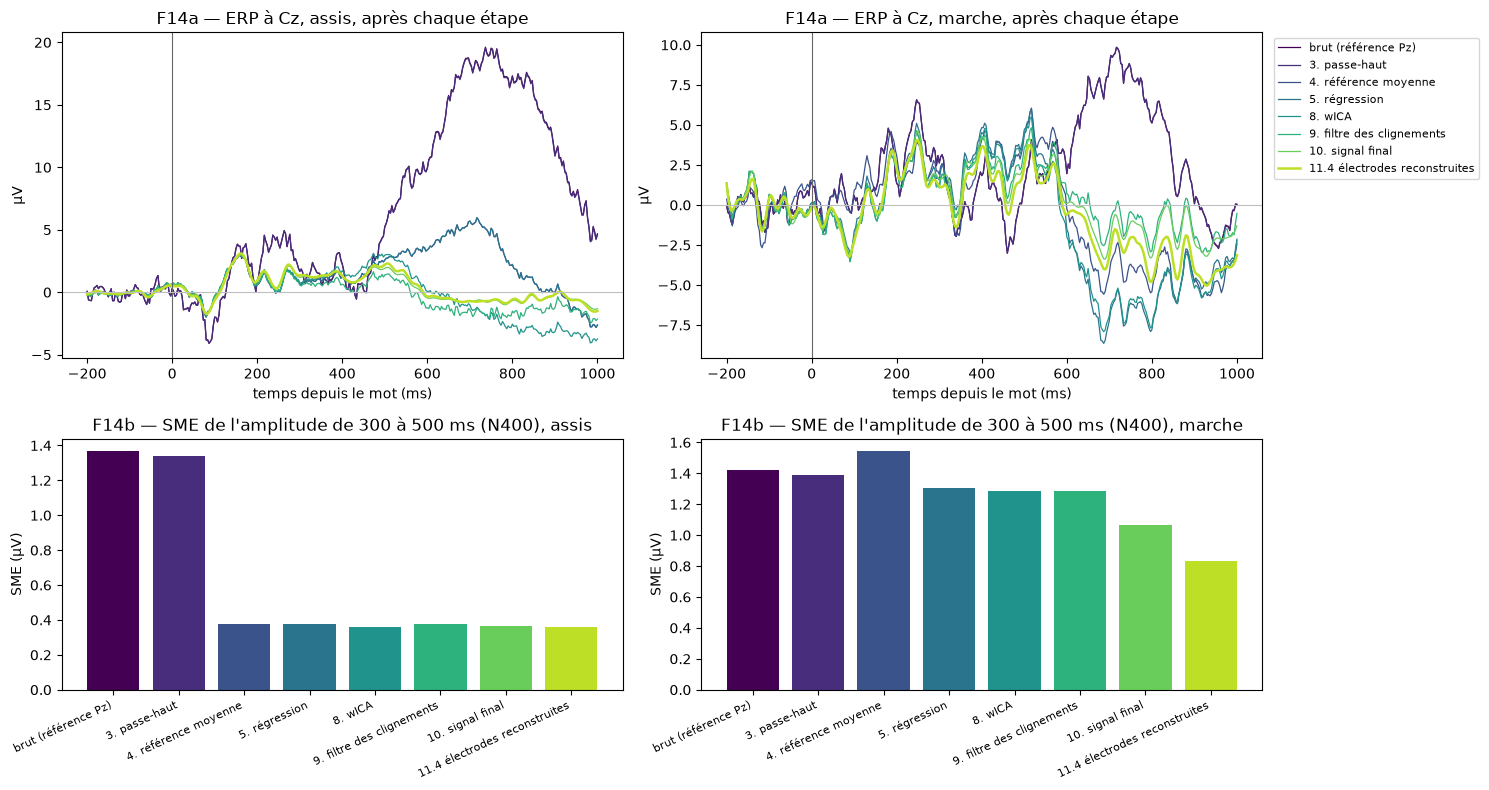

In [84]:
# ---- F14 : l'ERP et sa SME après chaque étape ------------------------------------------------------------------------------------
FENETRE_SME = 'N400'         # modifiable : 'P2', 'N400' ou 'LPC (mot)', la fenêtre de F14b
if FENETRE_SME not in FENETRES_ERP:
    raise ValueError(f'FENETRE_SME = {FENETRE_SME!r} : choisissez parmi {list(FENETRES_ERP)}')
couleurs_etapes = plt.cm.viridis(np.linspace(0, 0.9, len(etapes)))           # du violet (brut) au jaune (11.4)
fig, axes = plt.subplots(2, 2, figsize=(15, 8), gridspec_kw=dict(height_ratios=[1.3, 1]))
for col, posture in enumerate(('seated', 'walking')):
    ax = axes[0, col]
    for (etiquette, _, _), couleur in zip(etapes, couleurs_etapes):
        if (etiquette, posture) in erp_etapes:
            ax.plot(temps_ms, erp_etapes[(etiquette, posture)], color=couleur, lw=1.8 if etiquette.startswith('11') else 0.9, label=etiquette)
    ax.axvline(0, color='0.4', lw=0.8)                                       # l'apparition du mot
    ax.axhline(0, color='0.75', lw=0.8)
    ax.set_title(f'F14a — ERP à {nom_choix(electrodes_14)}, {NOM_POSTURE[posture]}, après chaque étape')
    ax.set_xlabel('temps depuis le mot (ms)')
    ax.set_ylabel('µV')
    ax = axes[1, col]
    s = sme_etapes[(sme_etapes['posture'] == NOM_POSTURE[posture]) & (sme_etapes['composante'] == FENETRE_SME)]
    w0, w1 = FENETRES_ERP[FENETRE_SME]
    ax.set_title(f'F14b — SME de l\'amplitude de {w0 * 1000:.0f} à {w1 * 1000:.0f} ms ({FENETRE_SME}), {NOM_POSTURE[posture]}')
    if s.empty:
        for a in (axes[0, col], ax):
            a.text(0.5, 0.5, 'aucune époque utilisable', transform=a.transAxes, ha='center')
            a.set_xticks([])
            a.set_yticks([])
        continue
    ax.bar(range(len(s)), s['SME'], color=couleurs_etapes[:len(s)])
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(s['etape'], rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('SME (µV)')
poignees, etiquettes = max((axes[0, 0].get_legend_handles_labels(), axes[0, 1].get_legend_handles_labels()), key=lambda h: len(h[0]))
axes[0, 1].legend(poignees, etiquettes, fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1.0))   # la légende, à droite
plt.tight_layout()
plt.show()

**Que regarder ? (F14)** Chez P003 :
- **assis**, avec la référence Pz (brut et étape 3), une grande onde positive apparaît après 500 ms. Ce sont surtout les clignements qui
  suivent la réponse (F6b) : avec la référence Pz, ils touchent Cz. La référence moyenne (4) la réduit, la correction des yeux (8 et 9)
  l'enlève. La SME tombe de 1,3 à 0,4 µV à l'étape 4 : avec la référence Pz, le bruit de Pz entrait dans Cz. Ensuite, elle bouge peu ;
- **en marche**, la SME **monte** à l'étape 4 : la référence moyenne répartit sur Cz le bruit des électrodes qui bougent avec les pas (P3,
  F5d). Elle baisse avec la régression (5), puis chaque fois que la référence moyenne est refaite : à l'étape 10, puis à l'étape 11.4, sans
  les électrodes trop souvent au-dessus de 100 µV (dont P3).

Une étape peut donc aider dans une posture et nuire dans l'autre, et une étape qui ne vise pas Cz peut changer Cz, par la référence
moyenne. Regardez votre participant : les étapes qui comptent ne sont pas forcément les mêmes.

F14 est un diagnostic, pas une preuve : une étape peut baisser la SME et changer aussi l'amplitude ou la forme de l'ERP ; comparez donc les
courbes et la SME ensemble. L'étape 10 regroupe trois opérations (les électrodes laissées de côté reconstruites, une nouvelle référence
moyenne, le filtre passe-bas) : un changement à l'étape 10 ne peut pas être attribué à l'une d'elles sans les séparer.

**Bloc Type 2.** Mettez `FENETRE_SME = 'LPC (mot)'` dans la cellule F14 : quelle étape compte le plus pour la fin de l'époque ? Mettez
ensuite `ELECTRODE_14 = ['C3', 'Cz', 'C4']` dans la cellule 14.1 : le bénéfice d'une étape dépend-il de l'électrode ?

## 15. Une autre ligne de base : la régression (Blocs Type 1 et 2)

**Pourquoi cette section ?** À l'étape 11, chaque époque perd sa moyenne de -200 à 0 ms. C'est une soustraction : tout ce que contient la
période avant le mot, bruit compris, est retiré de toute l'époque, avec un poids de 1. Alday (2019) propose de laisser les données choisir
ce poids. À chaque instant de l'époque, une régression prédit le signal à partir de la condition de l'essai et de sa ligne de base. Le
coefficient de la ligne de base, γ (gamma), dit quelle part de la ligne de base se retrouve à cet instant. La correction retire γ fois la
ligne de base : γ = 1 revient à la soustraction, γ = 0 à ne rien corriger.

Le projet Brain Walk fait cette analyse comme vérification, avec un terme pour chacune des six conditions (posture × type de mot) et un γ
par posture. On la refait ici à une électrode, à partir des époques **sans** ligne de base : on les redécoupe dans le signal final, avec les
essais de vos époques. Les essais où l'électrode a été reconstruite à l'étape 11.6 sont laissés de côté, parce que cette reconstruction a
été faite sur l'époque déjà corrigée.

In [85]:
# ---- 15.1 Les époques sans ligne de base, à une électrode ------------------------------------------------------------------------
ELECTRODE_LB = 'Cz'          # modifiable : l'électrode étudiée
FENETRE_LB = (-0.2, 0.0)     # modifiable (v1.0 : -0,2 à 0 s) : la fenêtre de la ligne de base, entre -0,5 et 0 s
j = CANAUX.index(ELECTRODE_LB)
if systematiques[j] or a_reconstruire[j]:
    raise ValueError(f'{ELECTRODE_LB} est reconstruite dans toutes les époques chez {PARTICIPANT} : choisissez une autre électrode')
l0, l1 = int(round(FENETRE_LB[0] * FS)), int(round(FENETRE_LB[1] * FS))      # en échantillons
temps_lb = np.arange(r0, r1 + 1) / FS * 1000                                 # de -200 à 1000 ms
essais_lb = tableau[utiles].assign(k=tableau.groupby('enregistrement').cumcount()[utiles])   # k : la place de l'essai dans son bloc
reconstruite = np.array([pics[nom][k, j] > SEUIL_REJET_UV for nom, k in zip(essais_lb['enregistrement'], essais_lb['k'])])   # reconstruite en 11.6
essais_lb = essais_lb[~reconstruite].reset_index(drop=True)
Y = np.array([final[nom][j, s + r0:s + r1 + 1] for nom, s in zip(essais_lb['enregistrement'], essais_lb['sample'])])   # sans correction (µV)
ligne_base = np.array([final[nom][j, s + l0:s + l1].mean() for nom, s in zip(essais_lb['enregistrement'], essais_lb['sample'])])   # la ligne de base de chaque essai
posture_lb, type_lb = essais_lb['posture'].to_numpy(), essais_lb['type'].to_numpy()
print(f'{len(Y)} essais ; {reconstruite.sum()} laissés de côté ({ELECTRODE_LB} reconstruite dans l\'époque)')

661 essais ; 14 laissés de côté (Cz reconstruite dans l'époque)


In [86]:
# ---- 15.2 La régression : les six conditions et la ligne de base, avec un poids par posture --------------------------------------
conditions = [(p, t) for p in ('seated', 'walking') for t in ('HF', 'LF', 'pseudo')]
X_cond = np.column_stack([(posture_lb == p) & (type_lb == t) for p, t in conditions]).astype(float)   # une colonne par condition (1 si l'essai en est)
X_cond = X_cond[:, X_cond.sum(axis=0) > 0]                                   # sans les conditions vides
postures_lb = [p for p in ('seated', 'walking') if (posture_lb == p).any()]
X = np.column_stack([X_cond] + [ligne_base * (posture_lb == p) for p in postures_lb])   # puis la ligne de base, une colonne par posture
coefficients = np.linalg.lstsq(X, Y, rcond=None)[0]                          # une régression par instant (une colonne de Y par instant)
gamma = {p: coefficients[X_cond.shape[1] + i] for i, p in enumerate(postures_lb)}   # le poids de la ligne de base, à chaque instant
Y_regression = Y - sum(np.outer(ligne_base * (posture_lb == p), gamma[p]) for p in postures_lb)   # chaque époque moins gamma fois sa ligne de base
traitements = {'sans correction': Y, 'soustraction (v1.0)': Y - ligne_base[:, None], 'régression (Alday, 2019)': Y_regression}
for p in postures_lb:
    print(f'{NOM_POSTURE[p]} : gamma moyen ' + ', '.join(f'{c} {gamma[p][(temps_lb >= w0 * 1000) & (temps_lb <= w1 * 1000)].mean():.2f}'
                                                       for c, (w0, w1) in FENETRES_ERP.items()))

assis : gamma moyen P2 0.54, N400 0.32, LPC (mot) 0.17
marche : gamma moyen P2 0.70, N400 0.66, LPC (mot) 0.50


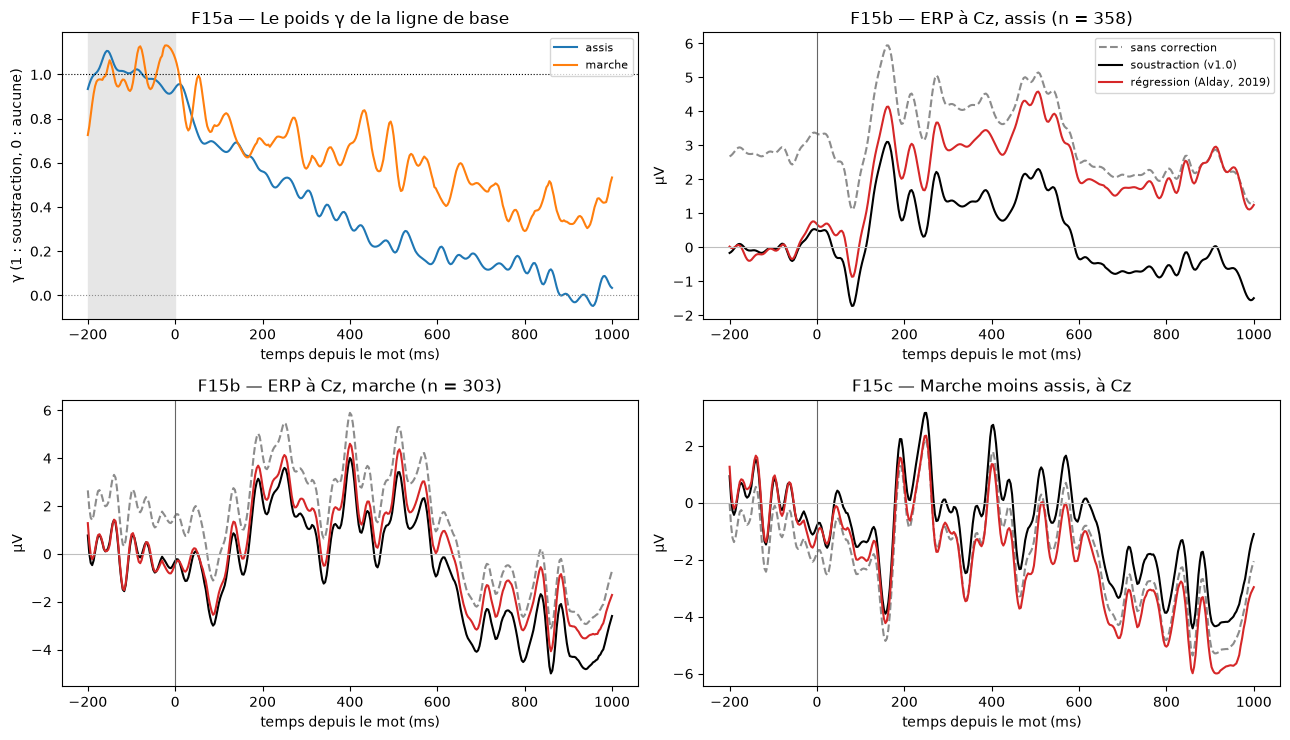

In [87]:
# ---- F15 : le poids de la ligne de base, et l'ERP avec chaque ligne de base ------------------------------------------------------
style = {'sans correction': dict(color='0.55', ls='--'), 'soustraction (v1.0)': dict(color='k'), 'régression (Alday, 2019)': dict(color='C3')}
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
ax = axes[0, 0]
for p in postures_lb:
    ax.plot(temps_lb, gamma[p], color='C0' if p == 'seated' else 'C1', label=NOM_POSTURE[p])
ax.axhline(1, color='k', lw=0.8, ls=':')                                     # la soustraction
ax.axhline(0, color='0.55', lw=0.8, ls=':')                                  # aucune correction
ax.axvspan(max(FENETRE_LB[0], temps_lb[0] / 1000) * 1000, FENETRE_LB[1] * 1000, color='0.9', zorder=0)   # la ligne de base
ax.set_title('F15a — Le poids γ de la ligne de base')
ax.set_xlabel('temps depuis le mot (ms)')
ax.set_ylabel('γ (1 : soustraction, 0 : aucune)')
ax.legend(fontsize=8)
for ax, p in zip([axes[0, 1], axes[1, 0]], ('seated', 'walking')):
    m = posture_lb == p
    ax.set_title(f'F15b — ERP à {ELECTRODE_LB}, {NOM_POSTURE[p]} (n = {m.sum()})')
    if not m.any():
        ax.text(0.5, 0.5, 'aucune époque utilisable', transform=ax.transAxes, ha='center')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    for nom_t, Z in traitements.items():
        ax.plot(temps_lb, Z[m].mean(axis=0), label=nom_t, **style[nom_t])
    ax.axvline(0, color='0.4', lw=0.8)                                       # l'apparition du mot
    ax.axhline(0, color='0.75', lw=0.8)
    ax.set_xlabel('temps depuis le mot (ms)')
    ax.set_ylabel('µV')
axes[0, 1].legend(fontsize=8)
ax = axes[1, 1]
ax.set_title(f'F15c — Marche moins assis, à {ELECTRODE_LB}')
if len(postures_lb) == 2:
    for nom_t, Z in traitements.items():
        ax.plot(temps_lb, Z[posture_lb == 'walking'].mean(axis=0) - Z[posture_lb == 'seated'].mean(axis=0), label=nom_t, **style[nom_t])
    ax.axvline(0, color='0.4', lw=0.8)
    ax.axhline(0, color='0.75', lw=0.8)
    ax.set_xlabel('temps depuis le mot (ms)')
    ax.set_ylabel('µV')
else:
    ax.text(0.5, 0.5, 'une seule posture : pas de différence', transform=ax.transAxes, ha='center')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

In [88]:
# ---- 15.3 L'effet de la posture et la SME, selon la ligne de base ----------------------------------------------------------------
lignes_14 = []
for nom_t, Z in traitements.items():
    for composante, (w0, w1) in FENETRES_ERP.items():
        dans = (temps_lb >= w0 * 1000) & (temps_lb <= w1 * 1000)
        amplitude = {p: Z[posture_lb == p][:, dans].mean(axis=1) for p in postures_lb}   # l'amplitude moyenne de chaque essai
        ligne = {'ligne de base': nom_t, 'fenêtre': composante}
        if len(postures_lb) == 2:
            ligne['marche - assis (µV)'] = amplitude['walking'].mean() - amplitude['seated'].mean()
        for p in postures_lb:
            ligne[f'SME {NOM_POSTURE[p]} (µV)'] = amplitude[p].std(ddof=1) / np.sqrt(len(amplitude[p]))
        lignes_14.append(ligne)
pd.DataFrame(lignes_14).set_index(['ligne de base', 'fenêtre']).round(2)

marche - assis (µV)  SME assis (µV)  \
ligne de base            fenêtre                                          
sans correction          P2                        0.58            0.32   
                         N400                     -1.27            0.30   
                         LPC (mot)                -2.15            0.31   
soustraction (v1.0)      P2                        1.53            0.31   
                         N400                     -0.31            0.36   
                         LPC (mot)                -1.19            0.41   
régression (Alday, 2019) P2                        0.79            0.27   
                         N400                     -1.60            0.28   
                         LPC (mot)                -2.60            0.31   

                                    SME marche (µV)  
ligne de base            fenêtre                     
sans correction          P2                    1.10  
                         N400                  0.98  
                         LPC (mot)             0.84  
soustraction (v1.0)      P2                    0.94  
                         N400                  0.82  
                         LPC (mot)             0.84  
régression (Alday, 2019) P2                    0.90  
                         N400                  0.76  
                         LPC (mot)             0.70

**Que regarder ? (F15)**
- **F15a.** Pendant la ligne de base (en gris), γ vaut environ 1 : le signal y est sa propre ligne de base. Après le mot, γ baisse : une
  partie seulement de la ligne de base se retrouve dans la suite de l'époque. Chez P003, dans la fenêtre de la N400 (300 à 500 ms), γ vaut en
  moyenne 0,3 assis et 0,7 en marche (sortie de 15.2).
- **F15b.** La régression place l'ERP entre la soustraction (γ = 1) et l'absence de correction (γ = 0). Dans le tableau de 15.3, sa SME est
  la plus petite, ou presque : elle ne retire de chaque instant que la part de la ligne de base qui s'y retrouve, donc moins de son bruit.
- **F15c.** La différence entre les postures dépend de la ligne de base. Chez P003, dans la fenêtre de la N400, elle vaut -0,3 µV avec la
  soustraction et -1,6 µV avec la régression.

**Laquelle croire ?** γ est appris sur les différences d'un essai à l'autre, à l'intérieur d'une posture, qui sont surtout du bruit rapide.
Il ne dit pas quelle part d'une différence lente entre les postures, déjà là avant le mot et qui dure toute l'époque, se retrouve après le
mot. La soustraction enlève entièrement une telle différence ; la régression n'en enlève qu'une partie. C'est pourquoi le projet Brain Walk
garde la soustraction comme analyse principale et la régression comme vérification. Un effet qui change de taille ou de signe selon la ligne
de base se rapporte avec cette réserve.

**Bloc Type 2.** Mettez `FENETRE_LB = (-0.1, 0.0)`, puis `(-0.5, 0.0)`, et relancez la section 15. La différence entre les postures
change-t-elle ? Essayez aussi `ELECTRODE_LB = 'Pz'`.

### Les analyses de sensibilité du projet (pas faites ici)

Ces variantes changeraient les fichiers fournis : elles ne font donc pas partie de cette reproduction. Ce sont les vérifications à faire au
niveau du projet avant de conclure sur un effet de groupe :

| Vérification | Pourquoi |
|---|---|
| `SEUIL_RATIO` à 1,1, 1,5 et 2,0 | 1,1 a été choisi pour des enregistrements assis avec un oculomètre (Plöchl et al., 2012) ; ici, les moments des yeux viennent de l'EEG (étape 7) |
| le rang des données avant l'ICA | l'interpolation, et une nouvelle référence sans la référence d'origine, le baissent (Kim et al., 2023 ; F7b) |
| la référence actuelle, la moyenne des seules électrodes mesurées, les lobes d'oreille A1/A2 | la référence change la SME et les cartes (étape 4) |
| une nouvelle référence moyenne après la réparation de 11.6 | reconstruire des électrodes dans une époque change la moyenne de ses électrodes |
| la réparation (`MAX_REPARATIONS = 3`) contre aucune réparation (`0`) | le prix en essais du refus de réparer (F11a) |
| la régression sur l'accéléromètre, aucune régression, l'ASR | un signal à l'allure plus propre n'est pas forcément moins biaisé (étape 5) |
| les électrodes que l'accéléromètre explique dans chaque bloc en marche | une électrode qui bouge à chaque pas pourrait être laissée de côté avant la référence et l'ICA (F5d) |
| la phase du pas à chaque mot | les mots ne doivent pas être calés sur le pas (F5f) |
| la LPC avec et sans les essais sans clignement, et les époques de la tape qui touchent un moment BAD | l'effet tardif ne doit pas venir des yeux ni d'une mauvaise époque (13.1b) |

Ne choisissez pas parmi ces variantes celle qui donne le plus grand effet. Comparez ce que chacune garde (les essais, la SME, les cartes) et
la stabilité des effets définis d'avance.

## 16. Les repos et la marche sans tâche : à quoi ils servent

La séance contient aussi deux repos assis (yeux ouverts) et une marche sans tâche. Ce sont des **conditions contrôles**. Elles ne remplacent
pas la ligne de base de chaque essai (-200 à 0 ms avant le mot), qui corrige la tension d'une époque : elles répondent à d'autres questions,
sur la puissance de l'EEG pendant des minutes plutôt que sur sa réponse à un mot.

| Question | Contraste | Réserve |
|---|---|---|
| L'ERP d'un mot (P2, N400, LPC) | chaque essai contre sa propre ligne de base (étape 11) | un repos plusieurs minutes plus tôt ne dit rien de la tension juste avant le mot ; les études d'ERP en EEG mobile gardent la ligne de base locale (Ladouce et al., 2019 ; De Sanctis et al., 2026) |
| La marche change-t-elle l'effet de la fréquence ? | (LF - HF) en marche - (LF - HF) assis (13.4, notebook 09) | chaque effet se calcule dans une posture : aucun repos n'est nécessaire |
| La puissance qui vient avec la marche | marche sans tâche - repos assis (en dB) | les deux diffèrent par le mouvement, la vision et la posture, pas seulement par la marche (Pizzamiglio et al., 2017) |
| La puissance qu'ajoute la tâche | tâche - le contrôle de la même posture (la marche sans tâche, ou le repos) | la tâche ajoute à la fois lire, décider et répondre |
| La tâche change-t-elle la puissance qui vient avec la marche ? | (tâche en marche - marche sans tâche) - (tâche assis - repos) | la marche sans tâche vient toujours avant les blocs en marche |
| La puissance au fil du pas | le cycle du pas, avec une ligne de base commune à la marche avec et sans la tâche (De Sanctis et al., 2026) | une puissance qui suit les contacts du talon peut être un artefact de mouvement (Kline et al., 2015) |
| L'état du cerveau dérive-t-il pendant la séance ? | repos de la fin - repos du début | à vérifier avant de moyenner les deux repos |

Le notebook 10 (section 5) fait ces contrastes chez tous les participants, avec les enregistrements continus du dossier `pretraite/continus/`.
Les ERP des mots restent en millisecondes depuis le mot : on ne les étire pas sur le cycle du pas. Pour savoir si la réponse à un mot dépend
de l'endroit où il tombe dans le pas, gardez la phase du pas comme une propriété de chaque essai (F5f).

### Enregistrer les paramètres de votre passage (Bloc Type 1)

La cellule suivante enregistre, à côté de vos époques (`mes_resultats/`), les paramètres de ce passage et les versions des paquets. Un
résultat se rapporte avec eux : ils disent exactement quel pipeline l'a produit.

In [89]:
# ---- Les paramètres de votre passage, enregistrés à côté de vos époques ----------------------------------------------------------
PARAMETRES = ['BORD_S', 'MARGE_COUPURE_S', 'SEGMENT_MIN_S', 'SEUIL_MORTE_UV', 'PART_RAIL', 'BANDE_BRUIT', 'BANDE_AMPLITUDE', 'FENETRE_S',
              'SEUIL_Z', 'RATIO_AMPLITUDE', 'PART_FENETRES', 'RAIL_MARGE_S', 'MIN_BONNES', 'MAX_PART_BAD', 'PART_SYSTEMATIQUE',
              'HP_HZ', 'ORDRE_HP', 'FENETRE_BOUFFEE_S', 'SEUIL_BOUFFEE', 'BANDE_ACC', 'RETARDS_S', 'FENETRE_REG_S', 'BLOC_VAL_S', 'UN_SUR', 'ALPHAS',
              'GAIN_MIN', 'PASSE_BAS_CORR_HZ', 'BANDE_CLIGNEMENT', 'SEUIL_CLIGNEMENT_MAD', 'MIN_CLIGNEMENT_UV', 'DUREE_CLIGNEMENT_S', 'ECART_MIN_CLIG_S',
              'SEUIL_SACCADE_MAD', 'DUREE_MIN_SACCADE_MS', 'ECART_CLIGNEMENT_S', 'PASSE_BAS_SAC_HZ', 'HP_ICA_HZ', 'SUREPRESENTATION', 'MAX_ECHANTILLONS',
              'SEUIL_RATIO', 'ONDELETTE', 'NIVEAUX', 'FENETRE_FILTRE_S', 'RAMPE_S', 'PASSE_BAS_HZ', 'MIN_TR_S', 'SEUIL_ABERRANT', 'TMIN', 'TMAX',
              'LIGNE_BASE', 'FENETRE_REJET', 'SEUIL_REJET_UV', 'PART_EPOQUES', 'MIN_ELECTRODES', 'MAX_REPARATIONS', 'MIN_MESUREES',
              'FENETRE_LPC', 'MARGE_CLIG_S', 'EXIGER_MINIMUM', 'FENETRE_LB']   # les paramètres modifiables des cellules
passage = {'participant': PARTICIPANT, 'versions': VERSIONS} | {p: globals()[p] for p in PARAMETRES}
fichier_passage = DOSSIER / 'mes_resultats' / f'sub-{PARTICIPANT}_parametres.json'
fichier_passage.write_text(json.dumps(passage, indent=1, default=str), encoding='utf-8')
print('Paramètres enregistrés dans', fichier_passage)

Paramètres enregistrés dans tasks\brainwalk\mes_resultats\sub-P003_parametres.json


## Synthèse

Vous avez refait les 12 étapes du pipeline sur un participant. Pour retrouver ce que le pipeline a fait chez lui, et la question à se poser :

| Étape | Où le lire | Question à se poser |
|---|---|---|
| 2. Contrôle des électrodes | la liste « Laissées de côté partout » et le tableau de 2.6, puis les électrodes réparées en 4.2 | quelles électrodes peut-on encore considérer comme vraiment mesurées ? |
| 5. Accéléromètre | le tableau de 5.5 (un `alpha` à `NaN` : rien n'a été corrigé), F5c et F5d | enlève-t-on du mouvement sans effacer un signal vraiment lié à la marche ? |
| 7-9. Les yeux | les composantes oculaires de chaque posture en 7.2, puis F8 et F9 | le critère « composante oculaire » est-il assez spécifique ? |
| 11. Époques | le tableau de 11.6, F11a, le bilan 11.8 et le nombre d'époques par condition en 11.7 | assis et en marche gardent-ils une qualité et un nombre d'essais comparables ? |
| 11.9-11.10 Les électrodes reconstruites | le tableau de 11.9, le tableau de 11.10 et F11d | combien d'électrodes de chaque région sont vraiment mesurées ? |
| ERP | F11b et F11c | les différences après le mot existaient-elles déjà avant le mot ? |
| 13. Les composantes | F13a, F13b, les tableaux de 13.1b, 13.3 et 13.4 | un effet tient-il sans les essais où l'on cligne près de la tape ? l'effet de la fréquence change-t-il avec la posture ? |
| 14. L'effet de chaque étape | F14a, F14b et le tableau de 14.1 | quelles étapes rendent l'ERP plus précis, dans chaque posture ? |
| 15. La ligne de base | F15 et le tableau de 15.3 | l'effet tient-il avec une autre ligne de base ? |
| 16. Les repos et la marche sans tâche | le tableau de la section 16 | un contraste est-il une ligne de base d'ERP, une condition contrôle ou une référence pour la puissance ? |

### À retenir
1. Chaque étape est un compromis : elle enlève du bruit et risque d'enlever du signal.
2. Quand on enlève un artefact, on vérifie aussi que le signal qui nous intéresse est toujours là.
3. Un seuil automatique est une règle de décision. Il ne dit pas d'où vient le signal.
4. Pour comparer assis et en marche, regardez aussi l'activité avant le mot, le nombre d'essais gardés et la quantité d'interpolation.
5. Un prétraitement se rapporte : paramètres, versions des logiciels, électrodes reconstruites, essais rejetés.
6. Une composante se mesure dans une région et une fenêtre. Un effet proche de la réponse se vérifie sans les essais où l'on cligne
   des yeux (section 13).
7. La précision d'un ERP se mesure (SME) : une étape qui aide dans une posture peut nuire dans l'autre (F14b).
8. La ligne de base est un choix d'analyse : un effet qui dépend de ce choix se rapporte avec cette réserve (section 15).
9. Une électrode reconstruite garde la carte complète, mais ce n'est pas une mesure : les régions n'utilisent que les électrodes mesurées
   dans chaque époque (11.9, 11.10, section 13).
10. Les repos et la marche sans tâche sont des conditions contrôles : ils ne remplacent pas la ligne de base de chaque essai (section 16).
11. `AFFICHAGE` et `FIGURES` (0.4) ne changent que les figures. Les électrodes des détecteurs (Fp1, Fp2, les paires des saccades) et les
    régions des composantes définissent la méthode : les changer est une autre analyse, à rapporter comme telle.

### Questions de vérification
1. Pourquoi le pipeline traite-t-il les 11 enregistrements ensemble plutôt qu'un à la fois ?
2. Pourquoi corriger les composantes oculaires par ondelettes au lieu de les enlever ?
3. Quelle étape agit surtout sur les blocs en marche ? Comment le voyez-vous dans F5 ? Quelle est sa limite principale ?
4. Une électrode dépasse 100 µV dans 60 % des époques en marche. Que fait le pipeline ?
5. Pourquoi une différence assis-marche déjà présente avant le mot complique-t-elle l'interprétation d'une N400 ou d'une LPC ?
6. Chez votre participant, l'effet de la posture sur la LPC est-il le même avec tous les essais et sans les essais à clignement (tableau
   de 13.3) ? Pourquoi un clignement change-t-il la valeur d'une région à l'arrière de la tête ?
7. Dans F14b, à quelle étape la SME en marche baisse-t-elle le plus chez votre participant ? Qu'est-ce que cette étape a changé ?
8. Pourquoi la régression de la section 15 ne règle-t-elle pas la question d'une différence assis-marche déjà présente avant le mot ?
9. Pourquoi la reconstruction d'une électrode suit-elle l'ERP moyen, mais pas le signal continu (F11d) ? Qu'en déduire pour une mesure
   faite essai par essai ?
10. Quels réglages de ce notebook ne changent qu'une figure, et lesquels changent l'analyse ?

<details><summary>Indices</summary>

1. Deux décisions dépendent de plusieurs enregistrements : les électrodes laissées de côté partout (étape 2) et l'ICA, qui apprend sur tous
   les enregistrements d'une posture (étape 7).
2. Une composante oculaire contient aussi un peu d'activité du cerveau ; les ondelettes n'enlèvent que les grands transitoires.
3. L'étape 5 : les pics aux fréquences des pas baissent dans le spectre. Sa limite : une activité du cerveau vraiment liée à la marche peut
   aussi suivre le mouvement, et la régression l'enlèverait avec l'artefact.
4. Elle est reconstruite dans toutes les époques, assis et en marche (étape 11.3).
5. Une différence déjà présente avant le mot se retrouve, avec le signe inverse, après la soustraction de la ligne de base : on risque de la
   prendre pour un effet du mot.
6. Avec la référence moyenne, un clignement très positif au-dessus des yeux rend les autres électrodes un peu négatives
   (F13b). Si l'on cligne plus souvent près de la tape dans une posture (sortie de 13.1), la LPC de cette posture baisse, et l'on prend
   cette baisse pour un effet de la posture.
7. Chez P003, la SME en marche baisse avec la régression (5) et chaque fois que la référence moyenne est refaite sans les électrodes qui
   bougent avec les pas (10 et 11.4).
8. Son poids γ est appris sur les variations d'un essai à l'autre à l'intérieur d'une posture, pas sur la différence entre les postures.
9. L'interpolation combine les voisines : elle reproduit ce qu'elles partagent, la partie lisse et étendue que la moyenne des essais
   garde, pas ce que l'électrode enregistre seule. Une mesure faite essai par essai (la valeur d'une région, une SME, un classifieur du
   notebook 11) prendrait ce mélange des voisines pour une vraie électrode.
10. `AFFICHAGE` et `FIGURES` ne changent que les figures. Les paramètres marqués `# modifiable` dans les cellules, les électrodes des
    détecteurs (étape 6) et les régions des composantes (section 13) changent l'analyse.
</details>

**Prochaine étape.** Le notebook `09_analysis1_lexicaldecision.ipynb` part des fichiers du dossier `pretraite/` (tous les participants) pour
tester vos hypothèses.

## Pour aller plus loin

- Alday, P. M. (2019). How much baseline correction do we need in ERP research? Extended GLM model can replace baseline correction while lifting its limits. *Psychophysiology, 56*, e13451. https://doi.org/10.1111/psyp.13451 (la ligne de base par régression, section 15)
- Barnes, L., Davidson, M. J., & Alais, D. (2025). The speed and phase of locomotion dictate saccade probability and simultaneous low-frequency power spectra. *Attention, Perception, & Psychophysics, 87*, 245-260. https://doi.org/10.3758/s13414-024-02932-4 (le même casque en marche : référence aux lobes d'oreille, mauvaises électrodes retirées ; sections 0 et 4)
- Brosnan, M., Pearce, D. J., O'Neill, M. H., Loughnane, G. M., Fleming, B., Zhou, S.-H., Chong, T., Nobre, A. C., O'Connell, R. G., & Bellgrove, M. A. (2023). Evidence accumulation rate moderates the relationship between enriched environment exposure and age-related response speed declines. *Journal of Neuroscience, 43*, 6401-6414. https://doi.org/10.1523/JNEUROSCI.2260-21.2023 (les essais avec un clignement près de la réponse laissés de côté, section 13)
- Castellanos, N. P., & Makarov, V. A. (2006). Recovering EEG brain signals: Artifact suppression with wavelet enhanced independent component analysis. *Journal of Neuroscience Methods, 158*, 300-312. https://doi.org/10.1016/j.jneumeth.2006.05.033 (la wICA, étape 8)
- de Cheveigné, A., & Parra, L. C. (2014). Joint decorrelation, a versatile tool for multichannel data analysis. *NeuroImage, 98*, 487-505. https://doi.org/10.1016/j.neuroimage.2014.05.068 (le filtre des clignements, étape 9)
- De Sanctis, P., Barbusse, D., Vanneau, T., et al. (2026). Neural signatures of dual-task walking demands in individuals at risk of cognitive impairment. *npj Aging, 12*, 103. https://doi.org/10.1038/s41514-026-00402-9 (la ligne de base des ERP, et une ligne de base commune à la marche avec et sans la tâche ; sections 11 et 16)
- Dimigen, O. (2020). Optimizing the ICA-based removal of ocular EEG artifacts from free viewing experiments. *NeuroImage, 207*, 116117. https://doi.org/10.1016/j.neuroimage.2019.116117 (OPTICAT, étape 7)
- Gwin, J. T., Gramann, K., Makeig, S., & Ferris, D. P. (2010). Removal of movement artifact from high-density EEG recorded during walking and running. *Journal of Neurophysiology, 103*, 3526-3534. https://doi.org/10.1152/jn.00105.2010 (des moyennes calées sur les pas, F5e)
- Kim, H., Luo, J., Chu, S., Cannard, C., Hoffmann, S., & Miyakoshi, M. (2023). ICA's bug: How ghost ICs emerge from effective rank deficiency caused by EEG electrode interpolation and incorrect re-referencing. *Frontiers in Signal Processing, 3*, 1064138. https://doi.org/10.3389/frsip.2023.1064138 (le rang des données avant l'ICA, F7b)
- Kline, J. E., Huang, H. J., Snyder, K. L., & Ferris, D. P. (2015). Isolating gait-related movement artifacts in electroencephalography during human walking. *Journal of Neural Engineering, 12*, 046022. https://doi.org/10.1088/1741-2560/12/4/046022 (l'artefact de la marche et l'accélération de la tête, étape 5)
- Kutas, M., & Federmeier, K. D. (2011). Thirty years and counting: Finding meaning in the N400 component of the event-related brain potential (ERP). *Annual Review of Psychology, 62*, 621-647. https://doi.org/10.1146/annurev.psych.093008.131123 (la N400, section 13)
- Ladouce, S., Donaldson, D. I., Dudchenko, P. A., & Ietswaart, M. (2019). Mobile EEG identifies the re-allocation of attention during real-world activity. *Scientific Reports, 9*, 15851. https://doi.org/10.1038/s41598-019-51996-y (la ligne de base des ERP en EEG mobile, section 11)
- Luck, S. J., Stewart, A. X., Simmons, A. M., & Rhemtulla, M. (2021). Standardized measurement error: A universal metric of data quality for averaged event-related potentials. *Psychophysiology, 58*, e13793. https://doi.org/10.1111/psyp.13793 (la SME, section 14)
- O'Connell, R. G., Dockree, P. M., & Kelly, S. P. (2012). A supramodal accumulation-to-bound signal that determines perceptual decisions in humans. *Nature Neuroscience, 15*, 1729-1735. https://doi.org/10.1038/nn.3248 (une onde de la décision, centrée sur la réponse, section 13)
- Paillard, J., Bomatter, P., Dubreuil-Vall, L., Hipp, J. F., & Hawellek, D. J. (2025). Benchmarking the utility of dry-electrode electroencephalography for clinical trials. *Scientific Reports, 15*, 33667. https://doi.org/10.1038/s41598-025-18184-7 (l'interpolation des électrodes sèches, sections 0 et 4)
- Pizzamiglio, S., Naeem, U., Abdalla, H., & Turner, D. L. (2017). Neural correlates of single- and dual-task walking in the real world. *Frontiers in Human Neuroscience, 11*, 460. https://doi.org/10.3389/fnhum.2017.00460 (la marche contre le repos, section 16)
- Plöchl, M., Ossandón, J. P., & König, P. (2012). Combining EEG and eye tracking: Identification, characterization, and correction of eye movement artifacts in electroencephalographic data. *Frontiers in Human Neuroscience, 6*, 278. https://doi.org/10.3389/fnhum.2012.00278 (le seuil de 1,1, étape 7)
- Snyder, K. L., Kline, J. E., Huang, H. J., & Ferris, D. P. (2015). Independent component analysis of gait-related movement artifact recorded using EEG electrodes during treadmill walking. *Frontiers in Human Neuroscience, 9*, 639. https://doi.org/10.3389/fnhum.2015.00639 (l'ICA et l'artefact de la marche, étape 7)
- Tanner, D., Morgan-Short, K., & Luck, S. J. (2015). How inappropriate high-pass filters can produce artifactual effects and incorrect conclusions in ERP studies of language and cognition. *Psychophysiology, 52*, 997-1009. https://doi.org/10.1111/psyp.12437 (le filtre passe-haut et les ondes lentes, F3c)
- Twomey, D. M., Murphy, P. R., Kelly, S. P., & O'Connell, R. G. (2015). The classic P300 encodes a build-to-threshold decision variable. *European Journal of Neuroscience, 42*, 1636-1643. https://doi.org/10.1111/ejn.12936 (la LPC et la décision, section 13)
- Vinod, V., Papin, L. J., Romijnders, R., Maetzler, W., & Welzel, J. (2026). Preprocessing on the go: Practices in gait-related mobile EEG. *Psychophysiology, 63*, e70352. https://doi.org/10.1111/psyp.70352 (le prétraitement de l'EEG mobile pendant la marche)